# Exploratory Data Analysis

## Executive summary

This report establishes whether the fashion dataset is fit for controlled model development. The
analysis follows the normal ML EDA lifecycle: define scope, validate provenance, assess data quality,
control leakage, analyse targets and features, define evaluation, and record modelling decisions.

| Area | Main evidence | Decision for modelling |
|---|---|---|
| Data usability | 38,612 image-backed products; five metadata rows have no usable image | Exclude only objective file failures and keep an audit trail |
| Comparison integrity | 26,992 train, 5,781 validation, 5,778 sealed holdout, 61 quarantine; zero active family crossings | Use `data/processed/splits.csv` everywhere and never create another split |
| Target difficulty | `articleType` has 124 official outputs and a long tail; `usage` is 76.7% Casual in the primary training slice | Rank with macro-F1, per-class recall, and explicit rare-class coverage |
| Image representation | 96x128 matches the common 60x80 aspect ratio with no padding and 25% fewer pixels than 128x128 | Use RGB, aspect-preserving transforms, then prove the choice with a controlled model ablation |
| Resolution variants | Every train, validation, and holdout product has an original and high-resolution image | Compare original-only, high-only, and paired training; keep one product-level score |
| Visual-search evaluation | Validation queries and a train-only gallery have zero ID, hash, or family overlap | Report nDCG@5, grade-2 Recall@5, coverage, and latency |

**Report boundary.** EDA supports experiment design but does not establish model performance. No
model is trained here, the holdout remains sealed, and human duplicate review is still pending. Final
performance claims must come from registered training runs and one independent holdout evaluation.

## 1. Scope and execution

**Scope.** This notebook covers data provenance, quality, leakage control, target behaviour, image
representation, retrieval evaluation, and the resulting experiment plan. It does not train or select
a model.

**Lifecycle.** Provenance and contracts → data quality and leakage controls → target distributions →
target relationships and risk → image features and preprocessing → evaluation design → modelling
recommendations and reproducibility.

**Execution.** Start a fresh kernel and choose **Run All** once. The notebook validates the local raw
files, reuses the delivered protected-safe cache, recreates every EDA figure and evidence table, and
writes the code-free report to `results/notebooks/00_eda.html`.

**Reading pattern.** Each analysis block introduces its purpose, presents focused evidence, explains
the finding, and states the modelling consequence. Code remains in the notebook for auditability but
is collapsed by default.

**Code step — Runtime configuration.**

Imports the required packages and fixes project paths, seeds, image sizes, cache mode, and required raw files. It prepares shared settings but does not analyse labels.

In [1]:
from __future__ import annotations

import base64
import hashlib
import html
import io
import json
import os
import platform
import subprocess
import sys
import time
from pathlib import Path
from statistics import median
from typing import Any

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from PIL import Image, ImageOps

from fashion.config import ROOT as CONFIGURED_PROJECT_ROOT
from fashion.config import TARGET_COLUMNS
from fashion.data.dataset import load_label_maps, load_splits
from fashion.data.hashing import compute_sha256
from fashion.data.images import resolve_image_size, transform_image
from fashion.data.reviews import validate_review_ledger
from fashion.data.splits import validate_splits
from fashion.data.statistics import train_ids_digest
from fashion.retrieval.protocol import (
    build_development_retrieval_sets,
    build_development_retrieval_variant_sets,
)

PROJECT_ROOT = Path(CONFIGURED_PROJECT_ROOT).resolve()
PROCESSED = PROJECT_ROOT / "data/processed"
AUDIT = PROCESSED / "audit"
EVIDENCE = PROJECT_ROOT / "results/evidence/eda"
FIGURES = PROJECT_ROOT / "results/figures/eda"
REPORTS = PROJECT_ROOT / "results/notebooks"
REVIEWS = PROJECT_ROOT / "docs/reviews"
NOTEBOOK_PATH = Path(
    os.environ.get(
        "FASHION_EDA_NOTEBOOK_PATH",
        PROJECT_ROOT / "notebooks/00_eda.ipynb",
    )
).resolve()

SEED = 2753
IMAGE_SIZE = (128, 96)  # height, width: rendered as 96 x 128
LEGACY_IMAGE_SIZE = (128, 128)
WORKERS_TEXT = os.environ.get("FASHION_EDA_WORKERS", "").strip()
WORKERS = int(WORKERS_TEXT) if WORKERS_TEXT else None
BENCHMARK_SAMPLE_SIZE = int(os.environ.get("FASHION_EDA_BENCHMARK_SIZE", "512"))
BENCHMARK_REPETITIONS = int(os.environ.get("FASHION_EDA_BENCHMARK_REPETITIONS", "3"))

RAW_TRAIN_CSV = PROJECT_ROOT / "data/raw/teacher/train/styles_train.csv"
RAW_PREDICTION_CSV = PROJECT_ROOT / "data/raw/teacher/test/styles_prediction.csv"
SPLITS_PATH = PROCESSED / "splits.csv"
PREDICTION_MANIFEST_PATH = PROCESSED / "prediction_manifest.csv"
HIGH_RES_AUDIT = PROCESSED / "high_resolution"
HIGH_RES_CATALOGUE_PATH = HIGH_RES_AUDIT / "image_catalogue.csv.gz"
HIGH_RES_SUMMARY_PATH = HIGH_RES_AUDIT / "catalogue.json"
ALIGNMENT_PAIRS_PATH = HIGH_RES_AUDIT / "all_alignment_pairs.csv.gz"
ALIGNMENT_SUMMARY_PATH = HIGH_RES_AUDIT / "alignment_summary.json"
VARIANT_MANIFEST_PATH = PROCESSED / "training_image_variants.csv.gz"
VARIANT_SUMMARY_PATH = PROCESSED / "training_image_variants_summary.json"
TAXONOMY_PATH = PROCESSED / "taxonomy.json"
PAIRED_NORMALIZATION_PATH = PROCESSED / "paired_normalization.json"
ORIGINAL_ONLY_NORMALIZATION_PATH = PROCESSED / "normalization_original_only.json"
MODE_TEXT = os.environ.get("FASHION_EDA_MODE", "").strip().lower()
LEGACY_REBUILD = os.environ.get("FASHION_EDA_REBUILD")
if MODE_TEXT:
    PREPARATION_MODE = MODE_TEXT
elif LEGACY_REBUILD is not None:
    PREPARATION_MODE = "full" if LEGACY_REBUILD.strip() != "0" else "cached"
else:
    PREPARATION_MODE = "cached"
if PREPARATION_MODE not in {"cached", "full"}:
    raise ValueError("FASHION_EDA_MODE must be 'cached' or 'full'")

for folder in (EVIDENCE, FIGURES, REPORTS):
    folder.mkdir(parents=True, exist_ok=True)
for required in (RAW_TRAIN_CSV, RAW_PREDICTION_CSV):
    if not required.is_file():
        raise FileNotFoundError(f"Required teacher file is missing: {required}")

**Code step — Display defaults.**

Sets deterministic plotting defaults and notebook table styles. It changes presentation only and does not change the data.

In [2]:
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 100)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#FAFAF8",
        "axes.edgecolor": "#B8B8B8",
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#E2E2DE",
        "grid.linestyle": "--",
        "grid.alpha": 0.75,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "figure.titlesize": 14,
    }
)
PALETTE = ("#245B78", "#D97732", "#4C956C", "#8C6BB1", "#C44E52", "#6B7280")

display(
    HTML(
        """
        <style>
        .jp-OutputArea-output, .output_area {max-width: 100%; overflow-x: auto;}
        .jp-OutputArea-output table, .output_area table {
          width: 100% !important; table-layout: auto; font-size: 12px;
        }
        .jp-OutputArea-output th, .jp-OutputArea-output td,
        .output_area th, .output_area td {
          white-space: normal !important;
          overflow-wrap: break-word;
          word-break: normal;
          vertical-align: top;
        }
        figure.eda-figure {margin: 0.8rem auto 1.5rem; max-width: 100%;}
        figure.eda-figure img {display: block; width: 100%; height: auto; margin: auto;}
        figure.eda-figure figcaption {color: #374151; font-size: 0.92rem; margin-top: 0.45rem;}
        .jp-OutputArea-output th.row_heading,
        .output_area th.row_heading {
          white-space: nowrap !important;
          overflow-wrap: normal !important;
          min-width: 2rem;
        }
        @media print {
          .jp-OutputArea-output, .output_area {overflow: visible !important;}
        }
        </style>
        """
    )
)

### Implementation setup

The collapsed setup cells contain imports, configuration, display functions, and plotting functions.
They remain available for audit without interrupting the report narrative.

**Code step — Shared output helpers.**

Defines the small functions used to save tables, hash evidence, render figures, and open images safely. Later analysis cells call these functions so the saving rules stay consistent.

In [3]:
# Shared table, file, and display helpers


def bool_mask(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def save_csv(frame: pd.DataFrame, name: str) -> Path:
    path = EVIDENCE / name
    frame.to_csv(path, index=False, lineterminator="\n", float_format="%.8f")
    return path


def save_json(record: dict[str, Any], name: str) -> Path:
    path = EVIDENCE / name
    path.write_text(json.dumps(record, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    return path


def show_table(frame: pd.DataFrame, caption: str) -> None:
    styled = (
        frame.style.format(precision=3, thousands=",")
        .set_caption(caption)
        .set_table_styles(
            [
                {"selector": "caption", "props": "font-weight:600;text-align:left;"},
                {"selector": "th", "props": "background:#E8EEF2;text-align:left;"},
                {"selector": "td", "props": "text-align:left;vertical-align:top;"},
            ]
        )
    )
    styled.set_uuid("eda_" + hashlib.sha256(caption.encode()).hexdigest()[:10])
    display(styled)


def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURES / name
    fig.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
        facecolor="white",
        metadata={"Software": "Fashion Intelligence EDA"},
    )
    plt.close(fig)
    return path


def show_figure(path: Path, description: str) -> None:
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    safe = html.escape(description, quote=True)
    display(
        HTML(
            f'<figure class="eda-figure"><img src="data:image/png;base64,{encoded}" '
            f'alt="{safe}"><figcaption>{safe}</figcaption></figure>'
        )
    )


def open_rgb(relative_path: str) -> Image.Image:
    with Image.open(PROJECT_ROOT / relative_path) as source:
        return ImageOps.exif_transpose(source).convert("RGB").copy()


def show_image(axis: plt.Axes, image: Image.Image | np.ndarray, title: str) -> None:
    axis.imshow(image)
    axis.set_title(title, fontsize=9)
    axis.set_xticks([])
    axis.set_yticks([])


def file_record(path: Path) -> dict[str, Any]:
    path = path.resolve()
    try:
        shown_path = path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        shown_path = path.as_posix()
    return {
        "path": shown_path,
        "size_bytes": path.stat().st_size,
        "sha256": compute_sha256(path),
    }


def dataframe_digest(frame: pd.DataFrame, columns: list[str]) -> str:
    payload = frame[columns].fillna("").astype(str).to_csv(index=False, lineterminator="\n")
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def stable_artifact_digest(path: Path) -> str:
    if path.suffix != ".json":
        return compute_sha256(path)
    value = json.loads(path.read_text(encoding="utf-8"))

    def strip_volatile(item: Any) -> Any:
        if isinstance(item, dict):
            return {
                key: strip_volatile(child)
                for key, child in item.items()
                if key != "runtime_seconds"
            }
        if isinstance(item, list):
            return [strip_volatile(child) for child in item]
        return item

    payload = json.dumps(strip_volatile(value), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def notebook_code_digest(path: Path) -> str:
    notebook = json.loads(path.read_text(encoding="utf-8"))
    cells = [
        {"cell_type": cell["cell_type"], "source": cell.get("source", [])}
        for cell in notebook["cells"]
    ]
    payload = json.dumps(cells, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()

## 2. Data provenance and inventory

A reliable EDA begins with traceable inputs and a repeatable loading contract. This stage validates
the prepared artefacts before any label distribution or image statistic is interpreted.

### 2.1 Prepared-data contract

The fast execution path checks every image name and size, hashes a fixed image sample, and fully
hashes the lean prepared pack. Set `FASHION_EDA_MODE=full` only after raw inputs change; that mode
performs the slow forensic rebuild in a separate process.

**Code step — Prepared-data validation.**

Runs the fast cache validation by default, checks every required prepared artefact, records the runtime, and displays the result. Full rebuild mode remains an explicit maintenance option.

In [4]:
started = time.perf_counter()
preparation_environment = os.environ.copy()
preparation_environment["FASHION_PROJECT_ROOT"] = str(PROJECT_ROOT)
if PREPARATION_MODE == "full":
    preparation_code = (
        "from fashion.data.pipeline import prepare_data; "
        f"prepare_data(workers={WORKERS!r}, include_high_resolution_variants=True)"
    )
else:
    preparation_code = (
        "import json; "
        "from fashion.data.pipeline import validate_prepared_data_cache; "
        "print(json.dumps(validate_prepared_data_cache("
        "include_high_resolution_variants=True), sort_keys=True))"
    )
preparation = subprocess.run(
    [sys.executable, "-c", preparation_code],
    cwd=PROJECT_ROOT,
    env=preparation_environment,
    check=False,
    capture_output=True,
    text=True,
)
if preparation.returncode:
    detail = preparation.stderr.strip() or preparation.stdout.strip() or "no diagnostic text"
    raise RuntimeError(
        f"Prepared-data {PREPARATION_MODE} mode failed (exit {preparation.returncode}):\n{detail}"
    )
if preparation.stderr.strip():
    raise RuntimeError(
        f"Prepared-data {PREPARATION_MODE} mode emitted a warning:\n" + preparation.stderr
    )
if PREPARATION_MODE == "cached":
    cache_validation = json.loads(preparation.stdout.strip().splitlines()[-1])
else:
    cache_validation = {"status": "full forensic rebuild completed"}
preparation_seconds = time.perf_counter() - started

required_processed = [
    SPLITS_PATH,
    PREDICTION_MANIFEST_PATH,
    PROCESSED / "label_maps.json",
    TAXONOMY_PATH,
    PAIRED_NORMALIZATION_PATH,
    ORIGINAL_ONLY_NORMALIZATION_PATH,
    PROCESSED / "split_summary.json",
    AUDIT / "image_audit.csv.gz",
    AUDIT / "near_duplicate_candidates.csv.gz",
    AUDIT / "product_family_groups.csv.gz",
    HIGH_RES_CATALOGUE_PATH,
    HIGH_RES_SUMMARY_PATH,
    ALIGNMENT_PAIRS_PATH,
    ALIGNMENT_SUMMARY_PATH,
    VARIANT_MANIFEST_PATH,
    VARIANT_SUMMARY_PATH,
    PROCESSED / "preparation_cache.json",
]
missing = [path for path in required_processed if not path.is_file()]
if missing:
    raise FileNotFoundError(f"The canonical rebuild missed files: {missing}")
display(
    HTML(
        f"<p><strong>Prepared-data {PREPARATION_MODE} mode complete.</strong> "
        f"Checked {len(required_processed)} required files in "
        f"{preparation_seconds:.1f} seconds. Validation or rebuilding ran outside "
        "the EDA kernel, so "
        "protected target values were not materialised in notebook state.</p>"
    )
)

> **Finding.** Cached mode validates all 17 required prepared files and keeps protected target
> values outside the notebook process. The displayed timing records the cost on the current machine.
>
> **Modelling consequence.** The prepared pack is the reproducible fast path. A full rebuild is a
> maintenance action after data changes, not part of routine report execution.

### 2.2 Dataset inventory

The inventory establishes row counts, image coverage, schema boundaries, and permitted read scope.
Raw teacher CSVs are opened only for their header and `id` column. All target analysis comes from the
protected loader and therefore sees train and validation labels only.

**Code step — Source loading and raw inventory.**

Loads only the permitted structural fields, checks the fixed prediction schema, and builds the raw row and image inventory. Teacher target columns are not loaded here.

In [5]:
raw_train_header = pd.read_csv(RAW_TRAIN_CSV, nrows=0, keep_default_na=False)
raw_train_ids = pd.read_csv(RAW_TRAIN_CSV, usecols=["id"], keep_default_na=False)
raw_prediction_header = pd.read_csv(RAW_PREDICTION_CSV, nrows=0, keep_default_na=False)
raw_prediction_ids = pd.read_csv(RAW_PREDICTION_CSV, usecols=["id"], keep_default_na=False)
prediction_manifest = pd.read_csv(PREDICTION_MANIFEST_PATH, keep_default_na=False)
image_audit = pd.read_csv(AUDIT / "image_audit.csv.gz", keep_default_na=False)
issues = pd.read_csv(AUDIT / "issues.csv", usecols=["issue_code"], keep_default_na=False)
issues = issues[issues["issue_code"].isin({"missing_image", "corrupt_image"})].copy()
splits = load_splits(SPLITS_PATH)
variant_manifest = pd.read_csv(VARIANT_MANIFEST_PATH, keep_default_na=False)
variant_proof = json.loads(VARIANT_SUMMARY_PATH.read_text(encoding="utf-8"))
highres_catalogue_summary = json.loads(HIGH_RES_SUMMARY_PATH.read_text(encoding="utf-8"))
alignment_pairs = pd.read_csv(ALIGNMENT_PAIRS_PATH, keep_default_na=False)
alignment_proof = json.loads(ALIGNMENT_SUMMARY_PATH.read_text(encoding="utf-8"))

fixed_prediction_schema = ["id", "gender", "articleType", "season", "usage"]
if list(raw_prediction_header.columns) != fixed_prediction_schema:
    raise ValueError("The official prediction CSV schema changed")
if raw_train_ids["id"].duplicated().any() or raw_prediction_ids["id"].duplicated().any():
    raise ValueError("Raw structural inventory contains duplicate IDs")
if set(TARGET_COLUMNS).intersection(prediction_manifest.columns):
    raise ValueError("Prediction targets leaked into the prediction manifest")

candidate_images = image_audit[image_audit["error"].ne("non_image_extension")]
raw_inventory = pd.DataFrame(
    [
        {
            "source": "teacher training metadata",
            "rows": len(raw_train_ids),
            "unique_ids": raw_train_ids["id"].nunique(),
            "columns": len(raw_train_header.columns),
            "read_scope": "header and ID only; target columns never loaded",
        },
        {
            "source": "official prediction metadata",
            "rows": len(raw_prediction_ids),
            "unique_ids": raw_prediction_ids["id"].nunique(),
            "columns": len(raw_prediction_header.columns),
            "read_scope": "fixed header and ID only; never labelled data",
        },
        {
            "source": "candidate training image files",
            "rows": int(candidate_images["role"].eq("train").sum()),
            "unique_ids": int(
                candidate_images.loc[candidate_images["role"].eq("train"), "id"].nunique()
            ),
            "columns": "n/a",
            "read_scope": "label-free structural image audit",
        },
        {
            "source": "candidate prediction image files",
            "rows": int(candidate_images["role"].eq("prediction").sum()),
            "unique_ids": int(
                candidate_images.loc[candidate_images["role"].eq("prediction"), "id"].nunique()
            ),
            "columns": "n/a",
            "read_scope": "label-free duplicate audit only",
        },
    ]
)

**Code step — Processed contract inventory.**

Hashes the protected-safe processed artefacts, saves the complete inventory, and displays the four files later modelling code must use.

In [6]:
safe_records = [
    {
        "file": "data/processed/prediction_manifest.csv",
        "rows": len(prediction_manifest),
        "digest_scope": "label-free prediction manifest",
        "sha256": dataframe_digest(
            prediction_manifest.sort_values("id"), list(prediction_manifest.columns)
        ),
    },
    {
        "file": "data/processed/splits.csv",
        "rows": len(splits),
        "digest_scope": "normal loader; protected targets redacted",
        "sha256": dataframe_digest(splits.sort_values("id"), list(splits.columns)),
    },
    {
        "file": "data/processed/high_resolution/image_catalogue.csv.gz",
        "rows": int(highres_catalogue_summary["images"]["file_count"]),
        "digest_scope": "image-only catalogue",
        "sha256": compute_sha256(HIGH_RES_CATALOGUE_PATH),
    },
    {
        "file": "data/processed/training_image_variants.csv.gz",
        "rows": len(variant_manifest),
        "digest_scope": "target-free product/variant manifest",
        "sha256": compute_sha256(VARIANT_MANIFEST_PATH),
    },
]
for path, scope in (
    (PROCESSED / "label_maps.json", "train-fitted label map"),
    (TAXONOMY_PATH, "train-fitted deployment and metric taxonomy"),
    (PAIRED_NORMALIZATION_PATH, "main doubled-policy train statistics"),
    (ORIGINAL_ONLY_NORMALIZATION_PATH, "original-only comparison baseline"),
    (PROCESSED / "split_summary.json", "train/validation and structural split summary"),
    (AUDIT / "image_audit.csv.gz", "label-free image audit"),
    (AUDIT / "near_duplicate_candidates.csv.gz", "label-free visual duplicate evidence"),
    (AUDIT / "product_family_groups.csv.gz", "structural family allocation"),
    (VARIANT_SUMMARY_PATH, "target-free paired-variant proof"),
    (ALIGNMENT_PAIRS_PATH, "label-free all-pair resolution alignment audit"),
    (ALIGNMENT_SUMMARY_PATH, "compact label-free alignment summary"),
    (
        PROCESSED / "preparation_cache.json",
        "cheap source inventory and critical-artifact fingerprints",
    ),
):
    safe_records.append(
        {
            "file": path.relative_to(PROJECT_ROOT).as_posix(),
            "rows": "n/a",
            "digest_scope": scope,
            "sha256": stable_artifact_digest(path),
        }
    )
processed_inventory = pd.DataFrame(safe_records)
save_csv(raw_inventory, "raw_inventory.csv")
save_csv(processed_inventory, "processed_inventory.csv")
show_table(raw_inventory, "Raw inventory and permitted read scope")
reader_contract_files = {
    "data/processed/splits.csv",
    "data/processed/training_image_variants.csv.gz",
    "data/processed/taxonomy.json",
    "data/processed/preparation_cache.json",
}
reader_contract = processed_inventory.loc[
    processed_inventory["file"].isin(reader_contract_files),
    ["file", "rows", "digest_scope"],
].copy()
show_table(reader_contract, "Four files that define the modelling contract")

,source,rows,unique_ids,columns,read_scope
0,teacher training metadata,"38,617","38,617",12,header and ID only; target columns never loaded
1,official prediction metadata,"5,829","5,829",5,fixed header and ID only; never labelled data
2,candidate training image files,"38,612","38,612",n/a,label-free structural image audit
3,candidate prediction image files,"5,829","5,829",n/a,label-free duplicate audit only


,file,rows,digest_scope
1,data/processed/splits.csv,"38,612",normal loader; protected targets redacted
3,data/processed/training_image_variants.csv.gz,"77,102",target-free product/variant manifest
5,data/processed/taxonomy.json,n/a,train-fitted deployment and metric taxonomy
15,data/processed/preparation_cache.json,n/a,cheap source inventory and critical-artifact fingerprints


> **Finding.** The teacher metadata contains 38,617 labelled IDs, and 38,612 have a usable
> training image. The five missing image-backed rows cannot become model samples. The 5,829 official
> prediction IDs remain label-free and separate. The displayed four-file contract is the portion a
> later model consumes; the full technical inventory is saved as evidence.
>
> **Modelling consequence.** Training uses only image-backed IDs from the shared split. The official
> prediction set stays outside target analysis, validation, normalization, and retrieval tuning.

## 3. Data integrity and leakage controls

Leakage controls are fixed before descriptive analysis. This prevents evaluation information,
duplicate products, or repeated image variants from inflating later model comparisons.

### 3.1 Split integrity

This check validates the canonical partitions, proves that protected targets remain blank, and
confirms that normalization statistics use training products only.

**Code step — Split and normalization checks.**

Validates the canonical split, proves that protected labels remain blank, and confirms that both normalization policies were fitted from the exact training IDs.

In [7]:
validate_splits(splits)
protected = splits["partition"].isin({"holdout", "quarantine"})
for target in TARGET_COLUMNS:
    for column in (target, f"{target}_deployed", f"{target}_supported"):
        if column in splits and not splits.loc[protected, column].eq("").all():
            raise ValueError(f"Protected values are visible in {column}")
    for column in (
        f"has_{target}_label",
        f"has_{target}_deployed_label",
        f"has_{target}_supported_label",
    ):
        if column in splits and bool_mask(splits.loc[protected, column]).any():
            raise ValueError(f"Protected validity flags are open in {column}")

train = splits[splits["partition"].eq("train")].copy().sort_values("id")
validation = splits[splits["partition"].eq("val")].copy().sort_values("id")
if train.empty or validation.empty:
    raise ValueError("The canonical split needs train and validation rows")
if set(splits["id"].astype(int)) & set(prediction_manifest["id"].astype(int)):
    raise ValueError("Official prediction IDs entered labelled partitions")

train_ids = train["id"].astype(int).tolist()
paired_normalization = json.loads(PAIRED_NORMALIZATION_PATH.read_text(encoding="utf-8"))
original_only_normalization = json.loads(
    ORIGINAL_ONLY_NORMALIZATION_PATH.read_text(encoding="utf-8")
)
if paired_normalization.get("policy") != "pair_weighted_original_and_high_resolution":
    raise ValueError("The main normalization does not use the doubled policy")
if paired_normalization.get("source_partition") != "train":
    raise ValueError("Paired normalization is not training-only")
if paired_normalization.get("product_count") != len(train_ids):
    raise ValueError("Paired normalization product count is stale")
if paired_normalization.get("variant_count") != 2 * len(train_ids):
    raise ValueError("Paired normalization does not cover two variants per train product")
if paired_normalization.get("train_ids_digest") != train_ids_digest(train_ids):
    raise ValueError("Paired normalization training-ID digest is stale")
if paired_normalization.get("variant_manifest_sha256") != compute_sha256(VARIANT_MANIFEST_PATH):
    raise ValueError("Paired normalization was fitted from a different variant manifest")
if original_only_normalization.get("policy") != "original_resolution_only_baseline":
    raise ValueError("The low-resolution statistic is not labelled as a baseline")
if original_only_normalization.get("num_images") != len(train_ids):
    raise ValueError("Original-only normalization row count is stale")
if original_only_normalization.get("train_ids_digest") != train_ids_digest(train_ids):
    raise ValueError("Original-only normalization training-ID digest is stale")
normalization_summary = pd.DataFrame(
    [
        {
            "role": "main doubled policy",
            "file": PAIRED_NORMALIZATION_PATH.name,
            "products": paired_normalization["product_count"],
            "variants": paired_normalization["variant_count"],
        },
        {
            "role": "original-only baseline",
            "file": ORIGINAL_ONLY_NORMALIZATION_PATH.name,
            "products": original_only_normalization["num_images"],
            "variants": original_only_normalization["num_images"],
        },
    ]
)
save_csv(normalization_summary, "normalization_summary.csv")

partition_counts = splits["partition"].value_counts()
partition_summary = pd.DataFrame(
    [
        {
            "partition": partition,
            "rows": int(partition_counts.get(partition, 0)),
            "percent": float(partition_counts.get(partition, 0) / len(splits) * 100),
            "target_use_in_eda": (
                "training evidence"
                if partition == "train"
                else "development balance and Task 4 queries"
                if partition == "val"
                else "sealed"
            ),
        }
        for partition in ("train", "val", "holdout", "quarantine")
    ]
)
save_csv(partition_summary, "partition_summary.csv")
show_table(partition_summary, "One split, four roles, one closed boundary")
show_table(normalization_summary, "Paired main statistic and explicit low-only baseline")

,partition,rows,percent,target_use_in_eda
0,train,"26,992",69.906,training evidence
1,val,"5,781",14.972,development balance and Task 4 queries
2,holdout,"5,778",14.964,sealed
3,quarantine,61,0.158,sealed


,role,file,products,variants
0,main doubled policy,paired_normalization.json,"26,992","53,984"
1,original-only baseline,normalization_original_only.json,"26,992","26,992"


> **Finding.** The split contains 26,992 training products and 5,781 development products. A
> further 5,778 products form the sealed holdout, while 61 uncertain or conflicting rows are
> quarantined. Holdout and quarantine target fields are blank. Both normalization policies use the
> exact training IDs; the main policy gives each low/high pair one total unit of weight.
>
> **Modelling consequence.** Every model and hyper-parameter comparison uses the same validation
> rows. The holdout is opened once, after all model choices and thresholds are frozen.

### 3.2 Duplicate and entity controls

This stage checks exact hashes, accepted near-duplicate links, normalized product names, and
product-family groups across partitions. The visual examples also expose the limits of automatic
matching rules.

**Code step — Duplicate-review plotting functions.**

Defines the two visual summaries used for accepted and rejected image pairs and normalized-name examples. The functions only prepare figures; the next steps perform the leakage checks.

In [8]:
# Duplicate and product-name review figures


def pair_canvas(first: Image.Image, second: Image.Image) -> Image.Image:
    canvas = Image.new(
        "RGB", (first.width + second.width + 6, max(first.height, second.height)), "white"
    )
    canvas.paste(first, (0, (canvas.height - first.height) // 2))
    canvas.paste(second, (first.width + 6, (canvas.height - second.height) // 2))
    return canvas


def plot_duplicate_review(train_frame: pd.DataFrame, candidates: pd.DataFrame) -> Path:
    train_ids = set(train_frame["id"].astype(int))
    lookup = train_frame.set_index("id")["path"].astype(str).to_dict()
    labelled = candidates[
        candidates["role_1"].eq("labelled")
        & candidates["role_2"].eq("labelled")
        & candidates["id_1"].astype(int).isin(train_ids)
        & candidates["id_2"].astype(int).isin(train_ids)
        & ~bool_mask(candidates["is_exact_sha256"])
    ].copy()
    labelled["pair_low"] = labelled[["id_1", "id_2"]].min(axis=1).astype(int)
    labelled["pair_high"] = labelled[["id_1", "id_2"]].max(axis=1).astype(int)
    labelled.drop_duplicates(["pair_low", "pair_high"], inplace=True)
    labelled["boundary_ratio"] = pd.concat(
        [
            labelled["dhash_distance"].astype(float) / 2,
            labelled["ahash_distance"].astype(float) / 1,
            labelled["mse"].astype(float) / 0.0005,
            labelled["mae"].astype(float) / 0.01,
            labelled["crop_mse"].astype(float) / 0.005,
            labelled["crop_mae"].astype(float) / 0.05,
            0.8 / labelled["foreground_ratio"].astype(float).clip(lower=1e-12),
        ],
        axis=1,
    ).max(axis=1)
    accepted = labelled[bool_mask(labelled["accepted_near_duplicate"])].sort_values(
        ["boundary_ratio", "pair_low", "pair_high"], ascending=[False, True, True]
    )
    rejected = labelled[~bool_mask(labelled["accepted_near_duplicate"])].sort_values(
        ["boundary_ratio", "pair_low", "pair_high"], ascending=[True, True, True]
    )
    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    for axis in axes.flat:
        axis.axis("off")
    for axis, row, label in [
        *[
            (axis, row, "Inside rule near boundary")
            for axis, row in zip(axes[0], accepted.head(4).itertuples(index=False))
        ],
        *[
            (axis, row, "Just outside rule")
            for axis, row in zip(axes[1], rejected.head(4).itertuples(index=False))
        ],
    ]:
        axis.axis("on")
        image = pair_canvas(open_rgb(lookup[int(row.id_1)]), open_rgb(lookup[int(row.id_2)]))
        show_image(
            axis,
            image,
            (
                f"{label}\nIDs {row.id_1}/{row.id_2}\n"
                f"rule ratio {row.boundary_ratio:.2f} · dHash {row.dhash_distance}"
            ),
        )
    if accepted.empty:
        axes[0, 0].text(0.5, 0.5, "No train-only rule match in this fixture", ha="center")
    if rejected.empty:
        axes[1, 0].text(0.5, 0.5, "No train-only rule rejection in this fixture", ha="center")
    fig.suptitle("Unique image pairs nearest the frozen automatic-rule boundary")
    fig.tight_layout()
    return save_figure(fig, "near_duplicate_review.png")


def plot_name_review(train_frame: pd.DataFrame, review: pd.DataFrame) -> Path:
    train_ids = set(train_frame["id"].astype(int))
    lookup = train_frame.set_index("id")
    eligible = review[
        review.get("id_1", pd.Series(dtype=int)).astype(str).str.isnumeric()
        & review.get("id_2", pd.Series(dtype=int)).astype(str).str.isnumeric()
    ].copy()
    if not eligible.empty:
        eligible["id_1"] = eligible["id_1"].astype(int)
        eligible["id_2"] = eligible["id_2"].astype(int)
        eligible = eligible[eligible["id_1"].isin(train_ids) & eligible["id_2"].isin(train_ids)]
    fig, axes = plt.subplots(2, 4, figsize=(13, 7))
    for axis in axes.flat:
        axis.axis("off")
    groups = (
        (
            eligible[eligible["decision"].eq("same_or_variant")].head(4),
            eligible[eligible["decision"].eq("different")].head(4),
        )
        if "decision" in eligible
        else (eligible, eligible)
    )
    for row_axes, sample, label in zip(axes, groups, ("Same/variant", "Different design")):
        for axis, item in zip(row_axes, sample.itertuples(index=False)):
            axis.axis("on")
            first = lookup.loc[int(item.id_1)]
            second = lookup.loc[int(item.id_2)]
            show_image(
                axis,
                pair_canvas(open_rgb(first["path"]), open_rgb(second["path"])),
                f"{label}; pending\nIDs {item.id_1}/{item.id_2}",
            )
    if eligible.empty:
        axes[0, 0].text(0.5, 0.5, "No name-review rows in this fixture", ha="center")
    fig.suptitle("Names are conservative split blocks, not proof of one product")
    fig.tight_layout()
    return save_figure(fig, "product_name_review.png")

**Code step — Automatic leakage checks.**

Loads duplicate evidence and proves that exact hashes, accepted visual links, names, and product families do not cross active partitions. It also validates the pending review ledgers.

In [9]:
near_candidates = pd.read_csv(AUDIT / "near_duplicate_candidates.csv.gz", keep_default_na=False)
near_summary = json.loads((AUDIT / "near_duplicate_summary.json").read_text(encoding="utf-8"))
family_summary = json.loads((AUDIT / "product_family_summary.json").read_text(encoding="utf-8"))

active = splits[~splits["partition"].eq("quarantine")]
crossing_checks = {
    "exact_sha256_groups": int((splits.groupby("sha256")["partition"].nunique() > 1).sum()),
    "product_family_groups": int(
        (active.groupby("product_family_group")["partition"].nunique() > 1).sum()
    ),
    "normalized_name_keys": int(
        (
            active[active["product_name_key"].astype(str).ne("")]
            .groupby("product_name_key")["partition"]
            .nunique()
            > 1
        ).sum()
    ),
}
if any(crossing_checks.values()):
    raise ValueError(f"A duplicate or family group crosses the canonical split: {crossing_checks}")

partitions = splits.set_index("id")["partition"].astype(str).to_dict()
labelled_edges = near_candidates[
    near_candidates["role_1"].eq("labelled")
    & near_candidates["role_2"].eq("labelled")
    & bool_mask(near_candidates["accepted_near_duplicate"])
].copy()
labelled_edges["partition_1"] = labelled_edges["id_1"].astype(int).map(partitions)
labelled_edges["partition_2"] = labelled_edges["id_2"].astype(int).map(partitions)
visual_crossings = labelled_edges[
    labelled_edges["partition_1"].ne("quarantine")
    & labelled_edges["partition_2"].ne("quarantine")
    & labelled_edges["partition_1"].ne(labelled_edges["partition_2"])
]
if not visual_crossings.empty:
    raise ValueError("An accepted visual edge crosses active model partitions")

review_files = {
    "automatic near-duplicate sample": REVIEWS / "near_duplicate_policy_review.csv",
    "cross-role visual sample": REVIEWS / "cross_role_near_duplicate_review.csv",
    "normalized-name sample": REVIEWS / "product_name_policy_review.csv",
}
review_rows = []
loaded_reviews: dict[str, pd.DataFrame] = {}
for label, path in review_files.items():
    if path.is_file():
        review = pd.read_csv(path, keep_default_na=False)
        audit_record = validate_review_ledger(review, path)
        if not review["signoff_status"].eq("pending_team_signoff").all():
            raise ValueError(f"Human sign-off was invented or changed in {path}")
        loaded_reviews[label] = review
        review_rows.append(
            {
                "evidence": label,
                "rows": len(review),
                "status": audit_record["status"],
                "signed_rows": audit_record["signed_off_rows"],
                "pending_rows": audit_record["pending_rows"],
                "safe_action": "quarantine pending cross-role matches; no human claim",
            }
        )
    else:
        loaded_reviews[label] = pd.DataFrame()
        review_rows.append(
            {
                "evidence": label,
                "rows": 0,
                "status": "not supplied in this fixture",
                "signed_rows": 0,
                "pending_rows": 0,
                "safe_action": "no human claim",
            }
        )
review_summary = pd.DataFrame(review_rows)

**Code step — Blind review contact sheet.**

Builds the separate blind contact sheet with IDs and images only. Targets, split names, scores, and provisional decisions are deliberately excluded.

In [10]:
def review_image_data(relative_path: str) -> str:
    with open_rgb(relative_path) as source:
        source.thumbnail((180, 180), Image.Resampling.LANCZOS)
        buffer = io.BytesIO()
        source.save(buffer, format="JPEG", quality=88, optimize=True)
    return base64.b64encode(buffer.getvalue()).decode("ascii")


labelled_paths = splits.set_index("id")["path"].astype(str).to_dict()
prediction_paths = prediction_manifest.set_index("id")["path"].astype(str).to_dict()
sheet = [
    "<!doctype html><html lang='en'><head><meta charset='utf-8'>",
    "<meta name='viewport' content='width=device-width, initial-scale=1'>",
    "<title>Blind image-review contact sheet</title>",
    "<style>body{font:14px/1.4 system-ui;margin:24px;color:#17202a}",
    ".grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(260px,1fr));gap:14px}",
    ".pair{border:1px solid #ccd4d8;border-radius:8px;padding:10px;break-inside:avoid}",
    ".images{display:flex;gap:6px}.images img{width:48%;height:180px;object-fit:contain}",
    ".note{max-width:900px;padding:12px;background:#f2f6f8;border-left:4px solid #245b78}</style>",
    "</head><body><h1>Blind image-review contact sheet</h1>",
    "<p class='note'>IDs only. Targets, split names, metrics, and provisional calls are hidden. "
    "Every row remains pending until real team provenance is recorded.</p>",
]
for label, review in loaded_reviews.items():
    sheet.append(f"<h2>{html.escape(label)}</h2><div class='grid'>")
    if review.empty:
        sheet.append("<p>No rows supplied in this fixture.</p>")
    for index, row in enumerate(review.itertuples(index=False), start=1):
        first_role = str(getattr(row, "role_1", "labelled"))
        second_role = str(getattr(row, "role_2", "labelled"))
        path_lookup = {"labelled": labelled_paths, "prediction": prediction_paths}
        first_path = path_lookup[first_role][int(row.id_1)]
        second_path = path_lookup[second_role][int(row.id_2)]
        review_id = html.escape(str(getattr(row, "review_id", f"row-{index:03d}")))
        sheet.extend(
            [
                "<article class='pair'>",
                f"<strong>{review_id}</strong><div class='images'>",
                (
                    f"<img alt='first image for {review_id}' "
                    f"src='data:image/jpeg;base64,{review_image_data(first_path)}'>"
                ),
                (
                    f"<img alt='second image for {review_id}' "
                    f"src='data:image/jpeg;base64,{review_image_data(second_path)}'>"
                ),
                "</div></article>",
            ]
        )
    sheet.append("</div>")
sheet.append("</body></html>")
review_contact_sheet = PROJECT_ROOT / "results/reviews/review_contact_sheet.html"
review_contact_sheet.parent.mkdir(parents=True, exist_ok=True)
review_contact_sheet.write_text("".join(sheet), encoding="utf-8")

813884

**Code step — Duplicate evidence summary.**

Saves the leakage and family-control tables, then displays the focused tables and Figures 1 and 2 used by the report.

,check,value,required
0,exact SHA groups crossing partitions,0,0
1,active family groups crossing partitions,0,0
2,active name keys crossing partitions,0,0
3,accepted visual edges crossing partitions,0,0
4,quarantined labelled rows,61,report
5,official prediction IDs in labelled split,0,0


,evidence,rows,status,signed_rows,pending_rows,safe_action
0,automatic near-duplicate sample,120,pending_team_signoff,0,120,quarantine pending cross-role matches; no human claim
1,cross-role visual sample,10,pending_team_signoff,0,10,quarantine pending cross-role matches; no human claim
2,normalized-name sample,120,pending_team_signoff,0,120,quarantine pending cross-role matches; no human claim



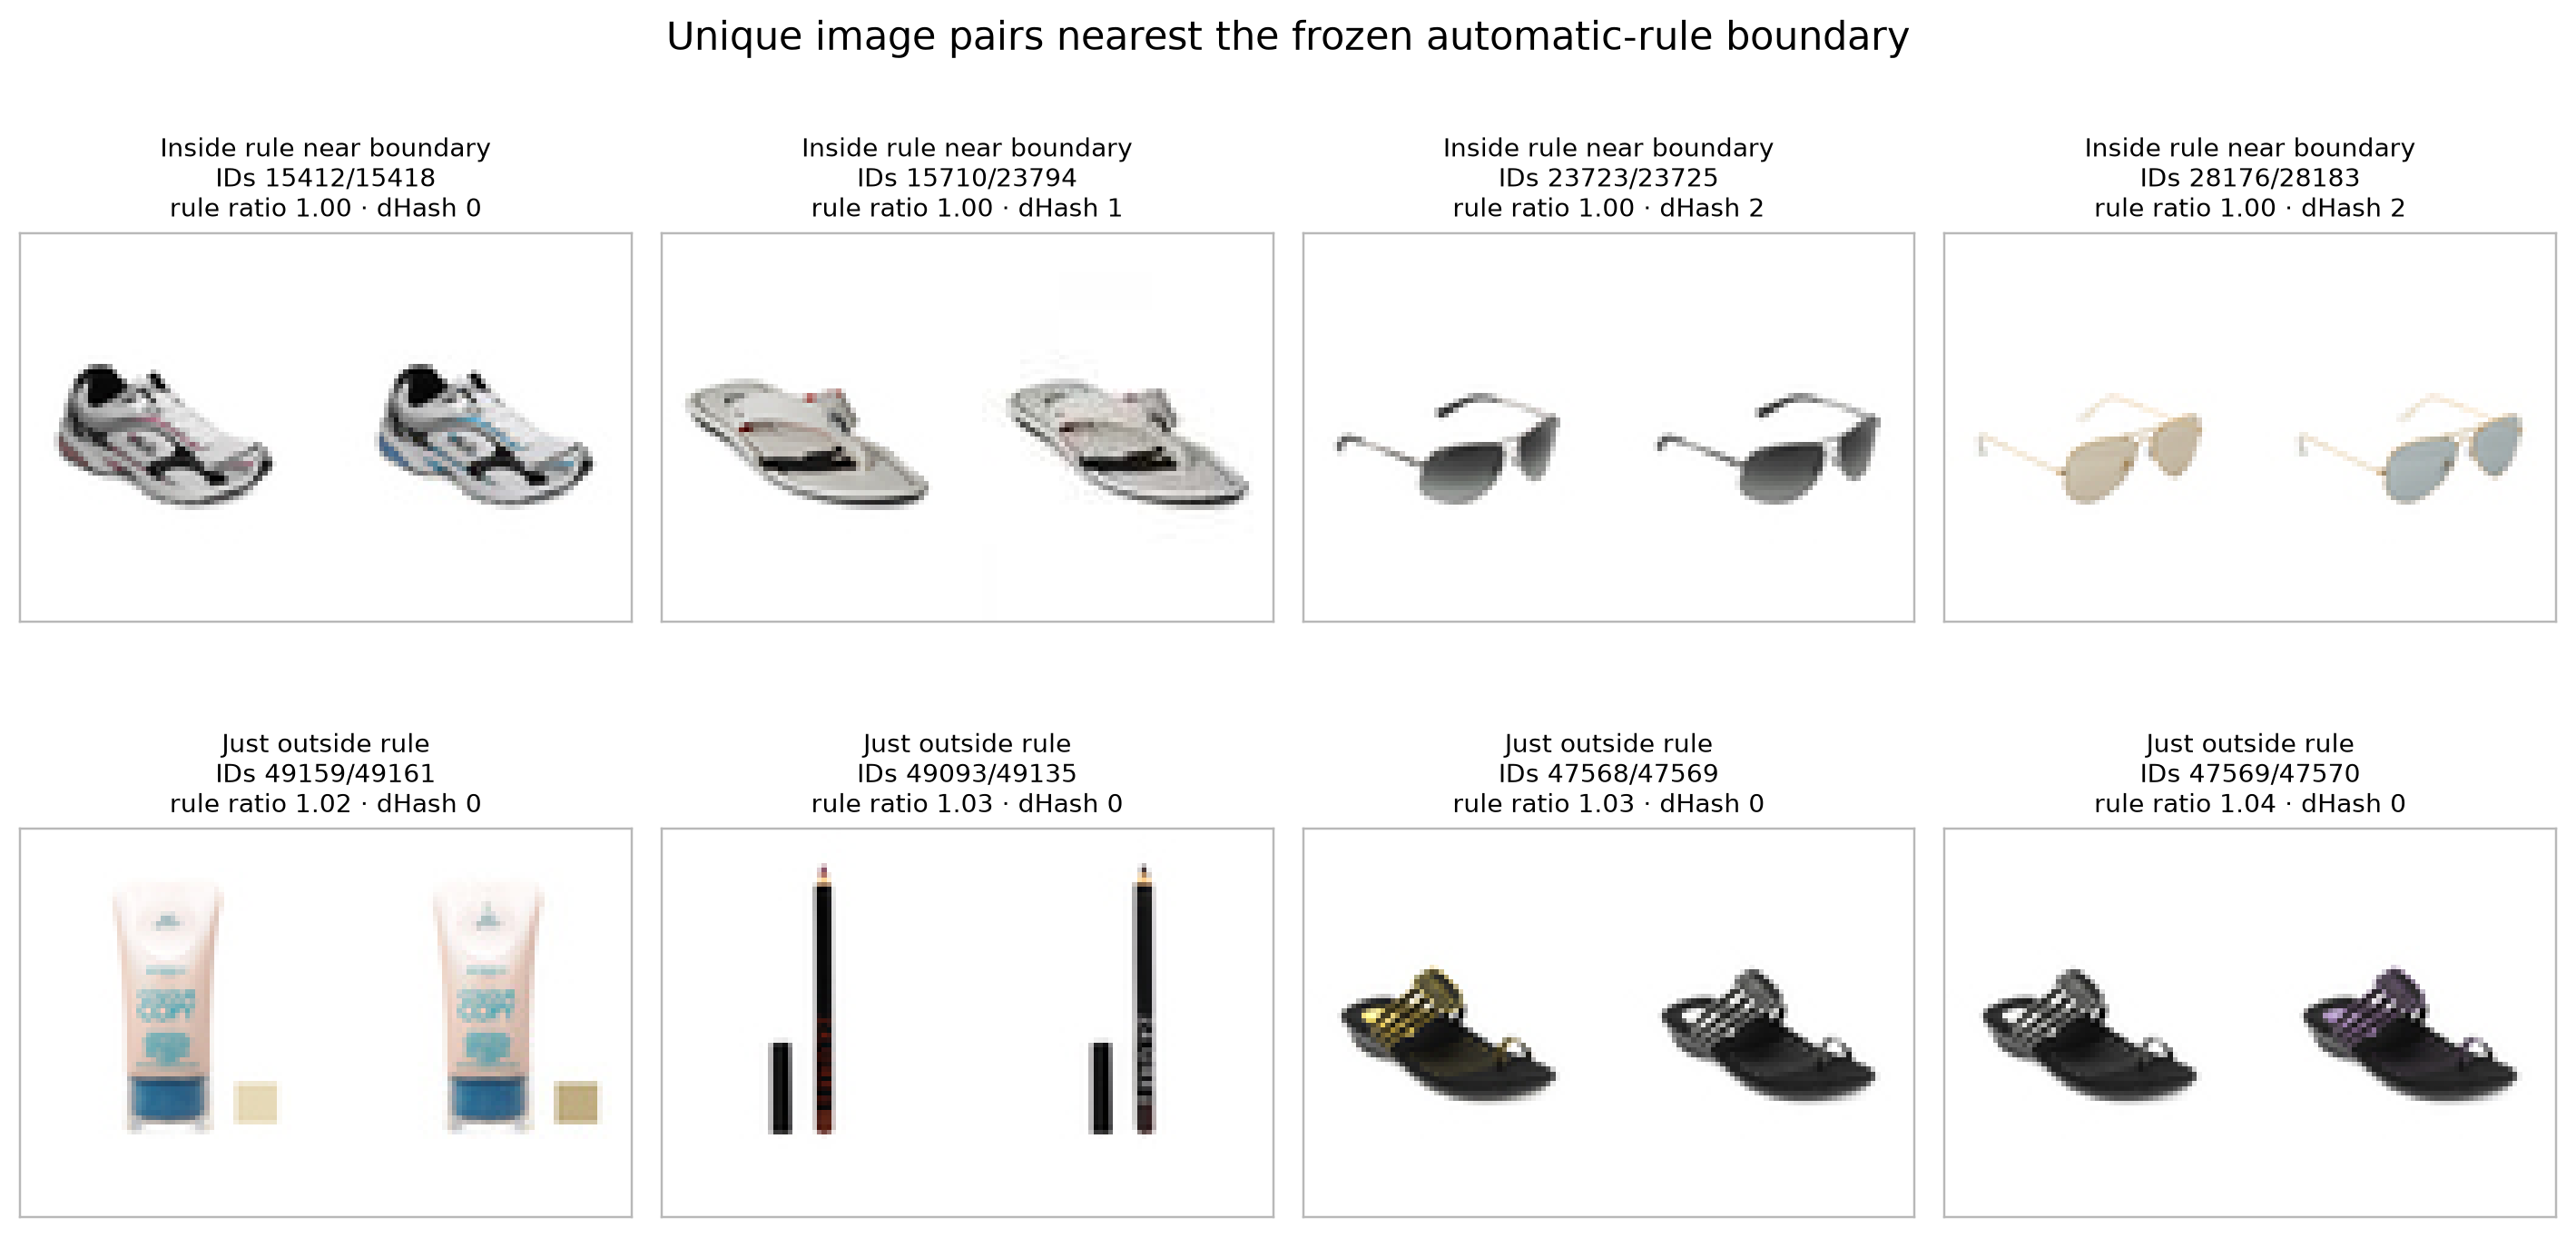


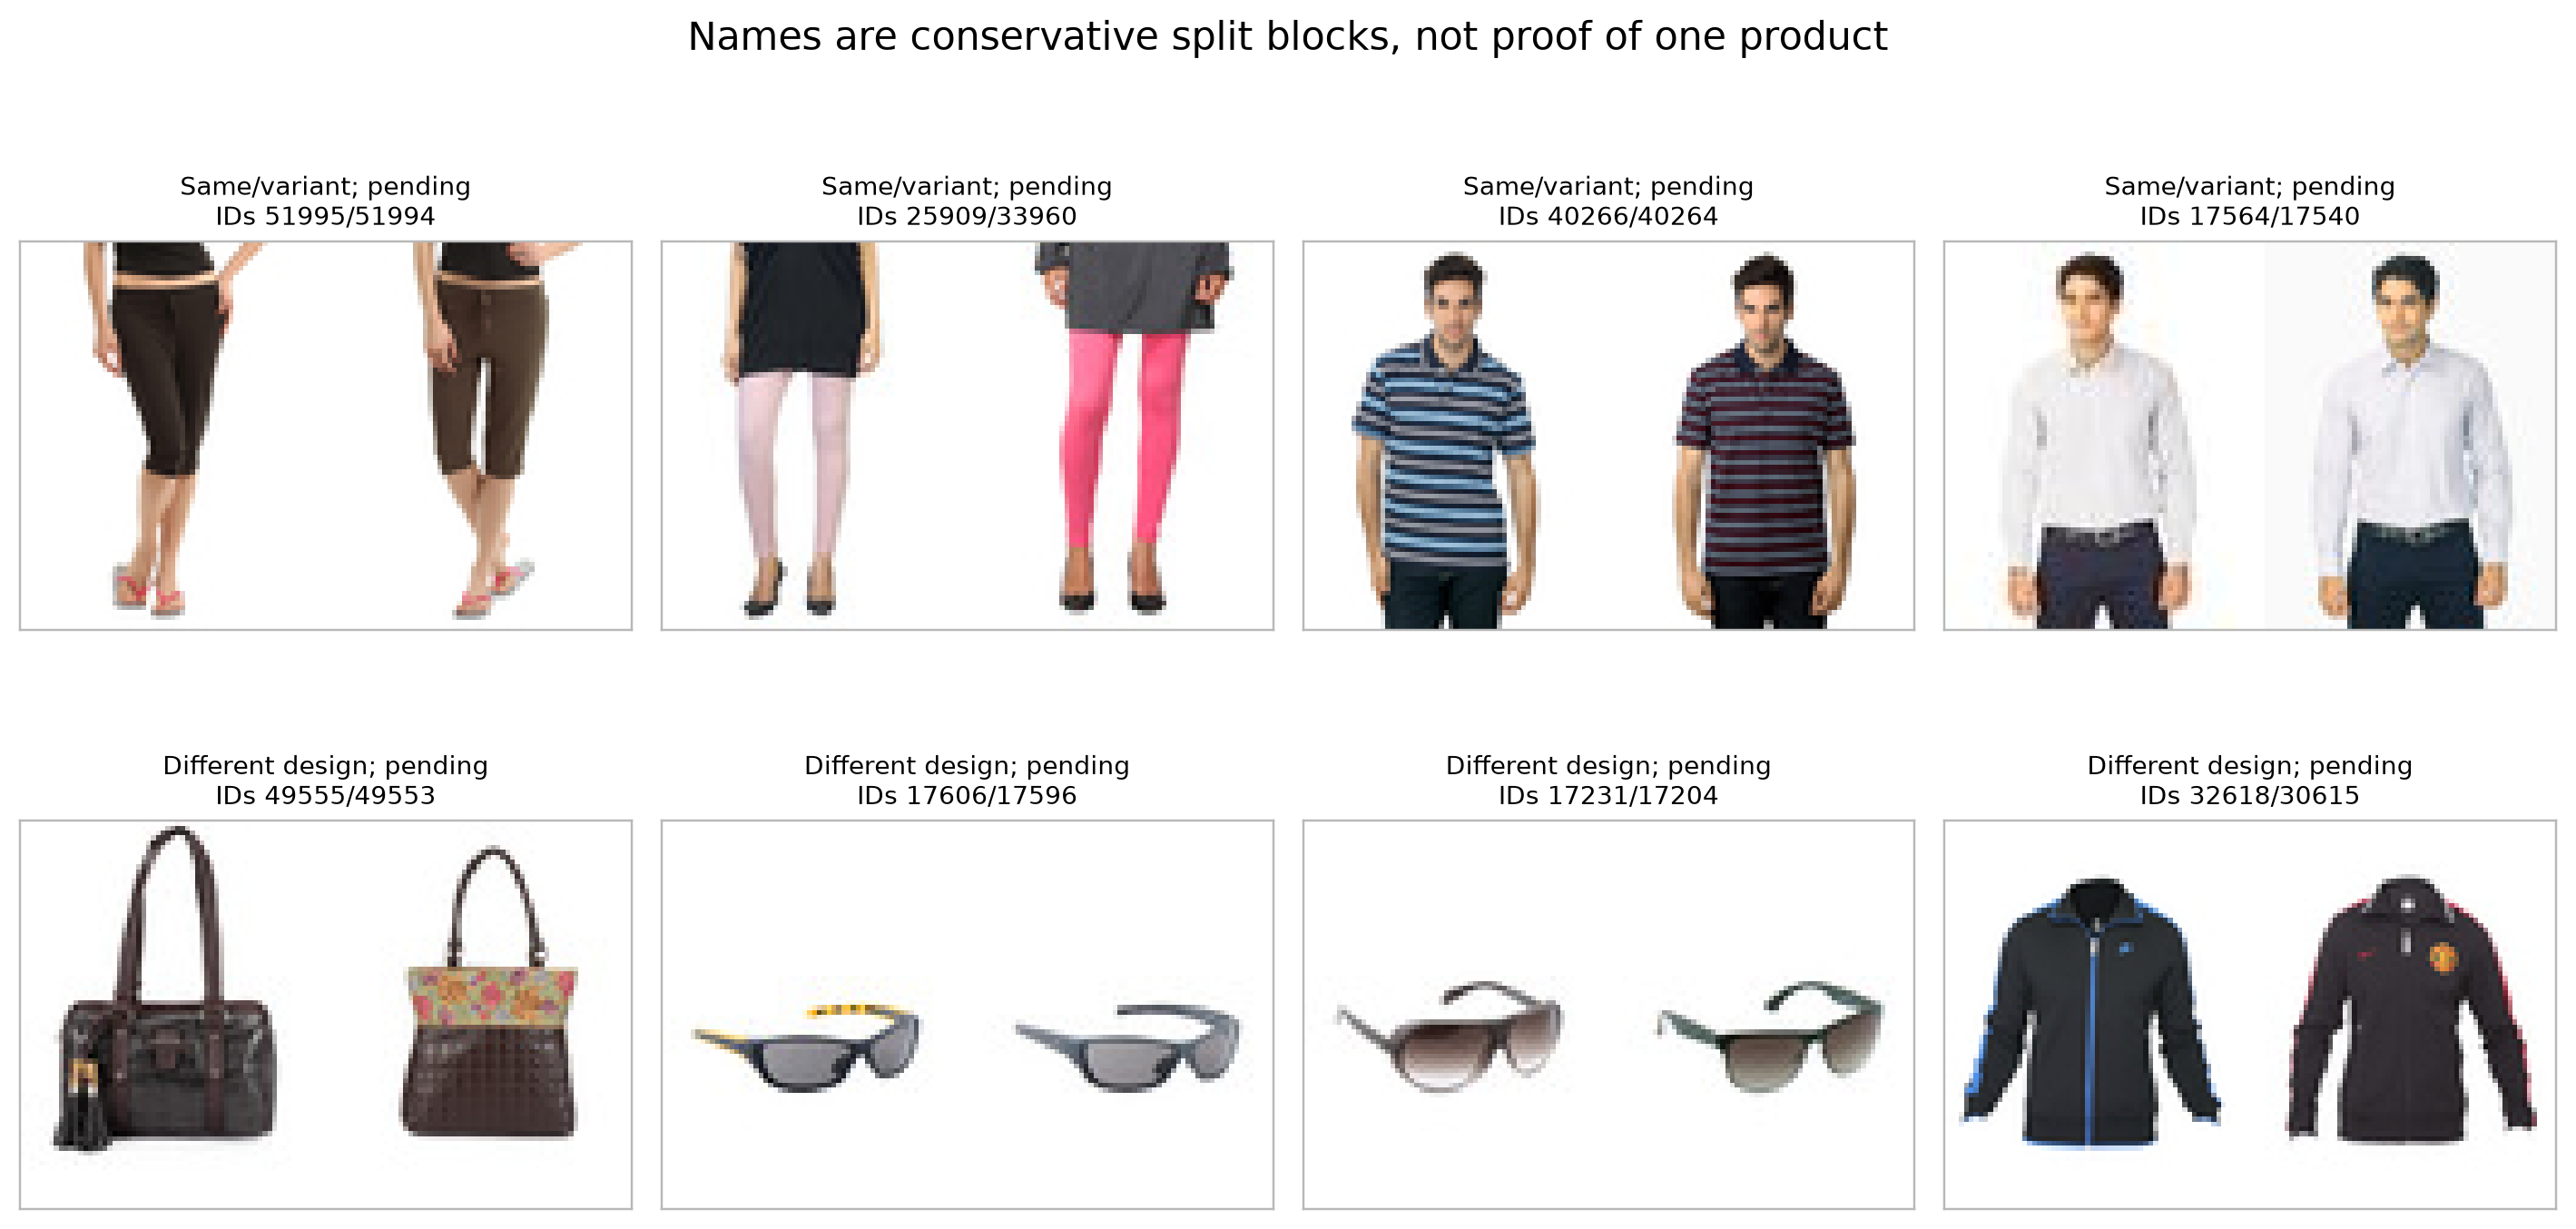

In [11]:
duplicate_summary = pd.DataFrame(
    [
        {
            "check": "exact SHA groups crossing partitions",
            "value": crossing_checks["exact_sha256_groups"],
            "required": 0,
        },
        {
            "check": "active family groups crossing partitions",
            "value": crossing_checks["product_family_groups"],
            "required": 0,
        },
        {
            "check": "active name keys crossing partitions",
            "value": crossing_checks["normalized_name_keys"],
            "required": 0,
        },
        {
            "check": "accepted visual edges crossing partitions",
            "value": len(visual_crossings),
            "required": 0,
        },
        {
            "check": "quarantined labelled rows",
            "value": int(splits["partition"].eq("quarantine").sum()),
            "required": "report",
        },
        {"check": "official prediction IDs in labelled split", "value": 0, "required": 0},
    ]
)
family_policy_summary = pd.DataFrame(
    [
        {
            "check": "active family groups",
            "value": int(active["product_family_group"].nunique()),
            "meaning": "allocation unit",
        },
        {
            "check": "active multi-row family groups",
            "value": int(active.groupby("product_family_group").size().gt(1).sum()),
            "meaning": "kept whole",
        },
        {
            "check": "largest active family",
            "value": int(active.groupby("product_family_group").size().max()),
            "meaning": "possible over-block size",
        },
        {
            "check": "name review status",
            "value": family_summary.get("product_name_review", {}).get("status", "not supplied"),
            "meaning": "provisional only",
        },
    ]
)
save_csv(duplicate_summary, "duplicate_summary.csv")
save_csv(family_policy_summary, "family_policy_summary.csv")
save_csv(review_summary, "review_summary.csv")

duplicate_figure = plot_duplicate_review(train, near_candidates)
name_figure = plot_name_review(train, loaded_reviews["normalized-name sample"])
show_table(duplicate_summary, "Leakage checks")
show_table(review_summary, "Human review is still pending")
show_figure(
    duplicate_figure,
    (
        "Figure 1. Train-only visual pairs show automatic rule matches and rejections. "
        "All human calls remain pending sign-off."
    ),
)
show_figure(
    name_figure,
    (
        "Figure 2. Normalized product names are conservative split blocks. Provisional image "
        "pairs cannot prove one product or justify relabelling."
    ),
)

> **Finding.** Exact hashes, accepted visual links, normalized names, and product-family groups
> have zero crossings between active partitions. Sixty-one labelled rows are quarantined. Figures 1
> and 2 show convincing pairs alongside ambiguous cases, so the visual and name rules still require
> judgement. All 250 sampled review rows remain unsigned; no human-precision claim is made.
>
> **Modelling consequence.** Splitting and sampling operate at product-family level, not image-row
> level. Uncertain cross-role pairs remain outside model development until a reviewer signs them off.

## 4. Target distributions and class balance

Target analysis establishes prediction scope, class support, imbalance, relationships, catalogue
ambiguity, and shortcut risk. These results define the metrics and failure slices used in later
experiments.

The univariate analysis measures train support for every output and compares train and validation
class shares. This exposes rare classes and dominant labels that plain accuracy would hide.

**Code step — Target summary functions.**

Defines the rules for supported labels, training support, and train-versus-validation balance. These functions keep all denominators and label slices explicit.

In [12]:
# Target support and development-balance evidence


def target_columns(frame: pd.DataFrame, target: str) -> tuple[str, str]:
    supported = (f"{target}_supported", f"has_{target}_supported_label")
    if all(column in frame for column in supported):
        return supported
    deployed = (f"{target}_deployed", f"has_{target}_deployed_label")
    if all(column in frame for column in deployed):
        return deployed
    return target, f"has_{target}_label"


def summarize_target(train_frame: pd.DataFrame, target: str) -> dict[str, Any]:
    label_column, mask_column = target_columns(train_frame, target)
    valid = bool_mask(train_frame[mask_column])
    counts = train_frame.loc[valid, label_column].value_counts()
    return {
        "target": target,
        "source_partition": "train",
        "valid_labels": int(valid.sum()),
        "outside_supported_slice": int((~valid).sum()),
        "classes": int(len(counts)),
        "most_common": str(counts.index[0]),
        "most_common_count": int(counts.iloc[0]),
        "singletons": int(counts.eq(1).sum()),
        "classes_below_10": int(counts.lt(10).sum()),
    }


def validation_diagnostic(frame: pd.DataFrame, target: str) -> dict[str, Any]:
    label_column, mask_column = target_columns(frame, target)
    counts: dict[str, pd.Series] = {}
    denominators: dict[str, int] = {}
    for partition in ("train", "val"):
        rows = frame[frame["partition"].eq(partition)]
        valid = rows[bool_mask(rows[mask_column])]
        if valid.empty:
            raise ValueError(f"No valid {partition} labels for {target}")
        counts[partition] = valid[label_column].value_counts()
        denominators[partition] = len(valid)
    classes = counts["train"].index
    aligned = {
        partition: counts[partition].reindex(classes, fill_value=0)
        for partition in ("train", "val")
    }
    proportions = {
        partition: aligned[partition] / denominators[partition] * 100
        for partition in ("train", "val")
    }
    gaps = (proportions["train"] - proportions["val"]).abs()
    return {
        "target": target,
        "train_valid": denominators["train"],
        "val_valid": denominators["val"],
        "train_classes": len(classes),
        "classes_seen_in_val": int(aligned["val"].gt(0).sum()),
        "coverage_percent": float(aligned["val"].gt(0).mean() * 100),
        "missing_classes": "; ".join(map(str, aligned["val"][aligned["val"].eq(0)].index))
        or "None",
        "max_gap_percentage_points": float(gaps.max()),
        "mean_gap_percentage_points": float(gaps.mean()),
        "counts": aligned,
        "proportions": proportions,
    }

**Code step — Target distribution plotting functions.**

Defines the long-tail, target-distribution, and development-balance figures. Each plot uses training or validation data only as stated in its title.

In [13]:
def plot_article_tail(train_frame: pd.DataFrame) -> Path:
    deployed = bool_mask(train_frame["has_articleType_deployed_label"])
    supported = bool_mask(train_frame["has_articleType_supported_label"])
    counts = train_frame.loc[deployed, "articleType_deployed"].value_counts()
    supported_labels = set(train_frame.loc[supported, "articleType_supported"].astype(str))
    weak_labels = set(map(str, counts.index)) - supported_labels
    top = counts.head(min(25, len(counts))).sort_values()
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(14, 7), gridspec_kw={"width_ratios": [1.35, 1]}
    )
    bars = left.barh(top.index.astype(str), top.values, color=PALETTE[0])
    left.set_title("Most common official article types")
    left.set_xlabel("Training products")
    left.grid(axis="y", visible=False)
    left.bar_label(bars, labels=[f"{value:,}" for value in top.values], padding=3, fontsize=8)
    if len(top):
        left.set_xlim(0, max(top.max() * 1.18, 1))

    ranks = np.arange(1, len(counts) + 1)
    is_weak = np.array([str(label) in weak_labels for label in counts.index])
    right.plot(ranks, counts.values, color="#9CA3AF", linewidth=1.2, zorder=1)
    right.scatter(
        ranks[~is_weak],
        counts.values[~is_weak],
        color=PALETTE[0],
        s=18,
        label=f"Supported primary slice: {len(supported_labels)}",
        zorder=2,
    )
    right.scatter(
        ranks[is_weak],
        counts.values[is_weak],
        color=PALETTE[1],
        s=28,
        marker="D",
        label=f"Weak but official: {len(weak_labels)}",
        zorder=3,
    )
    right.axhline(10, color="#6B7280", linestyle="--", linewidth=1, label="10 products")
    right.set_yscale("log")
    right.set_title(f"All {len(counts)} official output classes")
    right.set_xlabel("Class rank")
    right.set_ylabel("Training products (log scale)")
    right.legend(frameon=False, fontsize=8)
    fig.suptitle("Article type has a strong long tail (training products only)")
    fig.tight_layout()
    return save_figure(fig, "article_type_long_tail.png")


def plot_target_distributions(train_frame: pd.DataFrame) -> Path:
    targets = ("gender", "season", "usage")
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.3))
    for axis, target in zip(axes, targets):
        valid = bool_mask(train_frame[f"has_{target}_deployed_label"])
        counts = train_frame.loc[valid, f"{target}_deployed"].value_counts()
        labels = list(map(str, counts.index))
        values = counts.astype(int).tolist()
        missing = int((~valid).sum())
        colors = [PALETTE[0]] * len(values)
        if missing:
            labels.append("Missing")
            values.append(missing)
            colors.append(PALETTE[1])
        bars = axis.bar(labels, values, color=colors)
        if target == "usage" and values and max(values) / max(min(values), 1) > 20:
            axis.set_yscale("log")
            axis.set_ylabel("Training images (log scale)")
        else:
            axis.set_ylabel("Training images")
        axis.set_title(f"{target} (valid n={int(valid.sum()):,})")
        axis.tick_params(axis="x", rotation=35)
        for label in axis.get_xticklabels():
            label.set_ha("right")
        axis.bar_label(bars, labels=[f"{value:,}" for value in values], padding=2, fontsize=8)
        axis.grid(axis="x", visible=False)
    fig.suptitle("Official training target distributions and real blanks")
    fig.tight_layout()
    return save_figure(fig, "target_distributions.png")


def plot_development_balance(frame: pd.DataFrame, diagnostics: dict[str, dict[str, Any]]) -> Path:
    article = diagnostics["articleType"]
    classes = list(article["counts"]["train"].head(10).index)
    positions = np.arange(len(classes))
    width = 0.38
    fig = plt.figure(figsize=(14, 9))
    grid = fig.add_gridspec(2, 2, height_ratios=(1.35, 1), hspace=0.55, wspace=0.35)
    top = fig.add_subplot(grid[0, :])
    gap_axis = fig.add_subplot(grid[1, 0])
    coverage_axis = fig.add_subplot(grid[1, 1])
    train_values = article["proportions"]["train"].reindex(classes).to_numpy()
    val_values = article["proportions"]["val"].reindex(classes).to_numpy()
    train_bars = top.bar(
        positions - width / 2, train_values, width, color=PALETTE[0], label="Train"
    )
    val_bars = top.bar(
        positions + width / 2, val_values, width, color=PALETTE[1], label="Validation"
    )
    top.set_xticks(positions, classes, rotation=32, ha="right")
    top.set_ylabel("Within-partition valid labels (%)")
    top.set_title("Top article types selected by training frequency")
    top.legend(frameon=False)
    top.bar_label(train_bars, fmt="%.1f", padding=2, fontsize=7)
    top.bar_label(val_bars, fmt="%.1f", padding=2, fontsize=7)
    labels = ("Article type", "Season", "Gender", "Usage")
    gaps = [diagnostics[target]["max_gap_percentage_points"] for target in TARGET_COLUMNS]
    gap_bars = gap_axis.barh(labels, gaps, color=PALETTE[:4])
    gap_axis.invert_yaxis()
    gap_axis.set_title("Largest class-share gap")
    gap_axis.set_xlabel("Percentage points")
    gap_axis.bar_label(gap_bars, fmt="%.2f pp", padding=3, fontsize=8)
    coverage = [diagnostics[target]["coverage_percent"] for target in TARGET_COLUMNS]
    coverage_bars = coverage_axis.barh(labels, coverage, color=PALETTE[:4])
    coverage_axis.invert_yaxis()
    coverage_axis.set_xlim(0, 108)
    coverage_axis.set_title("Training classes seen in validation")
    coverage_axis.set_xlabel("Coverage (%)")
    coverage_axis.bar_label(coverage_bars, fmt="%.1f%%", padding=3, fontsize=8)
    fig.suptitle("Development balance uses local percentages; holdout stays closed")
    fig.subplots_adjust(top=0.92, bottom=0.08, left=0.1, right=0.96)
    return save_figure(fig, "development_balance.png")

**Code step — Taxonomy and support evidence.**

Builds the train-fitted taxonomy, records limited official classes, checks the literal NA label, and saves target and validation summaries.

In [14]:
label_maps = load_label_maps(PROCESSED / "label_maps.json")
taxonomy_policy = json.loads(TAXONOMY_PATH.read_text(encoding="utf-8"))
if taxonomy_policy.get("fit_partition") != "train":
    raise ValueError("The deployment taxonomy was not fitted on train")
taxonomy_rows = []
exclusion_rows = []
for target in TARGET_COLUMNS:
    official = list(map(str, label_maps[target]["classes"]))
    supported = sorted(
        set(
            train.loc[
                bool_mask(train[f"has_{target}_supported_label"]),
                f"{target}_supported",
            ].astype(str)
        )
    )
    limited = sorted(set(official) - set(supported))
    policy_supported = set(taxonomy_policy["targets"][target]["supported_classes"])
    if set(supported) != policy_supported:
        raise ValueError(f"Frozen supported classes disagree for {target}")
    family_support = (
        train.loc[
            bool_mask(train[f"has_{target}_supported_label"]),
            [f"{target}_supported", "product_family_group"],
        ]
        .drop_duplicates()
        .groupby(f"{target}_supported")["product_family_group"]
        .nunique()
    )
    if not family_support.ge(3).all():
        raise ValueError(f"A supported {target} class has fewer than three train families")
    validation_raw = bool_mask(validation[f"has_{target}_label"])
    validation_known = bool_mask(validation[f"has_{target}_deployed_label"])
    validation_unknown = sorted(
        validation.loc[validation_raw & ~validation_known, target].astype(str).unique()
    )
    taxonomy_rows.append(
        {
            "target": target,
            "official_output_classes": len(official),
            "supported_primary_metric_classes": len(supported),
            "limited_but_still_official": len(limited),
            "validation_unknown_to_train": len(validation_unknown),
            "semantic_merges": "None",
            "source": "train-fitted label map and train family support",
        }
    )
    for label in limited:
        groups = train.loc[
            bool_mask(train[f"has_{target}_deployed_label"])
            & train[f"{target}_deployed"].eq(label),
            "product_family_group",
        ].nunique()
        exclusion_rows.append(
            {
                "target": target,
                "official_class": label,
                "train_family_groups": int(groups),
                "action": "keep train-fitted output; report outside primary macro metric",
            }
        )
taxonomy_summary = pd.DataFrame(taxonomy_rows)
taxonomy_exclusions = pd.DataFrame(
    exclusion_rows,
    columns=["target", "official_class", "train_family_groups", "action"],
)
if "NA" not in set(label_maps["usage"]["classes"]):
    raise ValueError('The literal "NA" usage label was lost')
if not train.loc[bool_mask(train["has_usage_deployed_label"]), "usage_deployed"].eq("NA").any():
    raise ValueError('The literal "NA" usage label is not present in training')

diagnostics = {target: validation_diagnostic(splits, target) for target in TARGET_COLUMNS}
validation_summary = pd.DataFrame(
    [
        {key: value for key, value in diagnostic.items() if key not in {"counts", "proportions"}}
        for diagnostic in diagnostics.values()
    ]
)
target_summary = pd.DataFrame([summarize_target(train, target) for target in TARGET_COLUMNS])
save_csv(taxonomy_summary, "taxonomy_summary.csv")
save_csv(taxonomy_exclusions, "taxonomy_exclusions.csv")
save_csv(validation_summary, "validation_summary.csv")
save_csv(target_summary, "target_summary.csv")

PosixPath('/home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/evidence/eda/target_summary.csv')

**Code step — Target distribution results.**

Creates the target profile table and Figures 3 to 5. The outputs show class support, imbalance, and development balance without opening holdout labels.

,target,official_outputs,primary_classes,limited_classes,train_n,val_n,coverage_pct,top_class,dominant_share_pct,classes_lt10
0,articleType,124,100,24,"26,948","5,768",100.000,Tshirts,17.600,13
1,season,4,4,0,"26,975","5,778",100.000,Summer,49.600,0
2,gender,5,5,0,"26,992","5,781",100.000,Men,54.200,0
3,usage,9,8,1,"26,990","5,781",100.000,Casual,76.700,0



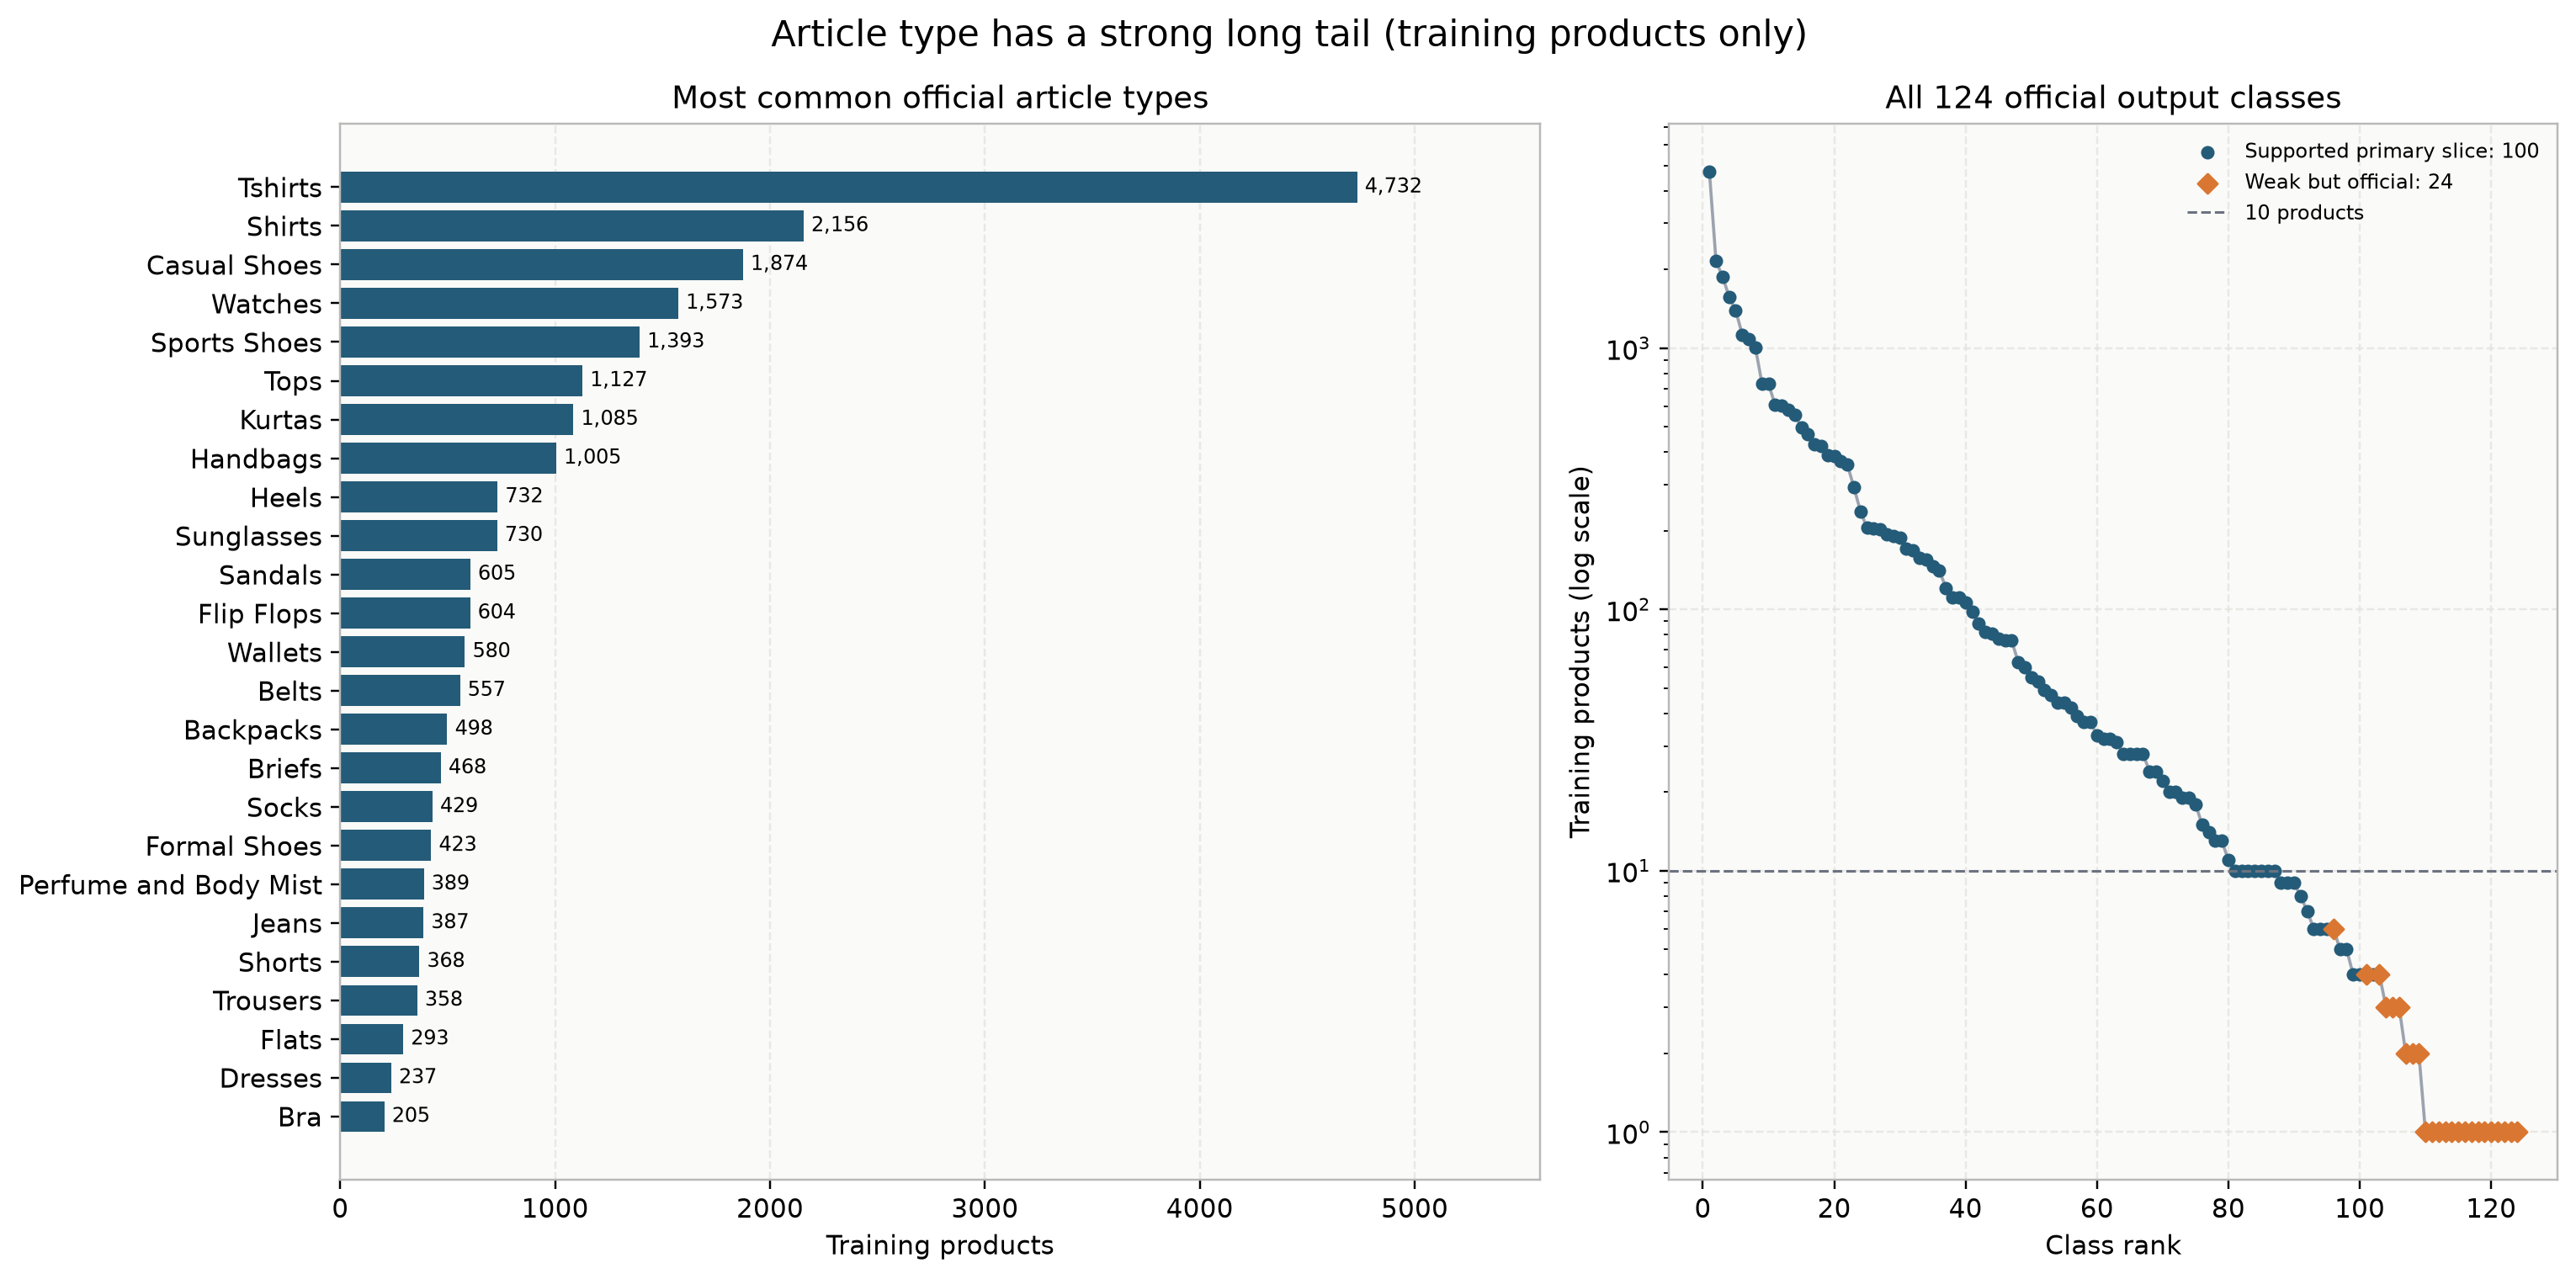


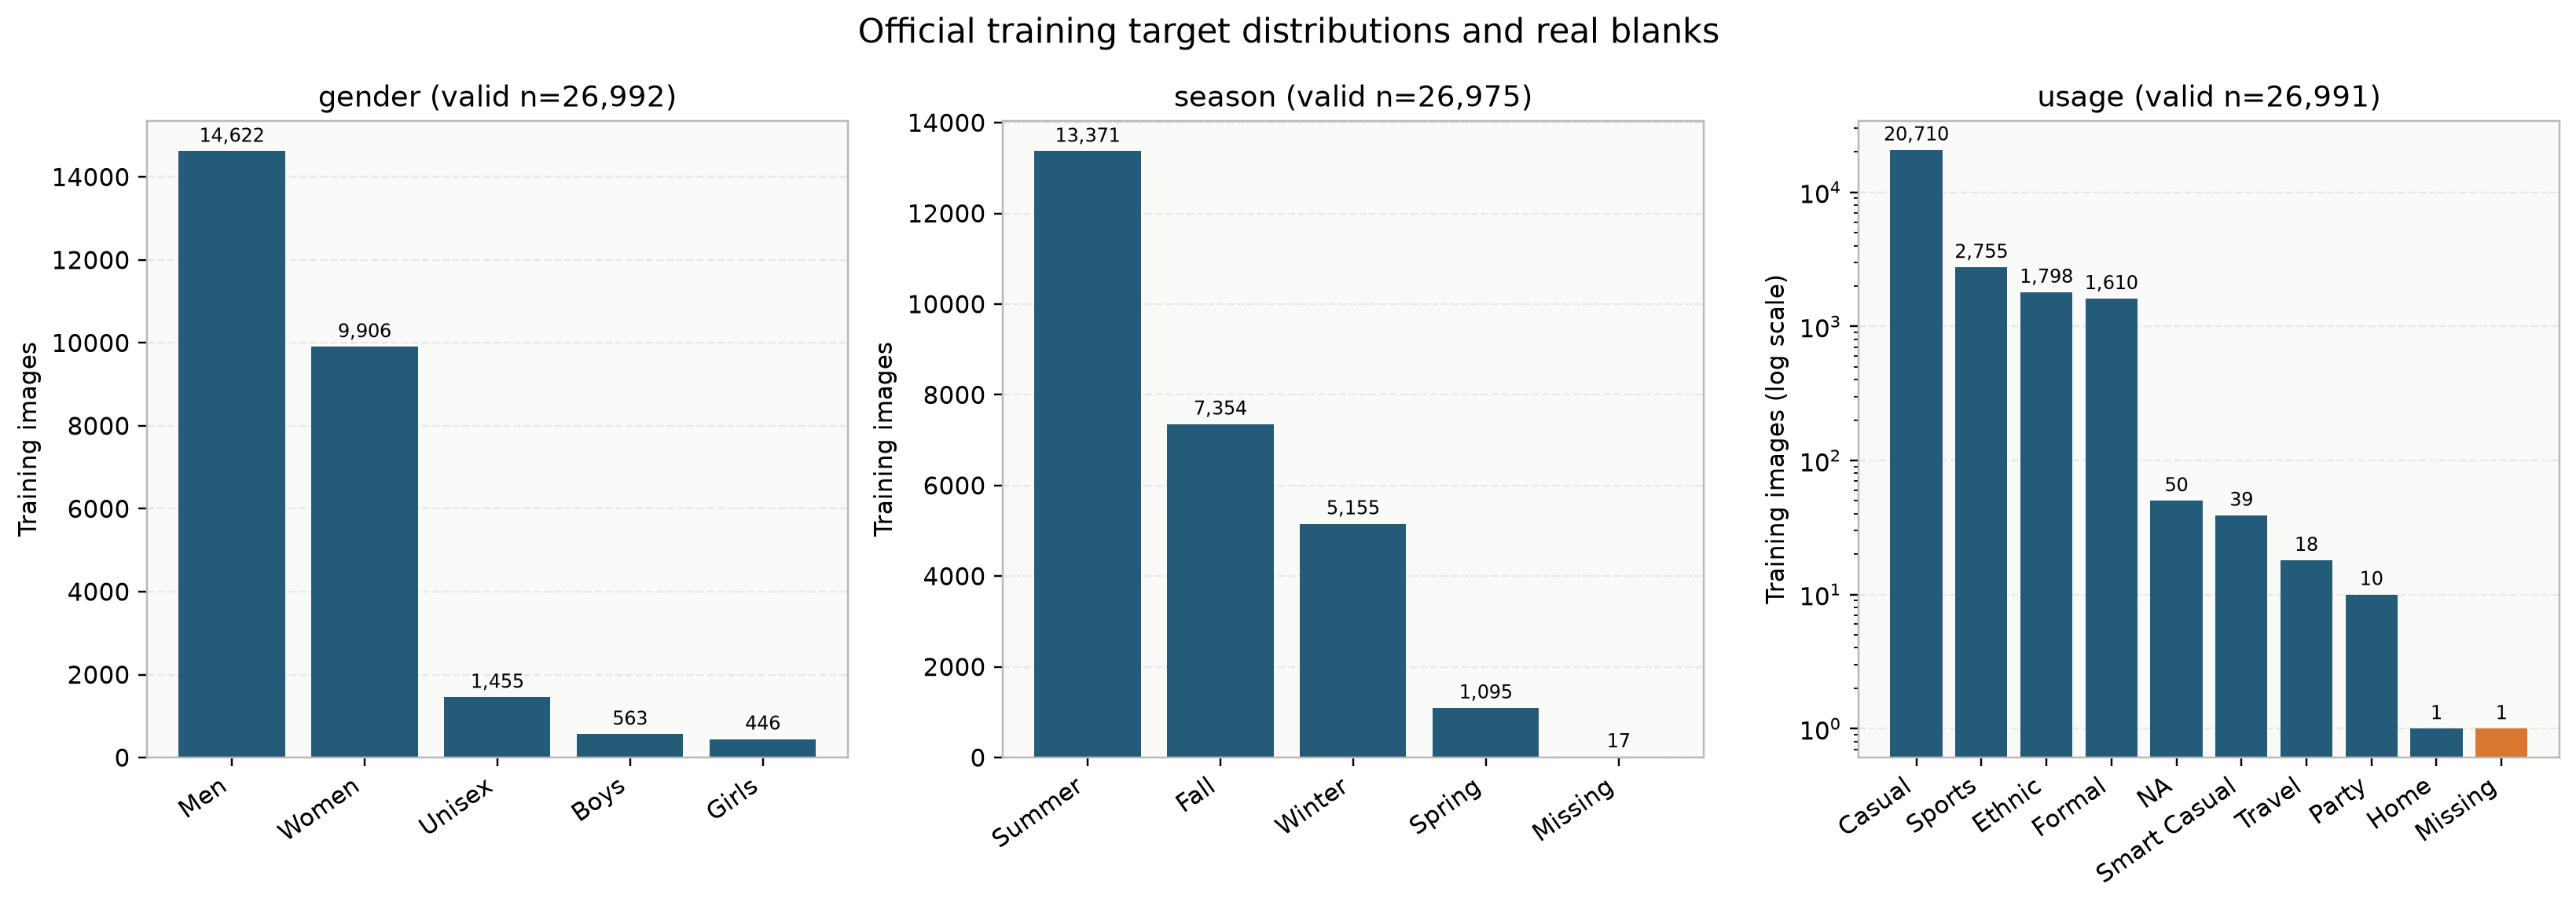


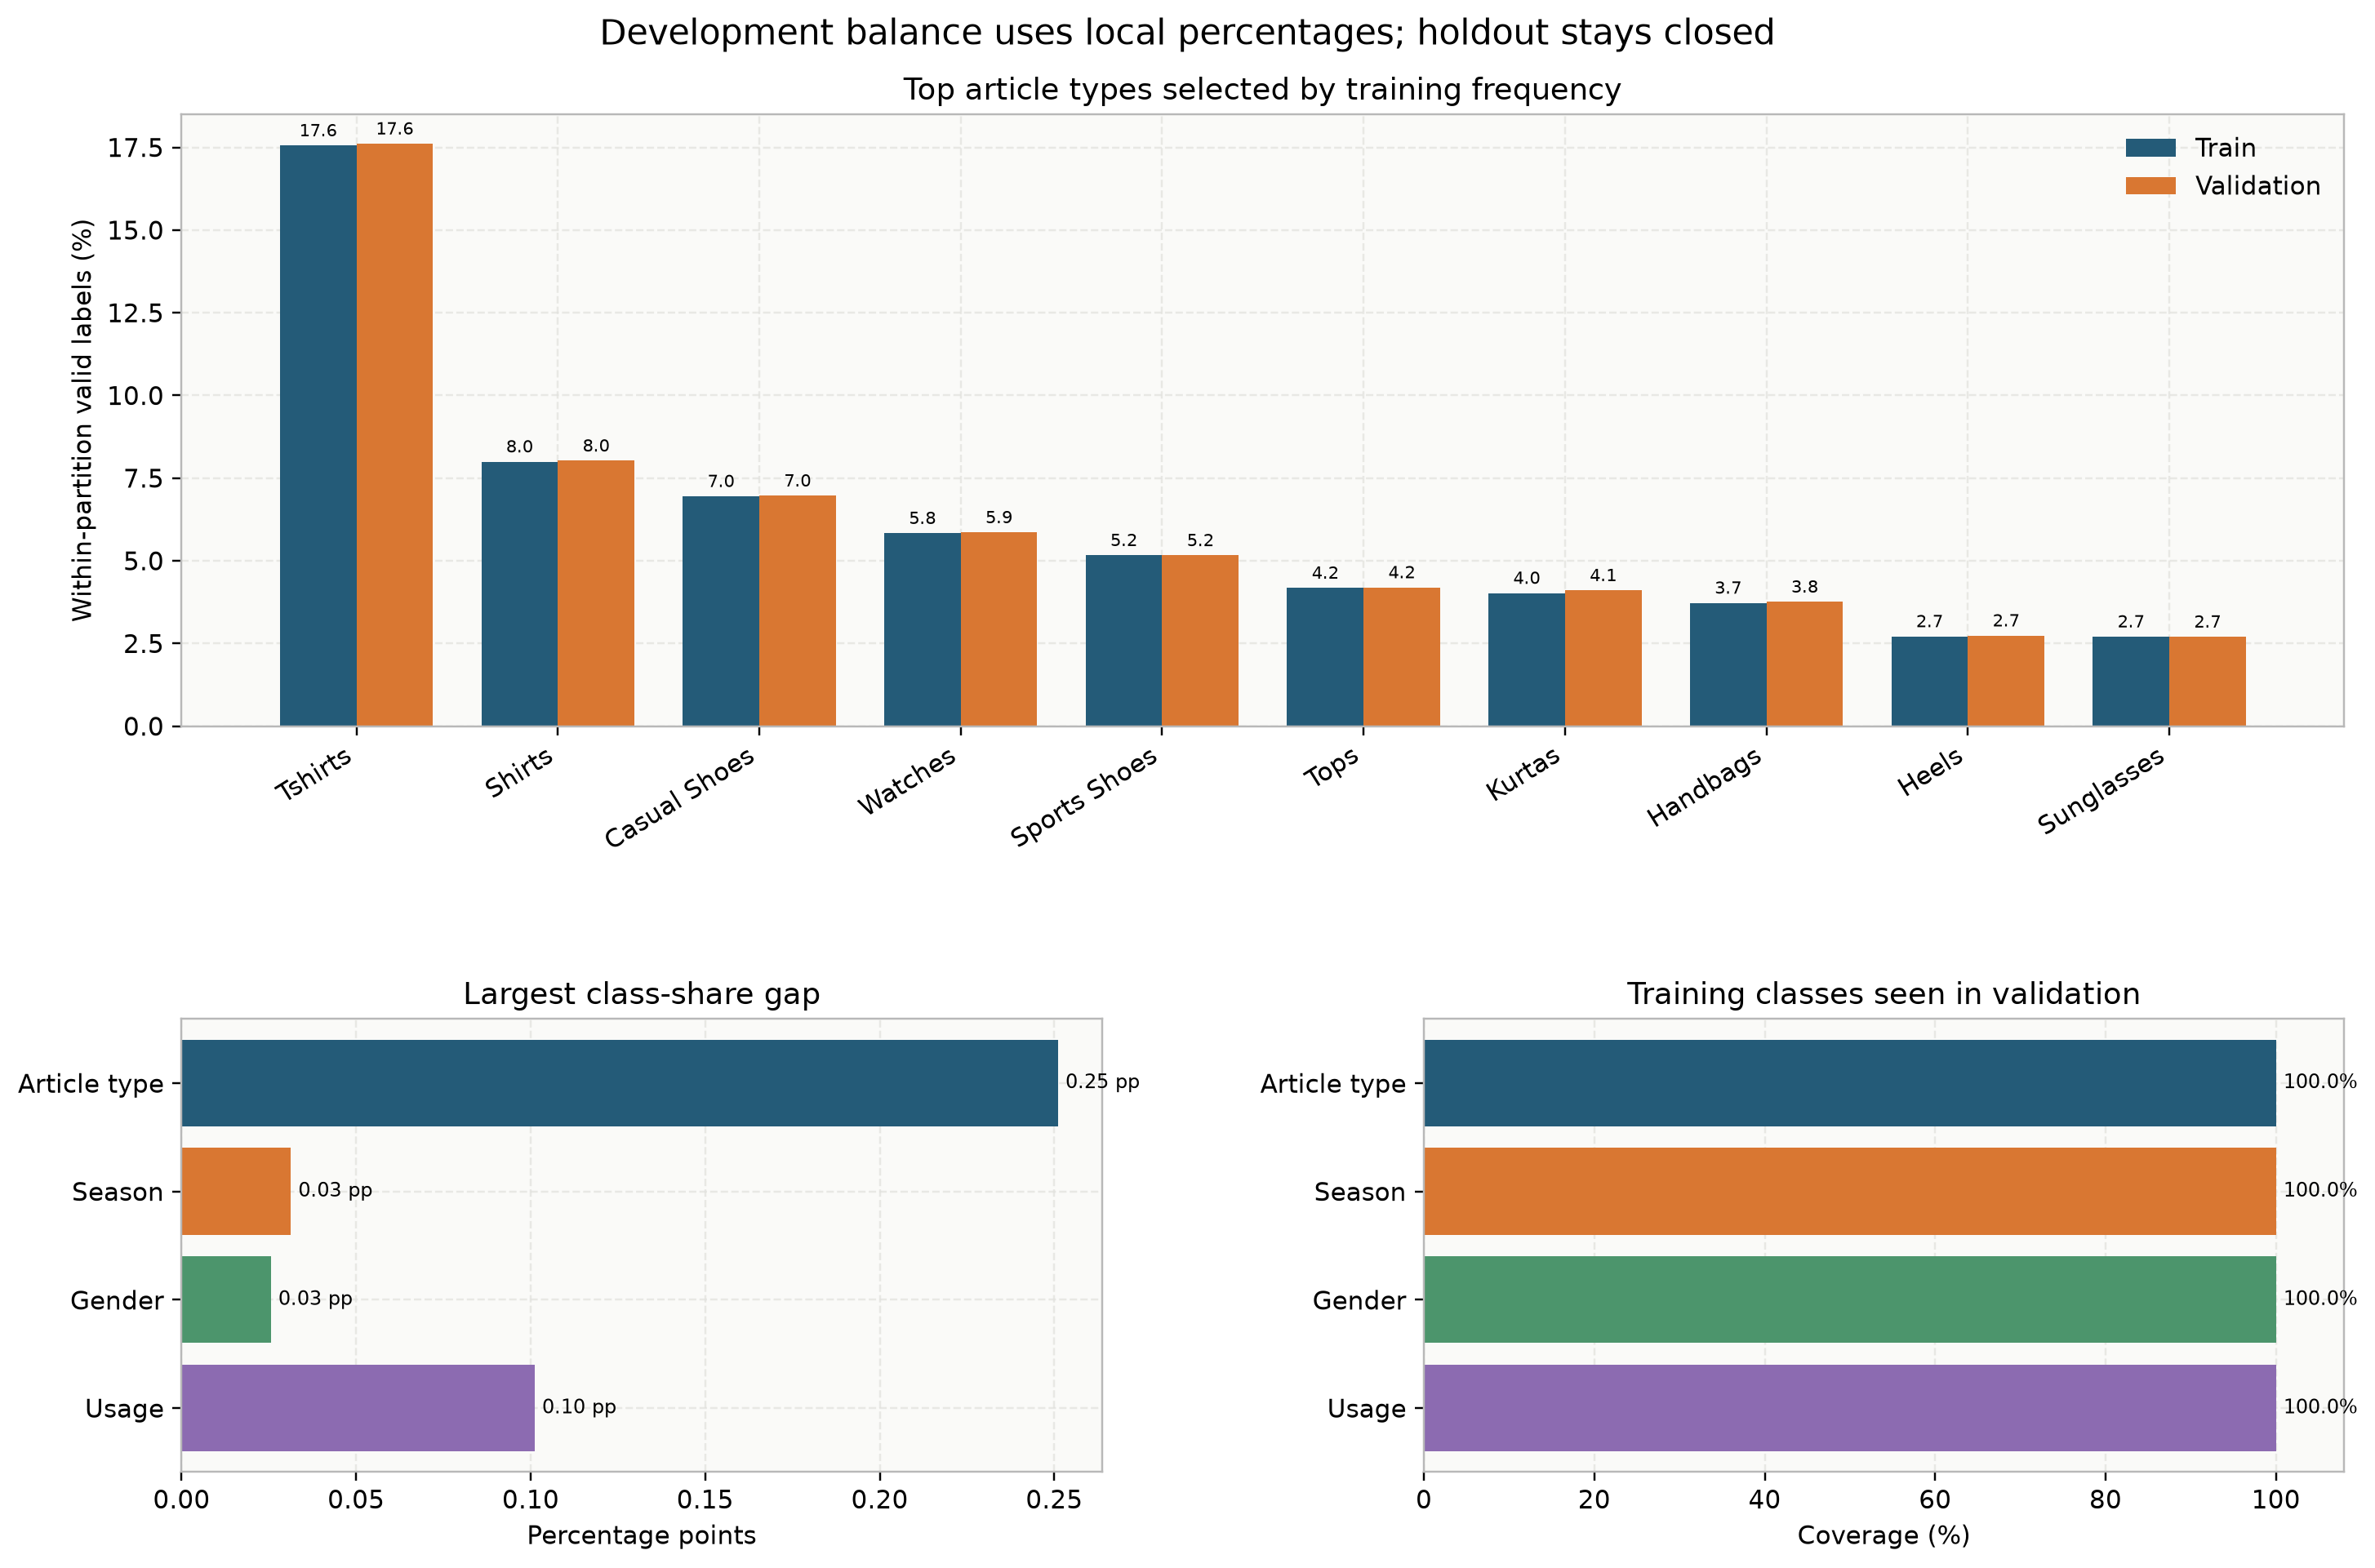

In [15]:
article_figure = plot_article_tail(train)
target_figure = plot_target_distributions(train)
balance_figure = plot_development_balance(splits, diagnostics)
taxonomy_display = taxonomy_summary.drop(columns="source").rename(
    columns={
        "official_output_classes": "official_outputs",
        "supported_primary_metric_classes": "primary_classes",
        "limited_but_still_official": "limited_classes",
        "validation_unknown_to_train": "val_unknown",
    }
)
validation_display = validation_summary.rename(
    columns={
        "train_valid": "train_n",
        "val_valid": "val_n",
        "classes_seen_in_val": "val_seen",
        "coverage_percent": "coverage_pct",
        "missing_classes": "missing",
        "max_gap_percentage_points": "max_gap_pp",
        "mean_gap_percentage_points": "mean_gap_pp",
    }
).round({"coverage_pct": 2, "max_gap_pp": 3, "mean_gap_pp": 3})
target_display = target_summary.drop(columns="source_partition").rename(
    columns={
        "valid_labels": "train_valid",
        "outside_supported_slice": "outside_primary",
        "most_common": "top_class",
        "most_common_count": "top_n",
        "classes_below_10": "classes_lt10",
    }
)
task_profile = taxonomy_display.merge(
    validation_display[["target", "train_n", "val_n", "coverage_pct", "max_gap_pp"]],
    on="target",
    validate="one_to_one",
).merge(
    target_display[["target", "top_class", "top_n", "classes_lt10"]],
    on="target",
    validate="one_to_one",
)
task_profile["dominant_share_pct"] = task_profile["top_n"] / task_profile["train_n"] * 100
task_profile = task_profile[
    [
        "target",
        "official_outputs",
        "primary_classes",
        "limited_classes",
        "train_n",
        "val_n",
        "coverage_pct",
        "top_class",
        "dominant_share_pct",
        "classes_lt10",
    ]
].round({"coverage_pct": 2, "dominant_share_pct": 1})
show_table(task_profile, "Task difficulty and fair-comparison profile")
show_figure(
    article_figure,
    (
        "Figure 3. Training-only article type counts show the frozen output classes. Orange marks "
        "explicitly account for weak train classes outside the primary slice."
    ),
)
show_figure(
    target_figure,
    (
        "Figure 4. Training-only official gender, season, and usage distributions keep literal "
        "NA separate from true blanks."
    ),
)
show_figure(
    balance_figure,
    (
        "Figure 5. Train and validation percentages use local denominators and the supported "
        "metric slice. Holdout stays closed."
    ),
)

> **Finding.** `articleType` has 124 official outputs, while 100 have at least three independent
> training families for the primary comparison. Thirteen supported classes still have fewer than ten
> training examples. `usage` is highly concentrated: Casual accounts for 20,710 of 26,990 valid
> primary rows, or 76.7%. Validation contains every supported class, and the largest class-share gap
> is only 0.251 percentage points. Figures 3–5 show the long tail, imbalance, and close development
> balance.
>
> **Modelling consequence.** Accuracy is not a ranking metric. The main score is macro-F1, supported
> by per-class recall, confusion matrices, and explicit results for limited official outputs.
> Ordinary loss must be compared with an imbalance-aware alternative under the same training budget.

## 5. Target relationships and bias

The multivariate analysis measures shared information between targets and tests whether catalogue
hierarchy, product naming, or dominant label combinations could create misleading shortcuts.

**Code step — Relationship metrics and summaries.**

Defines normalized mutual information, hierarchy summaries, season-family summaries, and readable heat-map labels.

In [16]:
# Target relationship, hierarchy, ambiguity, and bias evidence


def normalized_mutual_information(first: pd.Series, second: pd.Series) -> float:
    table = pd.crosstab(first, second).to_numpy(dtype=float)
    if table.size == 0 or table.sum() == 0:
        return 0.0
    probability = table / table.sum()
    row_probability = probability.sum(axis=1, keepdims=True)
    column_probability = probability.sum(axis=0, keepdims=True)
    expected = row_probability @ column_probability
    valid = probability > 0
    information = float((probability[valid] * np.log(probability[valid] / expected[valid])).sum())
    row_entropy = float(
        -(row_probability[row_probability > 0] * np.log(row_probability[row_probability > 0])).sum()
    )
    column_entropy = float(
        -(
            column_probability[column_probability > 0]
            * np.log(column_probability[column_probability > 0])
        ).sum()
    )
    denominator = row_entropy + column_entropy
    return 0.0 if denominator == 0 else 2 * information / denominator


def hierarchy_summary(train_frame: pd.DataFrame) -> pd.DataFrame:
    rows = train_frame[bool_mask(train_frame["has_articleType_supported_label"])]
    return (
        rows.groupby("articleType_supported", sort=True)
        .agg(
            train_rows=("id", "size"),
            master_category_count=("masterCategory", "nunique"),
            sub_category_count=("subCategory", "nunique"),
            master_categories=("masterCategory", lambda x: "; ".join(sorted(set(x)))),
            sub_categories=("subCategory", lambda x: "; ".join(sorted(set(x)))),
        )
        .reset_index()
        .rename(columns={"articleType_supported": "article_type"})
    )


def season_family_summary(train_frame: pd.DataFrame) -> pd.DataFrame:
    valid = train_frame[bool_mask(train_frame["has_season_supported_label"])]
    grouped = valid.groupby("product_family_group").agg(
        rows=("id", "size"),
        seasons=("season_supported", "nunique"),
        family_group_basis=("family_group_basis", "first"),
    )
    rows = []
    for basis, groups in grouped[grouped["rows"].gt(1)].groupby("family_group_basis", sort=True):
        basis_text = str(basis)
        name_involved = "normalized_product_name" in basis_text
        visual_only = not name_involved and any(
            token in basis_text for token in ("exact_sha256", "accepted_near_duplicate")
        )
        rows.append(
            {
                "family_group_basis": basis_text,
                "multirow_train_groups": len(groups),
                "mixed_season_train_groups": int(groups["seasons"].gt(1).sum()),
                "name_block_involved": name_involved,
                "eligible_as_label_ambiguity_signal": visual_only,
                "interpretation": (
                    "possible visual-family ambiguity; human review is pending"
                    if visual_only
                    else "name blocking may be broad; this cannot prove label noise"
                ),
            }
        )
    columns = [
        "family_group_basis",
        "multirow_train_groups",
        "mixed_season_train_groups",
        "name_block_involved",
        "eligible_as_label_ambiguity_signal",
        "interpretation",
    ]
    return pd.DataFrame(rows, columns=columns)


def text_colour(image: Any, value: float) -> str:
    red, green, blue, _ = image.cmap(image.norm(float(value)))
    luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
    return "white" if luminance < 0.52 else "#111827"

**Code step — Joint-target plot.**

Defines the joint-target figure combining off-diagonal mutual information with season mixtures inside common article types.

In [17]:
def plot_joint_relationships(train_frame: pd.DataFrame, matrix: pd.DataFrame) -> Path:
    article_mask = bool_mask(train_frame["has_articleType_supported_label"]) & bool_mask(
        train_frame["has_season_supported_label"]
    )
    top_articles = (
        train_frame.loc[article_mask, "articleType_supported"].value_counts().head(12).index
    )
    season = pd.crosstab(
        train_frame.loc[
            article_mask & train_frame["articleType_supported"].isin(top_articles),
            "articleType_supported",
        ],
        train_frame.loc[
            article_mask & train_frame["articleType_supported"].isin(top_articles),
            "season_supported",
        ],
        normalize="index",
    ).reindex(top_articles)
    fig, (left, right) = plt.subplots(
        1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [0.8, 1.4]}
    )
    display_matrix = matrix.to_numpy(dtype=float).copy()
    np.fill_diagonal(display_matrix, np.nan)
    off_diagonal = display_matrix[np.isfinite(display_matrix)]
    upper = max(float(off_diagonal.max()) if len(off_diagonal) else 0.0, 0.01)
    colour_map = plt.get_cmap("Blues").with_extremes(bad="#E5E7EB")
    heat = left.imshow(display_matrix, vmin=0, vmax=upper, cmap=colour_map)
    left.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=35, ha="right")
    left.set_yticks(range(len(matrix.index)), matrix.index)
    left.set_title("Off-diagonal normalized mutual information")
    for row in range(len(matrix.index)):
        for column in range(len(matrix.columns)):
            if row == column:
                left.text(column, row, "self", ha="center", va="center", color="#4B5563")
                continue
            value = matrix.iloc[row, column]
            left.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_colour(heat, value),
            )
    colour_bar = fig.colorbar(heat, ax=left, fraction=0.046, pad=0.04)
    colour_bar.set_label("Off-diagonal NMI")
    if season.empty:
        right.axis("off")
        right.text(0.5, 0.5, "Too few classes for a season mixture", ha="center")
    else:
        season_image = right.imshow(season.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="YlOrBr")
        right.set_yticks(range(len(season.index)), season.index)
        right.set_xticks(range(len(season.columns)), season.columns, rotation=35, ha="right")
        right.set_title("Season mix inside common article types")
        for row in range(len(season.index)):
            for column in range(len(season.columns)):
                value = season.iloc[row, column]
                right.text(
                    column,
                    row,
                    f"{value:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=text_colour(season_image, value),
                )
        fig.colorbar(season_image, ax=right, fraction=0.046, pad=0.04)
    fig.suptitle("Targets are related, but one target does not replace another (train only)")
    fig.tight_layout()
    return save_figure(fig, "joint_target_relationships.png")

**Code step — Hierarchy and season plots.**

Defines separate figures for catalogue hierarchy overlap and mixed-season family review leads.

In [18]:
def plot_hierarchy(train_frame: pd.DataFrame, summary: pd.DataFrame) -> Path:
    valid = train_frame[bool_mask(train_frame["has_articleType_supported_label"])]
    top_parents = (
        valid.groupby("subCategory")["articleType_supported"].nunique().sort_values().tail(12)
    )
    sub_cross = summary[summary["sub_category_count"].gt(1)]
    master_cross = summary[summary["master_category_count"].gt(1)]
    fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.8))
    bars = left.barh(top_parents.index.astype(str), top_parents.values, color=PALETTE[0])
    left.set_xlabel("Supported article types")
    left.set_title("Broad parents contain competing classes")
    left.bar_label(bars, padding=3)
    total = len(summary)
    positions = np.arange(2)
    one = [total - len(sub_cross), total - len(master_cross)]
    many = [len(sub_cross), len(master_cross)]
    right.bar(positions, one, color="#7599AA", label="one parent")
    right.bar(positions, many, bottom=one, color=PALETTE[1], label="more than one")
    right.set_xticks(positions, ["Subcategory", "Master category"])
    right.set_ylabel("Supported article types")
    right.set_title("The metadata hierarchy is not strict")
    right.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
    )
    fig.suptitle("Hierarchy supports error slices, not automatic relabelling")
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    return save_figure(fig, "hierarchy_overlap.png")


def plot_season_ambiguity(summary: pd.DataFrame) -> Path:
    mixed = summary[summary["mixed_season_train_groups"].gt(0)].copy()
    fig, axis = plt.subplots(figsize=(12, 5.8))
    if mixed.empty:
        axis.axis("off")
        axis.text(
            0.5,
            0.55,
            "No mixed-season multi-row train family in this fixture",
            ha="center",
            fontsize=12,
        )
    else:
        label_map = {
            "accepted_near_duplicate": "visual near only",
            "exact_sha256+accepted_near_duplicate": "exact + near",
            "exact_sha256+normalized_product_name+accepted_near_duplicate": "exact + name + near",
            "normalized_product_name": "name only",
            "normalized_product_name+accepted_near_duplicate": "name + near",
        }
        labels = mixed["family_group_basis"].map(
            lambda value: label_map.get(str(value), str(value).replace("_", " "))
        )
        values = mixed["mixed_season_train_groups"].astype(int)
        colors = [
            PALETTE[1] if flag else "#7599AA"
            for flag in mixed["eligible_as_label_ambiguity_signal"]
        ]
        bars = axis.bar(labels, values, color=colors)
        if values.max() / max(values.min(), 1) > 20:
            axis.set_yscale("log")
            axis.set_ylabel("Mixed groups (log scale)")
        else:
            axis.set_ylabel("Mixed groups")
        axis.bar_label(bars, labels=[f"{value:,}" for value in values], padding=3)
        axis.tick_params(axis="x", rotation=15)
        for label in axis.get_xticklabels():
            label.set_ha("right")
    axis.set_title("Observed mixed-season train families, split by evidence basis")
    fig.suptitle("These groups are review leads, not a season-label error-rate estimate")
    fig.text(
        0.5,
        0.01,
        (
            "A single visual pair cannot support a general claim; "
            "name-only blocks are especially broad."
        ),
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    return save_figure(fig, "season_ambiguity.png")

**Code step — Bias-risk plot.**

Defines the usage-by-gender and article-type concentration figure plus the compact bias evidence table.

In [19]:
def plot_bias(train_frame: pd.DataFrame) -> tuple[Path, pd.DataFrame]:
    mask = bool_mask(train_frame["has_gender_supported_label"]) & bool_mask(
        train_frame["has_usage_supported_label"]
    )
    count_table = pd.crosstab(
        train_frame.loc[mask, "usage_supported"],
        train_frame.loc[mask, "gender_supported"],
    )
    table = count_table.div(count_table.sum(axis=1), axis=0)
    article_mask = bool_mask(train_frame["has_articleType_supported_label"]) & bool_mask(
        train_frame["has_gender_supported_label"]
    )
    article_gender = pd.crosstab(
        train_frame.loc[article_mask, "articleType_supported"],
        train_frame.loc[article_mask, "gender_supported"],
        normalize="index",
    )
    support = train_frame.loc[article_mask, "articleType_supported"].value_counts()
    eligible = support[support.ge(20)].index
    concentration = article_gender.reindex(eligible).dropna(how="all").max(axis=1)
    fig, (left, right) = plt.subplots(1, 2, figsize=(13, 5.8))
    if table.empty:
        left.axis("off")
        left.text(0.5, 0.5, "Too few rows for a usage/gender slice", ha="center")
    else:
        image = left.imshow(table.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="Purples")
        left.set_yticks(range(len(table.index)), table.index)
        left.set_xticks(range(len(table.columns)), table.columns, rotation=35, ha="right")
        left.set_title("Gender-label share within usage")
        for row in range(len(table.index)):
            for column in range(len(table.columns)):
                value = table.iloc[row, column]
                support_n = int(count_table.iloc[row, column])
                left.text(
                    column,
                    row,
                    f"{value:.0%}\nn={support_n:,}",
                    ha="center",
                    va="center",
                    fontsize=6.5,
                    color=text_colour(image, value),
                )
        fig.colorbar(image, ax=left, fraction=0.046, pad=0.04)
    if concentration.empty:
        right.axis("off")
        right.text(0.5, 0.5, "No article type has 20 train rows in this fixture", ha="center")
    else:
        right.hist(concentration, bins=np.linspace(0, 1, 11), color=PALETTE[3], edgecolor="white")
        right.set_xlabel("Largest gender-label share in article type")
        right.set_ylabel("Article types with at least 20 rows")
    right.set_title("Item classes can be strongly gender-coded")
    fig.suptitle("Bias risk: catalogue labels can copy stereotypes; they do not identify a person")
    fig.tight_layout()
    evidence = pd.DataFrame(
        [
            {
                "source_partition": "train",
                "article_types_with_at_least_20_rows": len(concentration),
                "median_largest_gender_share": float(concentration.median())
                if len(concentration)
                else np.nan,
                "article_types_at_or_above_90_percent": int(concentration.ge(0.9).sum())
                if len(concentration)
                else 0,
                "decision": "report gender and usage slices plus qualitative failures",
            }
        ]
    )
    return save_figure(fig, "bias_risk.png"), evidence

**Code step — Relationship and bias results.**

Computes the train-only relationship evidence, saves the risk tables, and displays Figures 6 to 9 with the matching modelling actions.

,risk,evidence,modelling_action
0,targets can share shortcuts,strongest NMI is 0.255: articleType vs usage,compare separate and shared representations; score each target
1,season is not always visually stable,1 mixed-season visual families from 95,show qualitative errors; do not relabel from image evidence alone
2,gender can be a catalogue shortcut,27 of 72 common article types are at least 90% one gender label,report gender and usage slices; never treat gender as identity



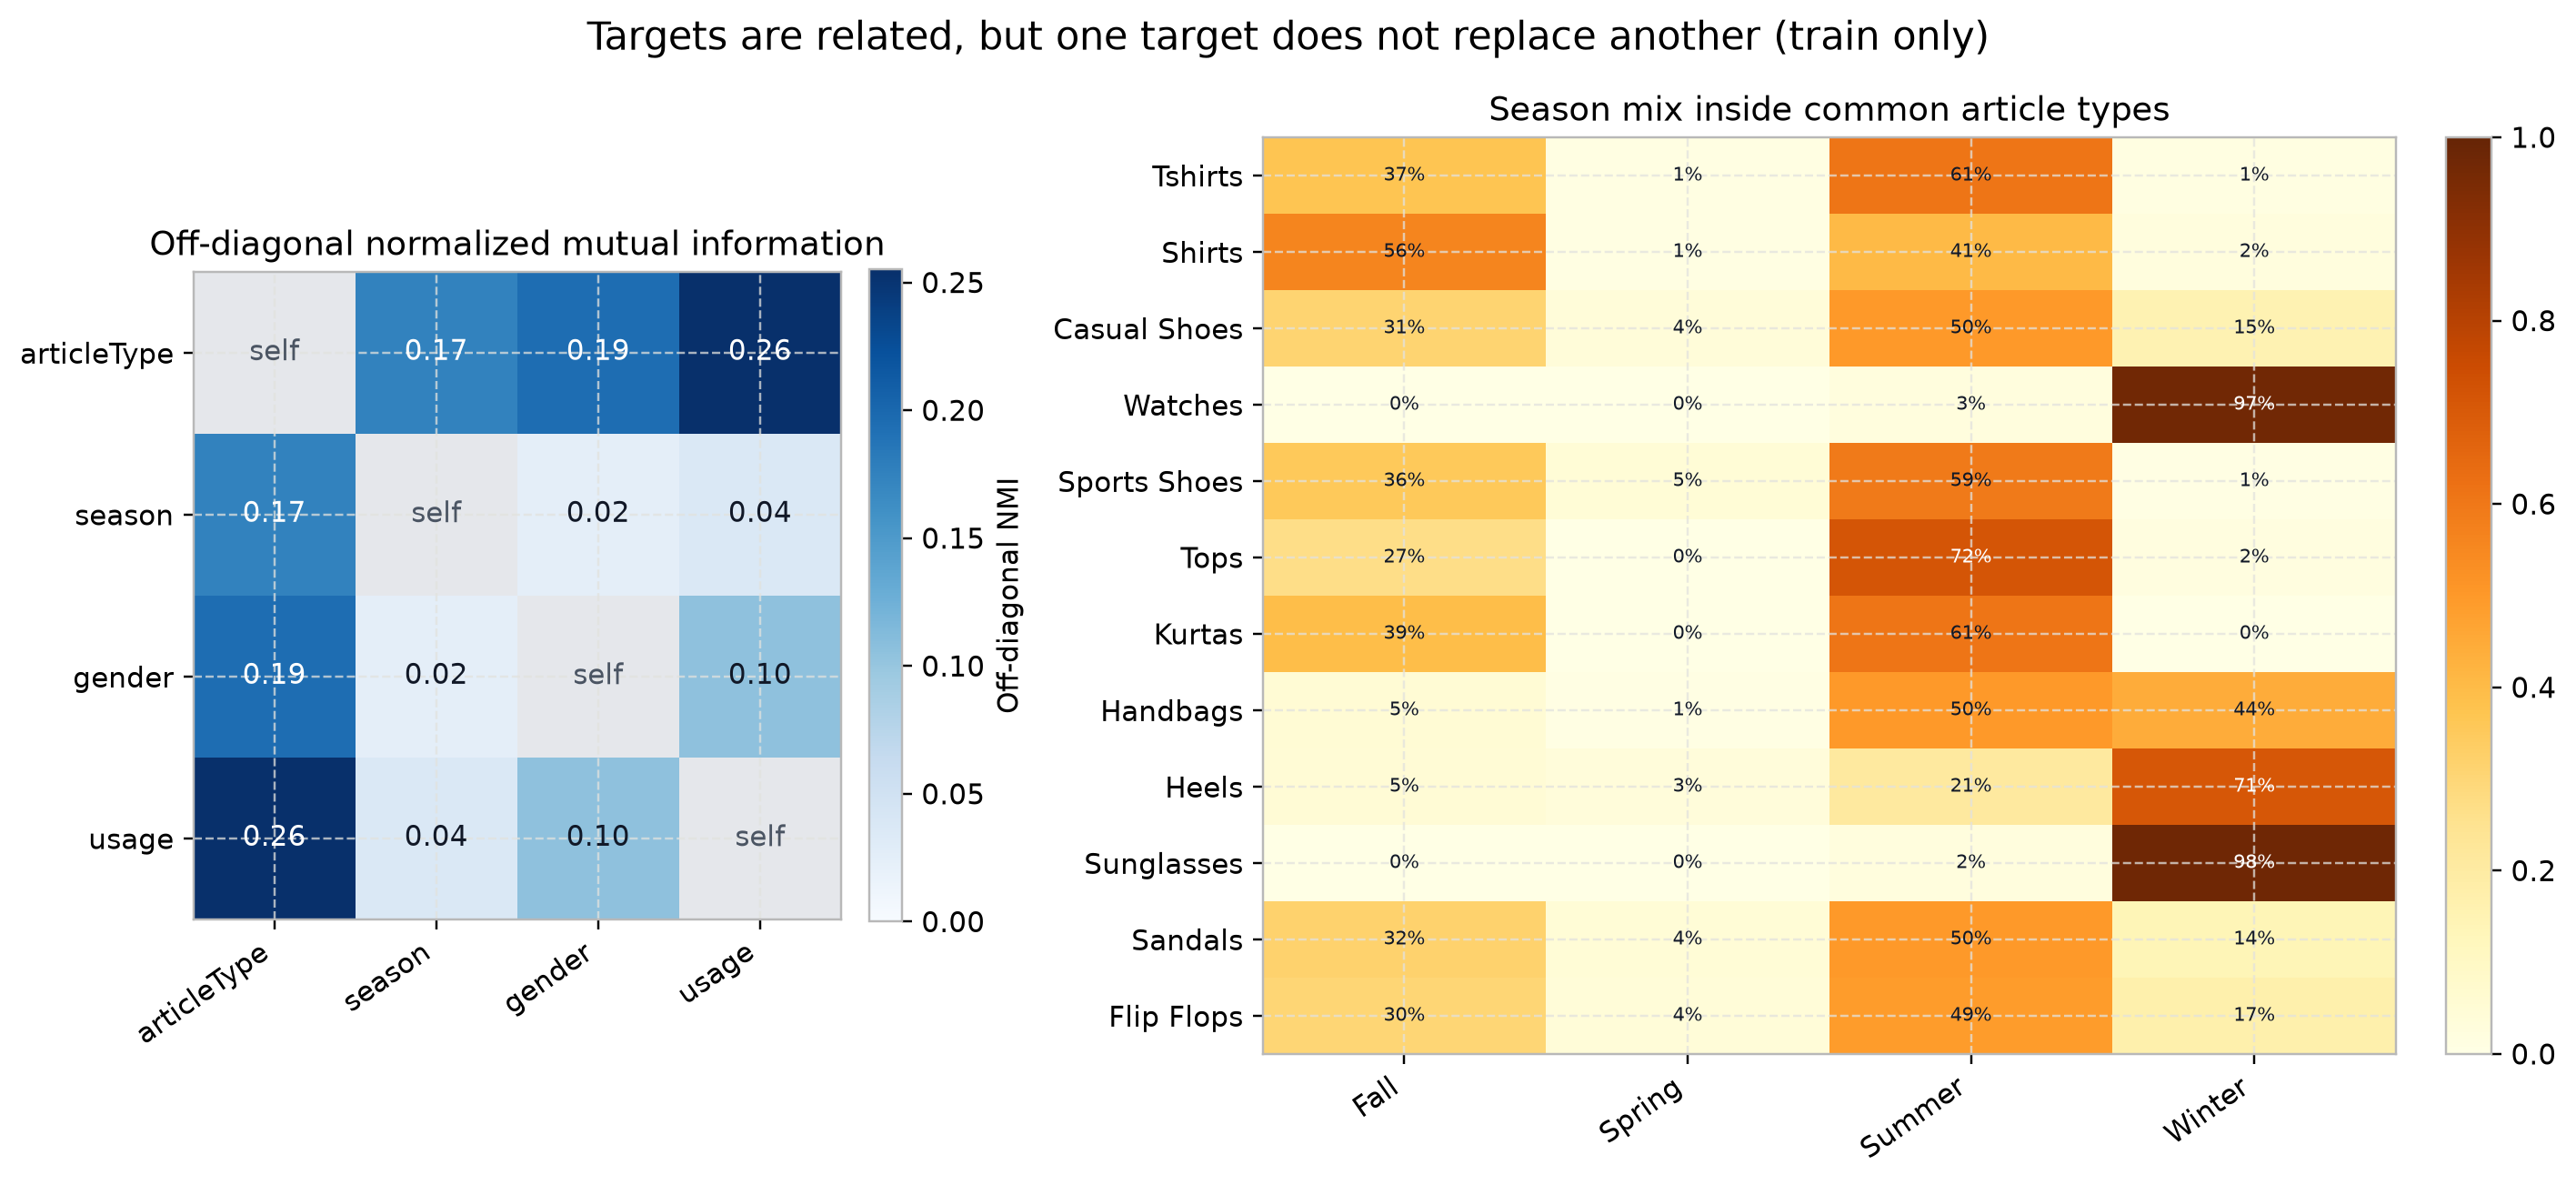


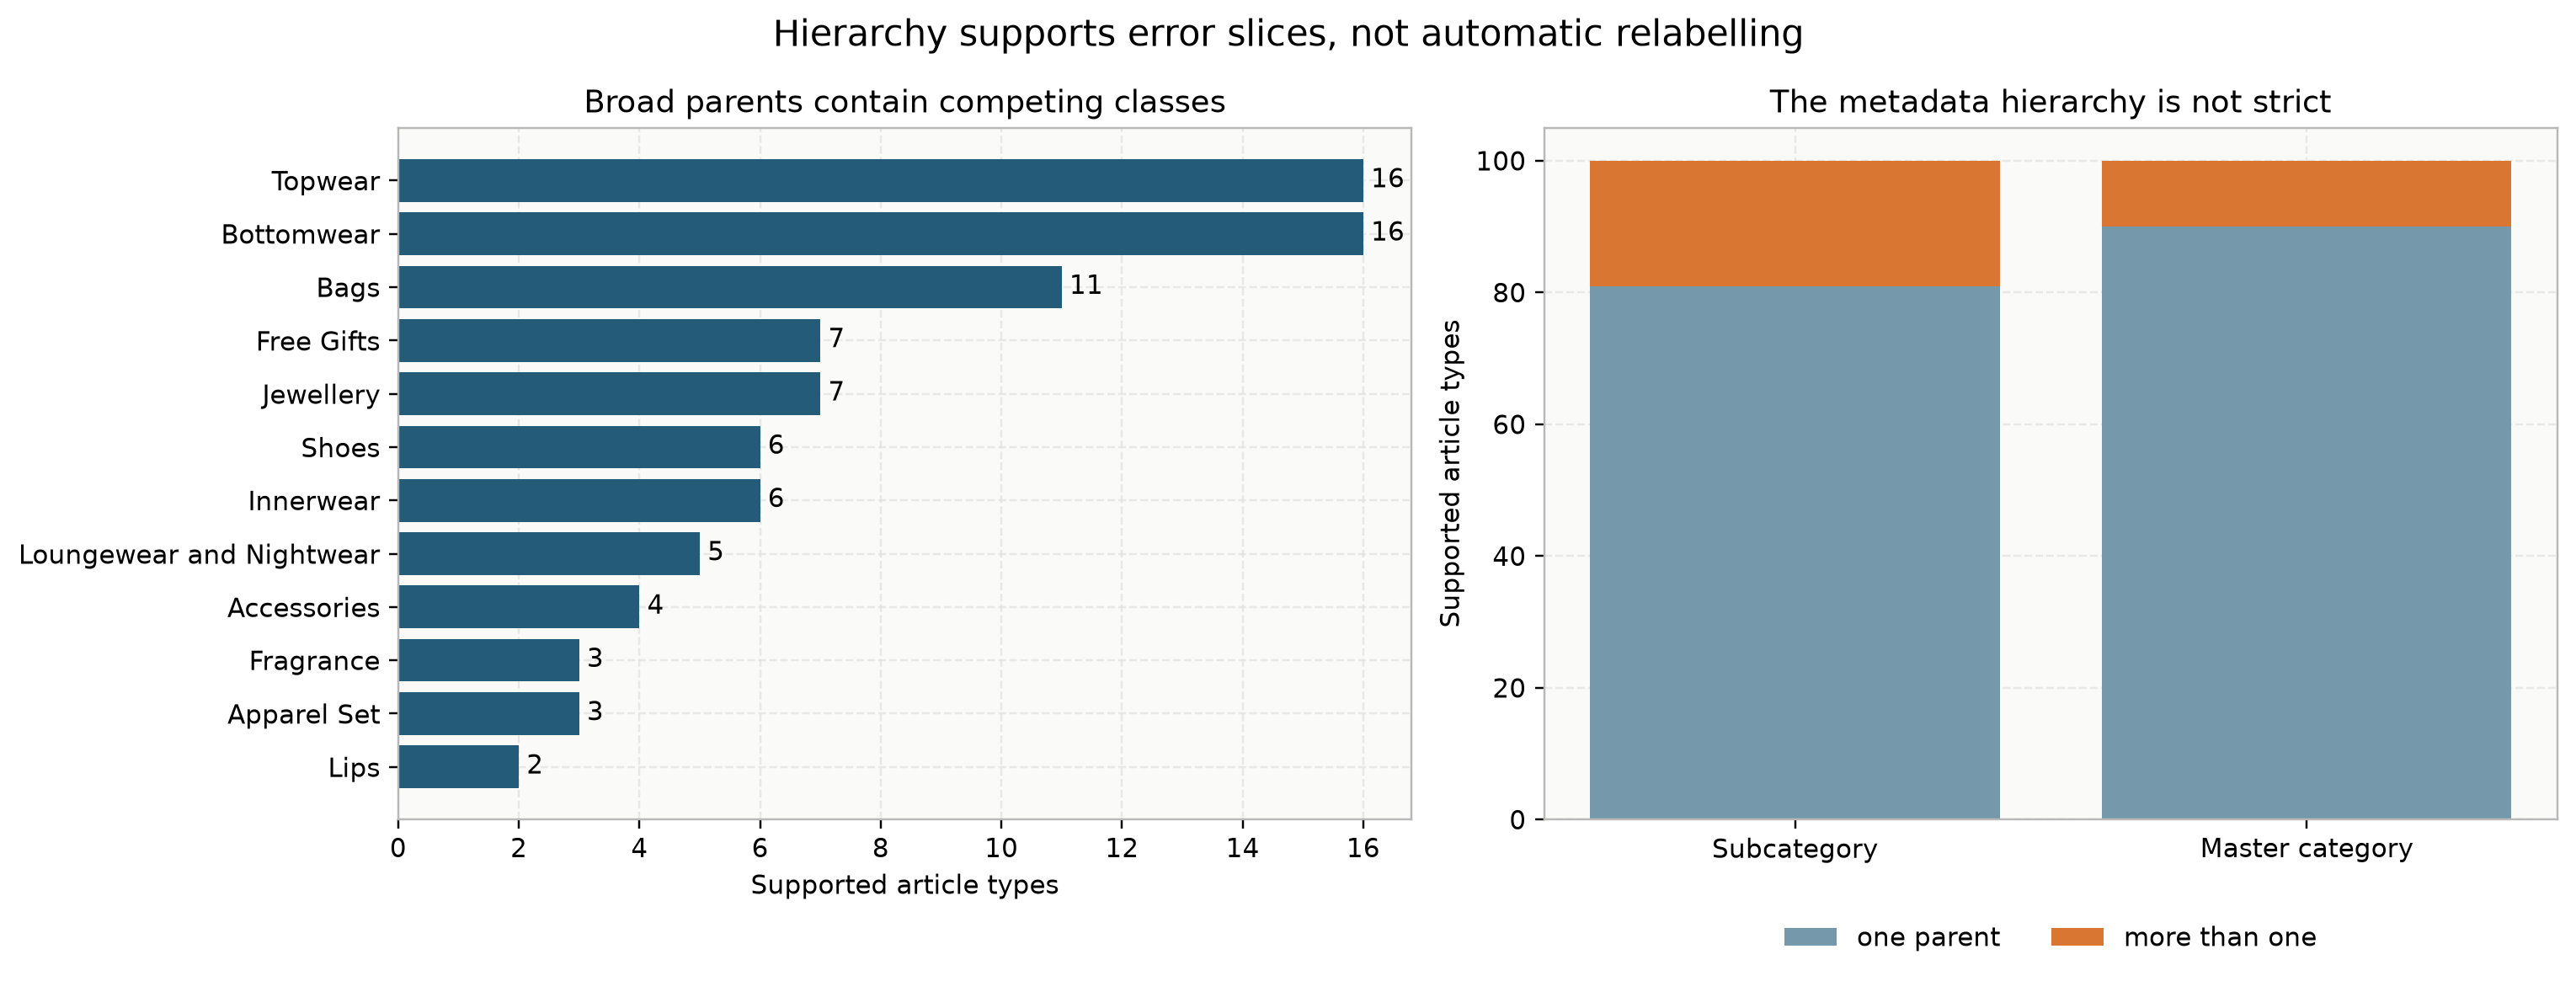


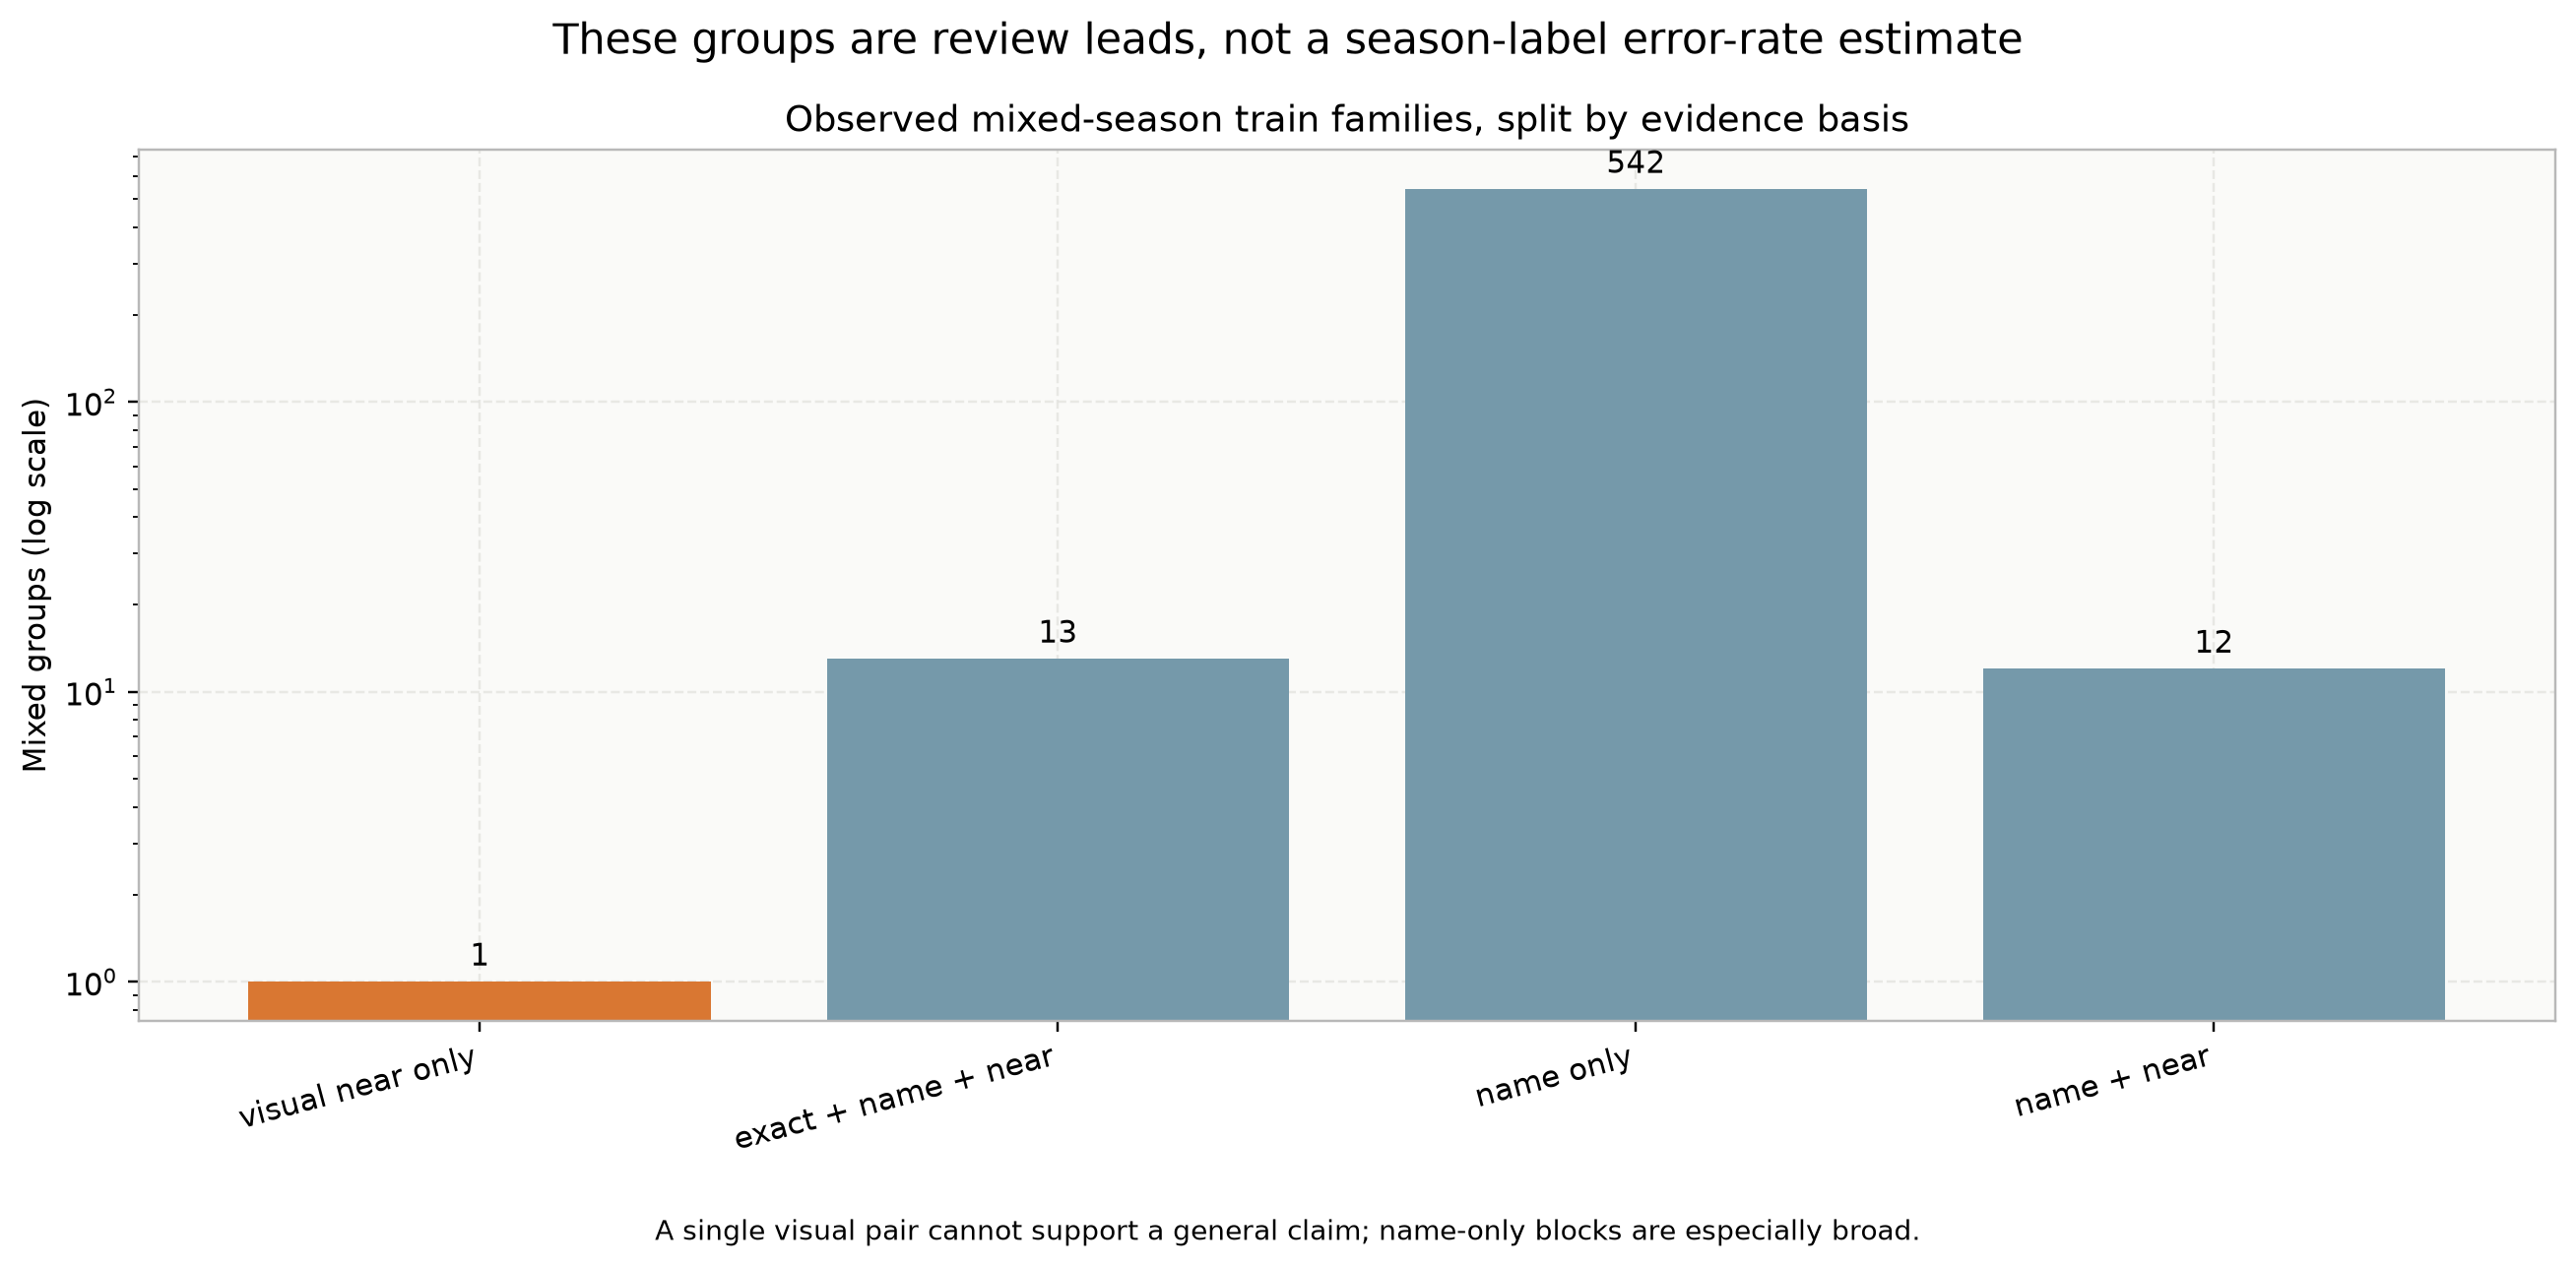


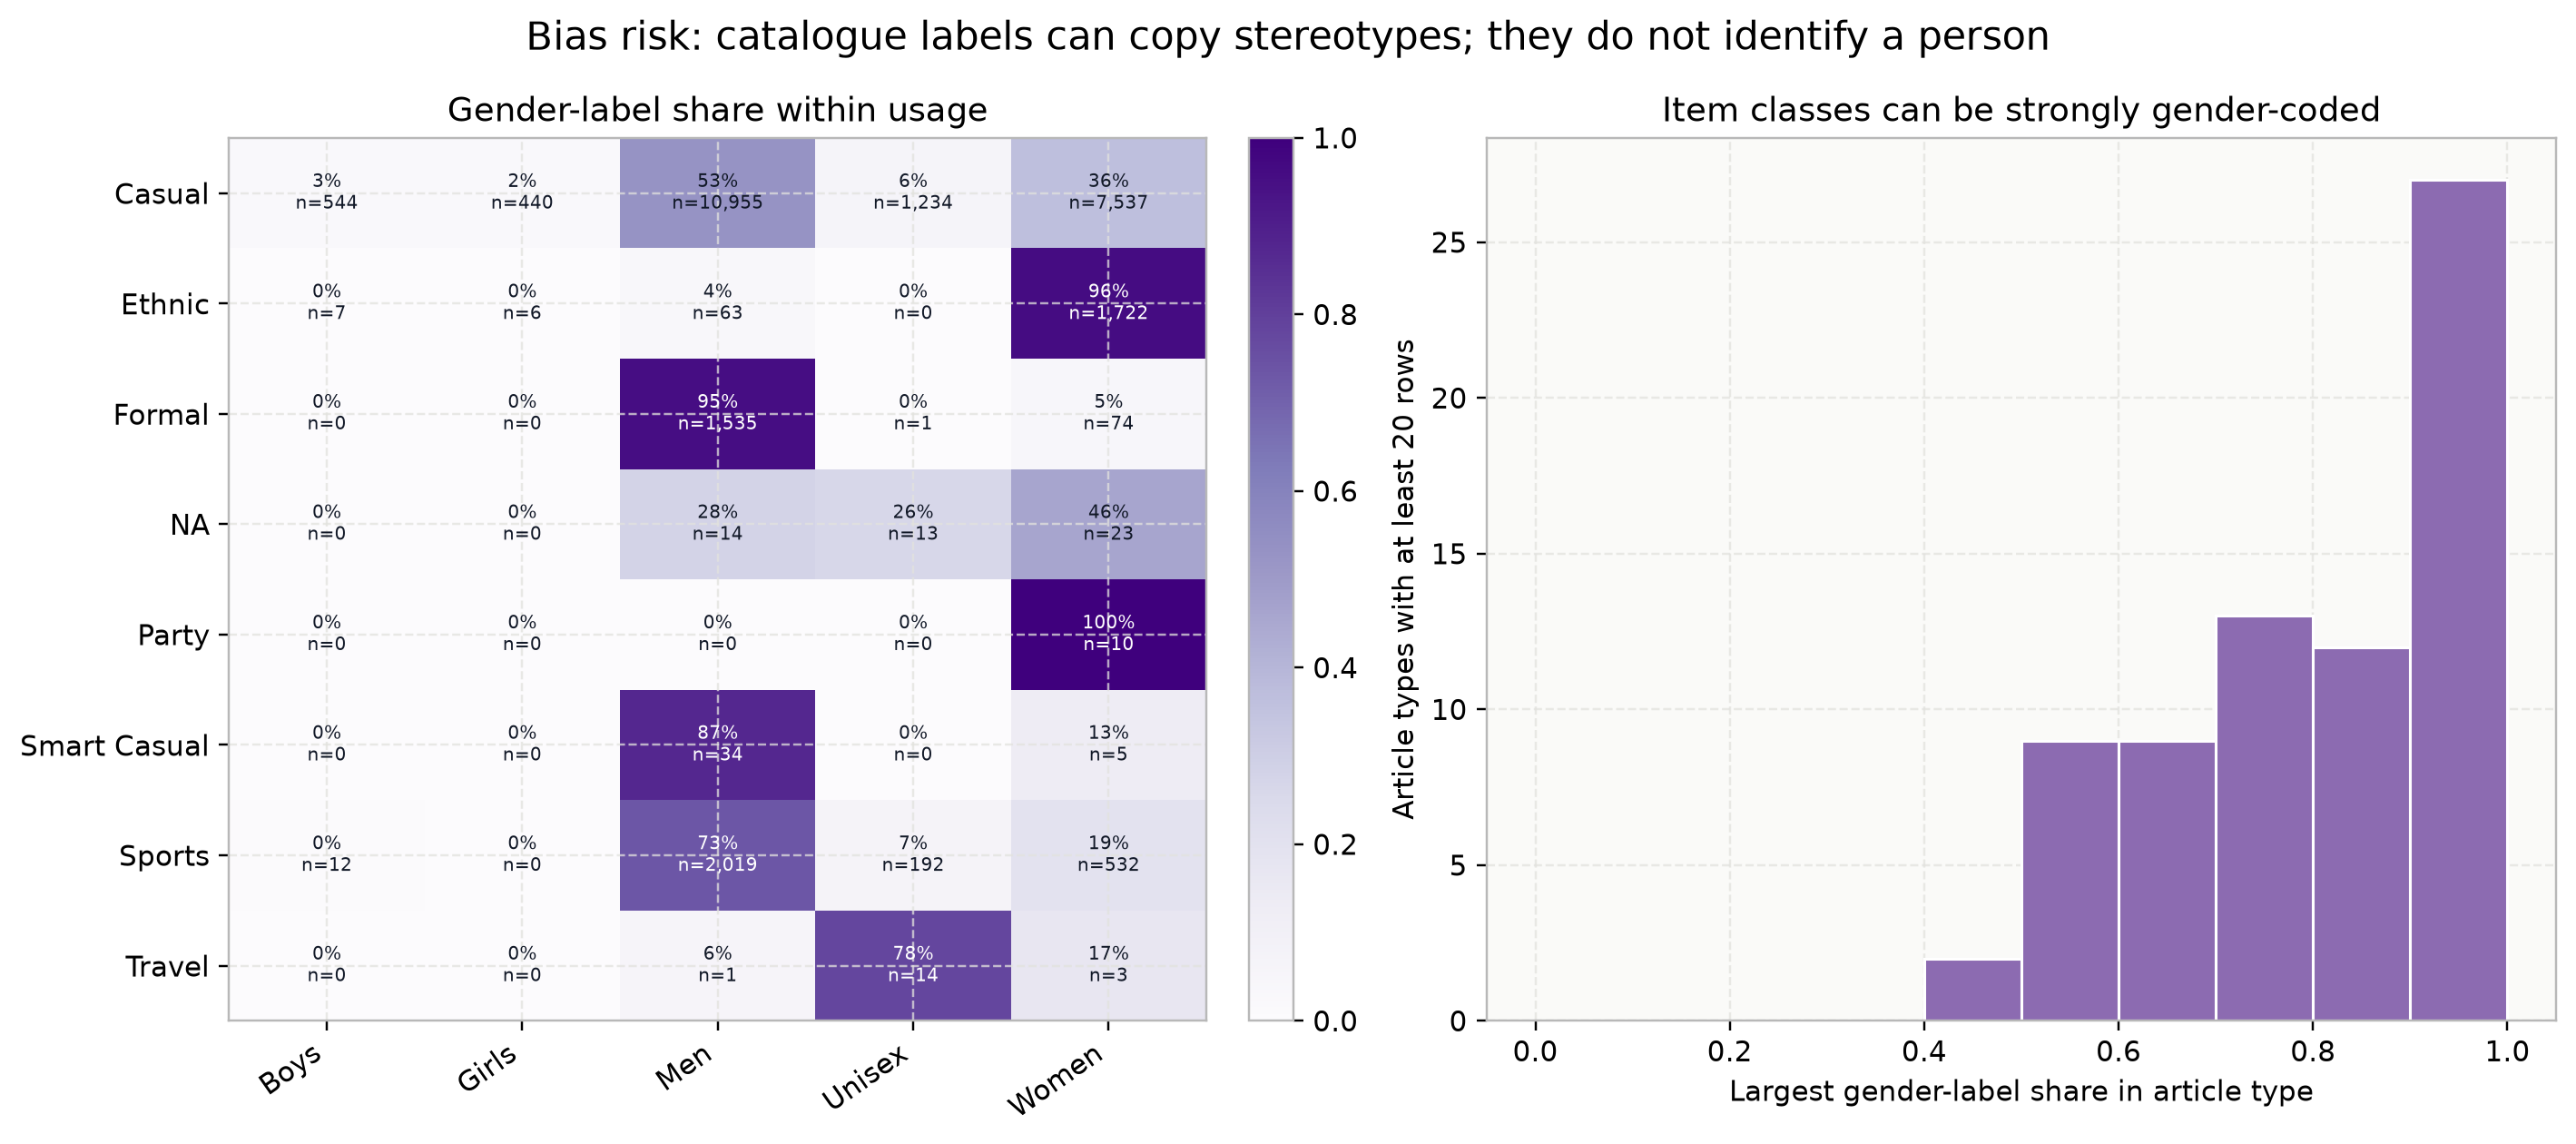

In [20]:
nmi = pd.DataFrame(np.eye(len(TARGET_COLUMNS)), index=TARGET_COLUMNS, columns=TARGET_COLUMNS)
for first_index, first in enumerate(TARGET_COLUMNS):
    for second_index, second in enumerate(TARGET_COLUMNS):
        if second_index <= first_index:
            continue
        mask = bool_mask(train[f"has_{first}_supported_label"]) & bool_mask(
            train[f"has_{second}_supported_label"]
        )
        value = normalized_mutual_information(
            train.loc[mask, f"{first}_supported"],
            train.loc[mask, f"{second}_supported"],
        )
        nmi.iloc[first_index, second_index] = value
        nmi.iloc[second_index, first_index] = value

hierarchy = hierarchy_summary(train)
season_families = season_family_summary(train)
save_csv(nmi.reset_index(names="target"), "joint_target_nmi.csv")
save_csv(hierarchy, "hierarchy_summary.csv")
save_csv(season_families, "season_family_basis_summary.csv")

joint_figure = plot_joint_relationships(train, nmi)
hierarchy_figure = plot_hierarchy(train, hierarchy)
season_figure = plot_season_ambiguity(season_families)
bias_figure, bias_summary = plot_bias(train)
save_csv(bias_summary, "bias_summary.csv")

association_pairs = [
    (first, second, float(nmi.loc[first, second]))
    for first_index, first in enumerate(TARGET_COLUMNS)
    for second in TARGET_COLUMNS[first_index + 1 :]
]
strongest_first, strongest_second, strongest_nmi = max(
    association_pairs, key=lambda record: record[2]
)
visual_family_rows = season_families[
    season_families["eligible_as_label_ambiguity_signal"].astype(bool)
]
risk_to_action = pd.DataFrame(
    [
        {
            "risk": "targets can share shortcuts",
            "evidence": (
                f"strongest NMI is {strongest_nmi:.3f}: {strongest_first} vs {strongest_second}"
            ),
            "modelling_action": "compare separate and shared representations; score each target",
        },
        {
            "risk": "season is not always visually stable",
            "evidence": (
                f"{int(visual_family_rows['mixed_season_train_groups'].sum())} mixed-season "
                f"visual families from {int(visual_family_rows['multirow_train_groups'].sum())}"
            ),
            "modelling_action": "show qualitative errors; do not relabel from image evidence alone",
        },
        {
            "risk": "gender can be a catalogue shortcut",
            "evidence": (
                f"{int(bias_summary.iloc[0]['article_types_at_or_above_90_percent'])} of "
                f"{int(bias_summary.iloc[0]['article_types_with_at_least_20_rows'])} common "
                "article types are at least 90% one gender label"
            ),
            "modelling_action": "report gender and usage slices; never treat gender as identity",
        },
    ]
)
show_table(risk_to_action, "Observed risk, evidence, and required modelling response")
show_figure(
    joint_figure,
    (
        "Figure 6. Training-only normalized mutual information and season mixtures show "
        "related but distinct prediction targets."
    ),
)
show_figure(
    hierarchy_figure,
    (
        "Figure 7. Catalogue parents contain multiple article types and some article types "
        "cross parents, so hierarchy is an error slice rather than an automatic merge."
    ),
)
show_figure(
    season_figure,
    (
        "Figure 8. Mixed-season training families are separated by evidence basis. "
        "These counts are review leads only; one visual pair cannot support a general "
        "error-rate claim."
    ),
)
show_figure(
    bias_figure,
    (
        "Figure 9. Training-only usage and gender-label associations reveal shortcut and "
        "stereotype risk that later evaluation must report."
    ),
)

> **Finding.** The strongest target link is moderate: `articleType` versus `usage` has NMI 0.255.
> Season is weakly linked to the other targets, consistent with its limited visual signal. Catalogue
> hierarchy is not one-to-one, so parent labels cannot safely merge article types. Only one of 30
> multi-row families based purely on accepted visual similarity mixes seasons; larger mixed counts
> from normalized names are triage leads rather than proof of bad labels. Shortcut risk remains
> material: 27 of 72 common article types are at least 90% one gender label. Figures 6–9 show these
> relationships and risks.
>
> **Modelling consequence.** The system keeps four explicit outputs. Separate models and a shared
> representation are compared under the same budget. Evaluation includes target-specific errors,
> hierarchy slices, season examples, and gender/usage shortcut slices. Gender remains a catalogue
> label and is not interpreted as a person's identity.

## 6. Image data quality and preprocessing

Image analysis covers objective file quality, source geometry, paired-resolution coverage, alignment
risk, and the cost of the proposed tensor representation. These checks define preprocessing without
claiming an unmeasured model gain.

### 6.1 Image quality and resolution variants

The source-image profile identifies safe decoding repairs and verifies that the high-resolution
collection represents the same model products without admitting official prediction IDs.

**Code step — Image profile and quality plots.**

Defines the source-image profile and objective quality-exception figures. These plots describe file properties rather than labels.

In [21]:
# Image profile, quality, and low/high alignment evidence


def plot_image_profile(train_images: pd.DataFrame) -> Path:
    resolutions = train_images.groupby(["width", "height"]).size().sort_values()
    resolution_labels = [f"{int(w)}x{int(h)}" for w, h in resolutions.index]
    modes = train_images["mode"].value_counts()
    file_sizes = train_images["file_size_bytes"] / 1024
    aspect = train_images["aspect_ratio"].value_counts().sort_index()
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    bars = axes[0, 0].barh(resolution_labels, resolutions.values, color=PALETTE[0])
    if len(resolutions) > 1 or (len(resolutions) and resolutions.iloc[0] > 20):
        axes[0, 0].set_xscale("log")
    axes[0, 0].set_title("Native resolutions")
    axes[0, 0].set_xlabel("Training images")
    axes[0, 0].bar_label(bars, labels=[f"{value:,}" for value in resolutions.values], padding=3)
    axes[0, 1].hist(file_sizes, bins=min(40, max(5, len(file_sizes))), color=PALETTE[0])
    axes[0, 1].axvline(file_sizes.median(), color=PALETTE[1], linestyle="--", label="median")
    axes[0, 1].set_title("Source file sizes")
    axes[0, 1].set_xlabel("KiB")
    axes[0, 1].set_ylabel("Training images")
    axes[0, 1].legend(frameon=False)
    mode_bars = axes[1, 0].bar(modes.index.astype(str), modes.values, color=PALETTE[: len(modes)])
    axes[1, 0].set_title("Source colour modes")
    axes[1, 0].set_ylabel("Training images")
    axes[1, 0].bar_label(mode_bars, labels=[f"{value:,}" for value in modes.values], padding=3)
    aspect_labels = [f"{float(value):.3f}" for value in aspect.index]
    aspect_bars = axes[1, 1].bar(aspect_labels, aspect.values, color=PALETTE[0])
    axes[1, 1].set_title("Native aspect ratios")
    axes[1, 1].set_xlabel("Width / height")
    axes[1, 1].set_ylabel("Training images")
    axes[1, 1].bar_label(aspect_bars, labels=[f"{value:,}" for value in aspect.values], padding=3)
    fig.suptitle(f"Objective image profile (training only, n={len(train_images):,})")
    fig.tight_layout()
    return save_figure(fig, "image_profile.png")


def plot_data_quality(
    train_frame: pd.DataFrame, train_images: pd.DataFrame, issues: pd.DataFrame
) -> Path:
    representatives = (
        train_frame[bool_mask(train_frame["has_articleType_deployed_label"])]
        .sort_values("id")
        .groupby("articleType_deployed", sort=False)
        .head(1)
        .head(4)
    )
    fig, axes = plt.subplots(2, 4, figsize=(13, 7.6))
    flat = list(axes.flat)
    for axis in flat:
        axis.axis("off")
    for axis, row in zip(flat[:4], representatives.itertuples(index=False)):
        axis.axis("on")
        show_image(
            axis, open_rgb(row.path), f"Train example\n{row.articleType_deployed} · ID {row.id}"
        )

    selected = []
    non_rgb = train_images[train_images["mode"].ne("RGB")].sort_values("id")
    odd_size = train_images[~(train_images["width"].eq(60) & train_images["height"].eq(80))].copy()
    odd_size["aspect_distance"] = (odd_size["aspect_ratio"] - 0.75).abs()
    odd_size.sort_values(["aspect_distance", "id"], ascending=[False, True], inplace=True)
    for candidates in (non_rgb, odd_size):
        for row in candidates.itertuples(index=False):
            if int(row.id) not in {int(item.id) for item in selected}:
                selected.append(row)
                break
    exceptions = train_images[
        train_images["mode"].ne("RGB")
        | ~(train_images["width"].eq(60) & train_images["height"].eq(80))
    ].sort_values("id")
    for row in exceptions.itertuples(index=False):
        if len(selected) >= 3:
            break
        if int(row.id) not in {int(item.id) for item in selected}:
            selected.append(row)

    for axis, row in zip(flat[4:7], selected):
        axis.axis("on")
        odd = not (int(row.width) == 60 and int(row.height) == 80)
        note = "odd size/aspect → letterbox" if odd else "non-RGB → RGB conversion"
        show_image(
            axis,
            open_rgb(row.path),
            f"{row.mode} · {int(row.width)}x{int(row.height)}\nID {int(row.id)} · {note}",
        )
    if len(selected) < 3:
        flat[4 + len(selected)].text(
            0.5, 0.5, "No more image exceptions\nin this fixture", ha="center", va="center"
        )
    flat[7].text(
        0.5,
        0.56,
        (
            f"Missing image rows: {int(issues['issue_code'].eq('missing_image').sum()):,}\n"
            f"Corrupt image rows: {int(issues['issue_code'].eq('corrupt_image').sum()):,}\n"
            "They are excluded before the split."
        ),
        ha="center",
        va="center",
        fontsize=11,
    )
    fig.suptitle("Training image evidence changes cleaning, colour conversion, and masking")
    fig.tight_layout()
    return save_figure(fig, "data_quality_examples.png")

**Code step — Resolution-alignment plot.**

Defines the low-resolution and high-resolution pairing figure across the observed hash-distance range.

In [22]:
def plot_variant_alignment(variants: pd.DataFrame, pairs: pd.DataFrame) -> Path:
    paths = variants.pivot(index="id", columns="variant", values="path").dropna()
    comparable = pairs[pairs["id"].astype(int).isin(paths.index.astype(int))].copy()
    comparable["max_hash_distance"] = comparable[["dhash_distance", "ahash_distance"]].max(axis=1)
    comparable.sort_values(["max_hash_distance", "id"], inplace=True)
    positions = np.linspace(0, max(len(comparable) - 1, 0), min(4, len(comparable)))
    sample = comparable.iloc[sorted(set(np.rint(positions).astype(int)))].copy()
    fig, axes = plt.subplots(2, 4, figsize=(13, 7.2), squeeze=False)
    for axis in axes.flat:
        axis.axis("off")
    for column, row in enumerate(sample.itertuples(index=False)):
        item_id = int(row.id)
        low = open_rgb(paths.loc[item_id, "original"])
        high = open_rgb(paths.loc[item_id, "high_resolution"])
        show_image(axes[0, column], low, f"ID {item_id} · original\n{low.width}x{low.height}")
        show_image(
            axes[1, column],
            high,
            f"same ID · high resolution\ndHash {row.dhash_distance} · aHash {row.ahash_distance}",
        )
    if sample.empty:
        axes[0, 0].text(0.5, 0.5, "No comparable pairs in this fixture", ha="center")
    fig.suptitle("Label-free low/high same-ID checks across the hash-distance range")
    fig.text(
        0.5,
        0.015,
        (
            "Perceptual agreement is strong evidence, not proof of product identity; "
            "human sign-off is pending."
        ),
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.96))
    return save_figure(fig, "variant_alignment_examples.png")

**Code step — Image and variant validation.**

Builds the training-only image audit, verifies complete low and high resolution pairs, checks their total product weight, and records unresolved alignment flags.

In [23]:
decoded_training = image_audit[
    image_audit["role"].eq("train") & bool_mask(image_audit["decode_ok"])
].copy()
decoded_training["id"] = pd.to_numeric(decoded_training["id"], errors="coerce")
decoded_training = decoded_training[decoded_training["id"].notna()]
decoded_training["id"] = decoded_training["id"].astype(int)
for column in ("width", "height", "aspect_ratio", "file_size_bytes"):
    decoded_training[column] = pd.to_numeric(decoded_training[column], errors="raise")
train_images = decoded_training[decoded_training["id"].isin(set(train["id"]))].copy()
if set(train_images["id"]) != set(train["id"]):
    raise ValueError("Train-only image audit does not cover every training row")
if train_images["id"].duplicated().any():
    raise ValueError("Train-only image audit repeats an ID")

image_summary = pd.DataFrame(
    [
        {
            "source_partition": "train",
            "decoded_images": len(train_images),
            "native_60x80": int(
                (train_images["width"].eq(60) & train_images["height"].eq(80)).sum()
            ),
            "other_sizes": int(
                (~(train_images["width"].eq(60) & train_images["height"].eq(80))).sum()
            ),
            "non_rgb_sources": int(train_images["mode"].ne("RGB").sum()),
            "median_file_kib": float(train_images["file_size_bytes"].median() / 1024),
            "p95_file_kib": float(train_images["file_size_bytes"].quantile(0.95) / 1024),
            "ordered_inventory_sha256": dataframe_digest(
                train_images.sort_values("id"),
                ["id", "path", "width", "height", "mode", "sha256"],
            ),
        }
    ]
)
save_csv(image_summary, "image_summary.csv")

model_partitions = ("train", "val", "holdout")
eligible_ids = set(splits.loc[splits["partition"].isin(model_partitions), "id"].astype(int))
if set(variant_manifest["id"].astype(int)) != eligible_ids:
    raise ValueError("The image-variant manifest does not cover the exact modelling product set")
if set(TARGET_COLUMNS).intersection(variant_manifest.columns):
    raise ValueError("Target columns entered the structural image-variant manifest")
variant_pairs = variant_manifest.groupby("id")["variant"].agg(set)
if not variant_pairs.eq({"original", "high_resolution"}).all():
    raise ValueError("Every modelling product must have both image variants")
if not np.allclose(variant_manifest.groupby("id")["per_product_weight"].sum().to_numpy(), 1.0):
    raise ValueError("Image variants must sum to one product of evidence")
variant_evidence = pd.DataFrame(
    [
        {
            "partition": partition,
            "products": values["product_count"],
            "image_variants": values["variant_count"],
            "complete_pairs": values["complete_pair_count"],
            "incomplete_pairs": values["incomplete_pair_count"],
            "weight_per_pair": 1.0,
        }
        for partition, values in variant_proof["partition_coverage"].items()
    ]
).sort_values("partition", key=lambda values: values.map({"train": 0, "val": 1, "holdout": 2}))
save_csv(variant_evidence, "high_resolution_summary.csv")
if alignment_proof.get("pair_count") != len(alignment_pairs):
    raise ValueError("The low/high alignment summary is stale")
if alignment_proof.get("output_sha256") != compute_sha256(ALIGNMENT_PAIRS_PATH):
    raise ValueError("The low/high alignment table hash is stale")
alignment_evidence = pd.DataFrame(
    [
        {
            "same_id_pairs": int(alignment_proof["pair_count"]),
            "original_only": int(alignment_proof["original_only_count"]),
            "high_only": int(alignment_proof["high_resolution_only_count"]),
            "possible_mismatches": int(alignment_proof["possible_content_mismatch_count"]),
            "exception_distance": int(alignment_proof["exception_distance"]),
            "human_signoff": "pending",
        }
    ]
)
save_csv(alignment_evidence, "variant_alignment_summary.csv")
variant_record = {
    "policy": variant_proof["policy"],
    "manifest_path": "data/processed/training_image_variants.csv.gz",
    "manifest_sha256": compute_sha256(VARIANT_MANIFEST_PATH),
    "high_resolution_catalogue_path": "data/processed/high_resolution/image_catalogue.csv.gz",
    "high_resolution_catalogue_sha256": compute_sha256(HIGH_RES_CATALOGUE_PATH),
    "model_product_count": variant_proof["model_product_count"],
    "model_variant_count": variant_proof["model_variant_count"],
    "partition_coverage": variant_proof["partition_coverage"],
    "official_prediction_id_intersection": variant_proof["official_prediction_id_intersection"],
    "quarantine_id_intersection": variant_proof["quarantine_id_intersection"],
    "target_columns_in_variant_manifest": variant_proof["target_columns_in_variant_manifest"],
    "same_product_variants_are_independent_evidence": False,
    "paired_normalization_sha256": compute_sha256(PAIRED_NORMALIZATION_PATH),
    "alignment_summary_sha256": stable_artifact_digest(ALIGNMENT_SUMMARY_PATH),
    "alignment_pairs_sha256": compute_sha256(ALIGNMENT_PAIRS_PATH),
    "alignment": alignment_evidence.iloc[0].to_dict(),
}

**Code step — Image evidence results.**

Creates the image contract table and Figures 10 to 12 covering source quality, objective exceptions, and paired-resolution examples.

,evidence,scope,result,modelling_use
0,original training images,"26,992 decoded","26,982 are 60x80; 246 need RGB conversion","decode safely, convert to RGB, preserve aspect ratio"
1,low/high image pairs,"38,551 products","77,102 variant rows; zero incomplete pairs",weight each pair as one product; compare three variant policies
2,same-ID alignment screen,"44,441 pairs",84 possible mismatches; sign-off pending,keep exceptions visible; do not claim human proof



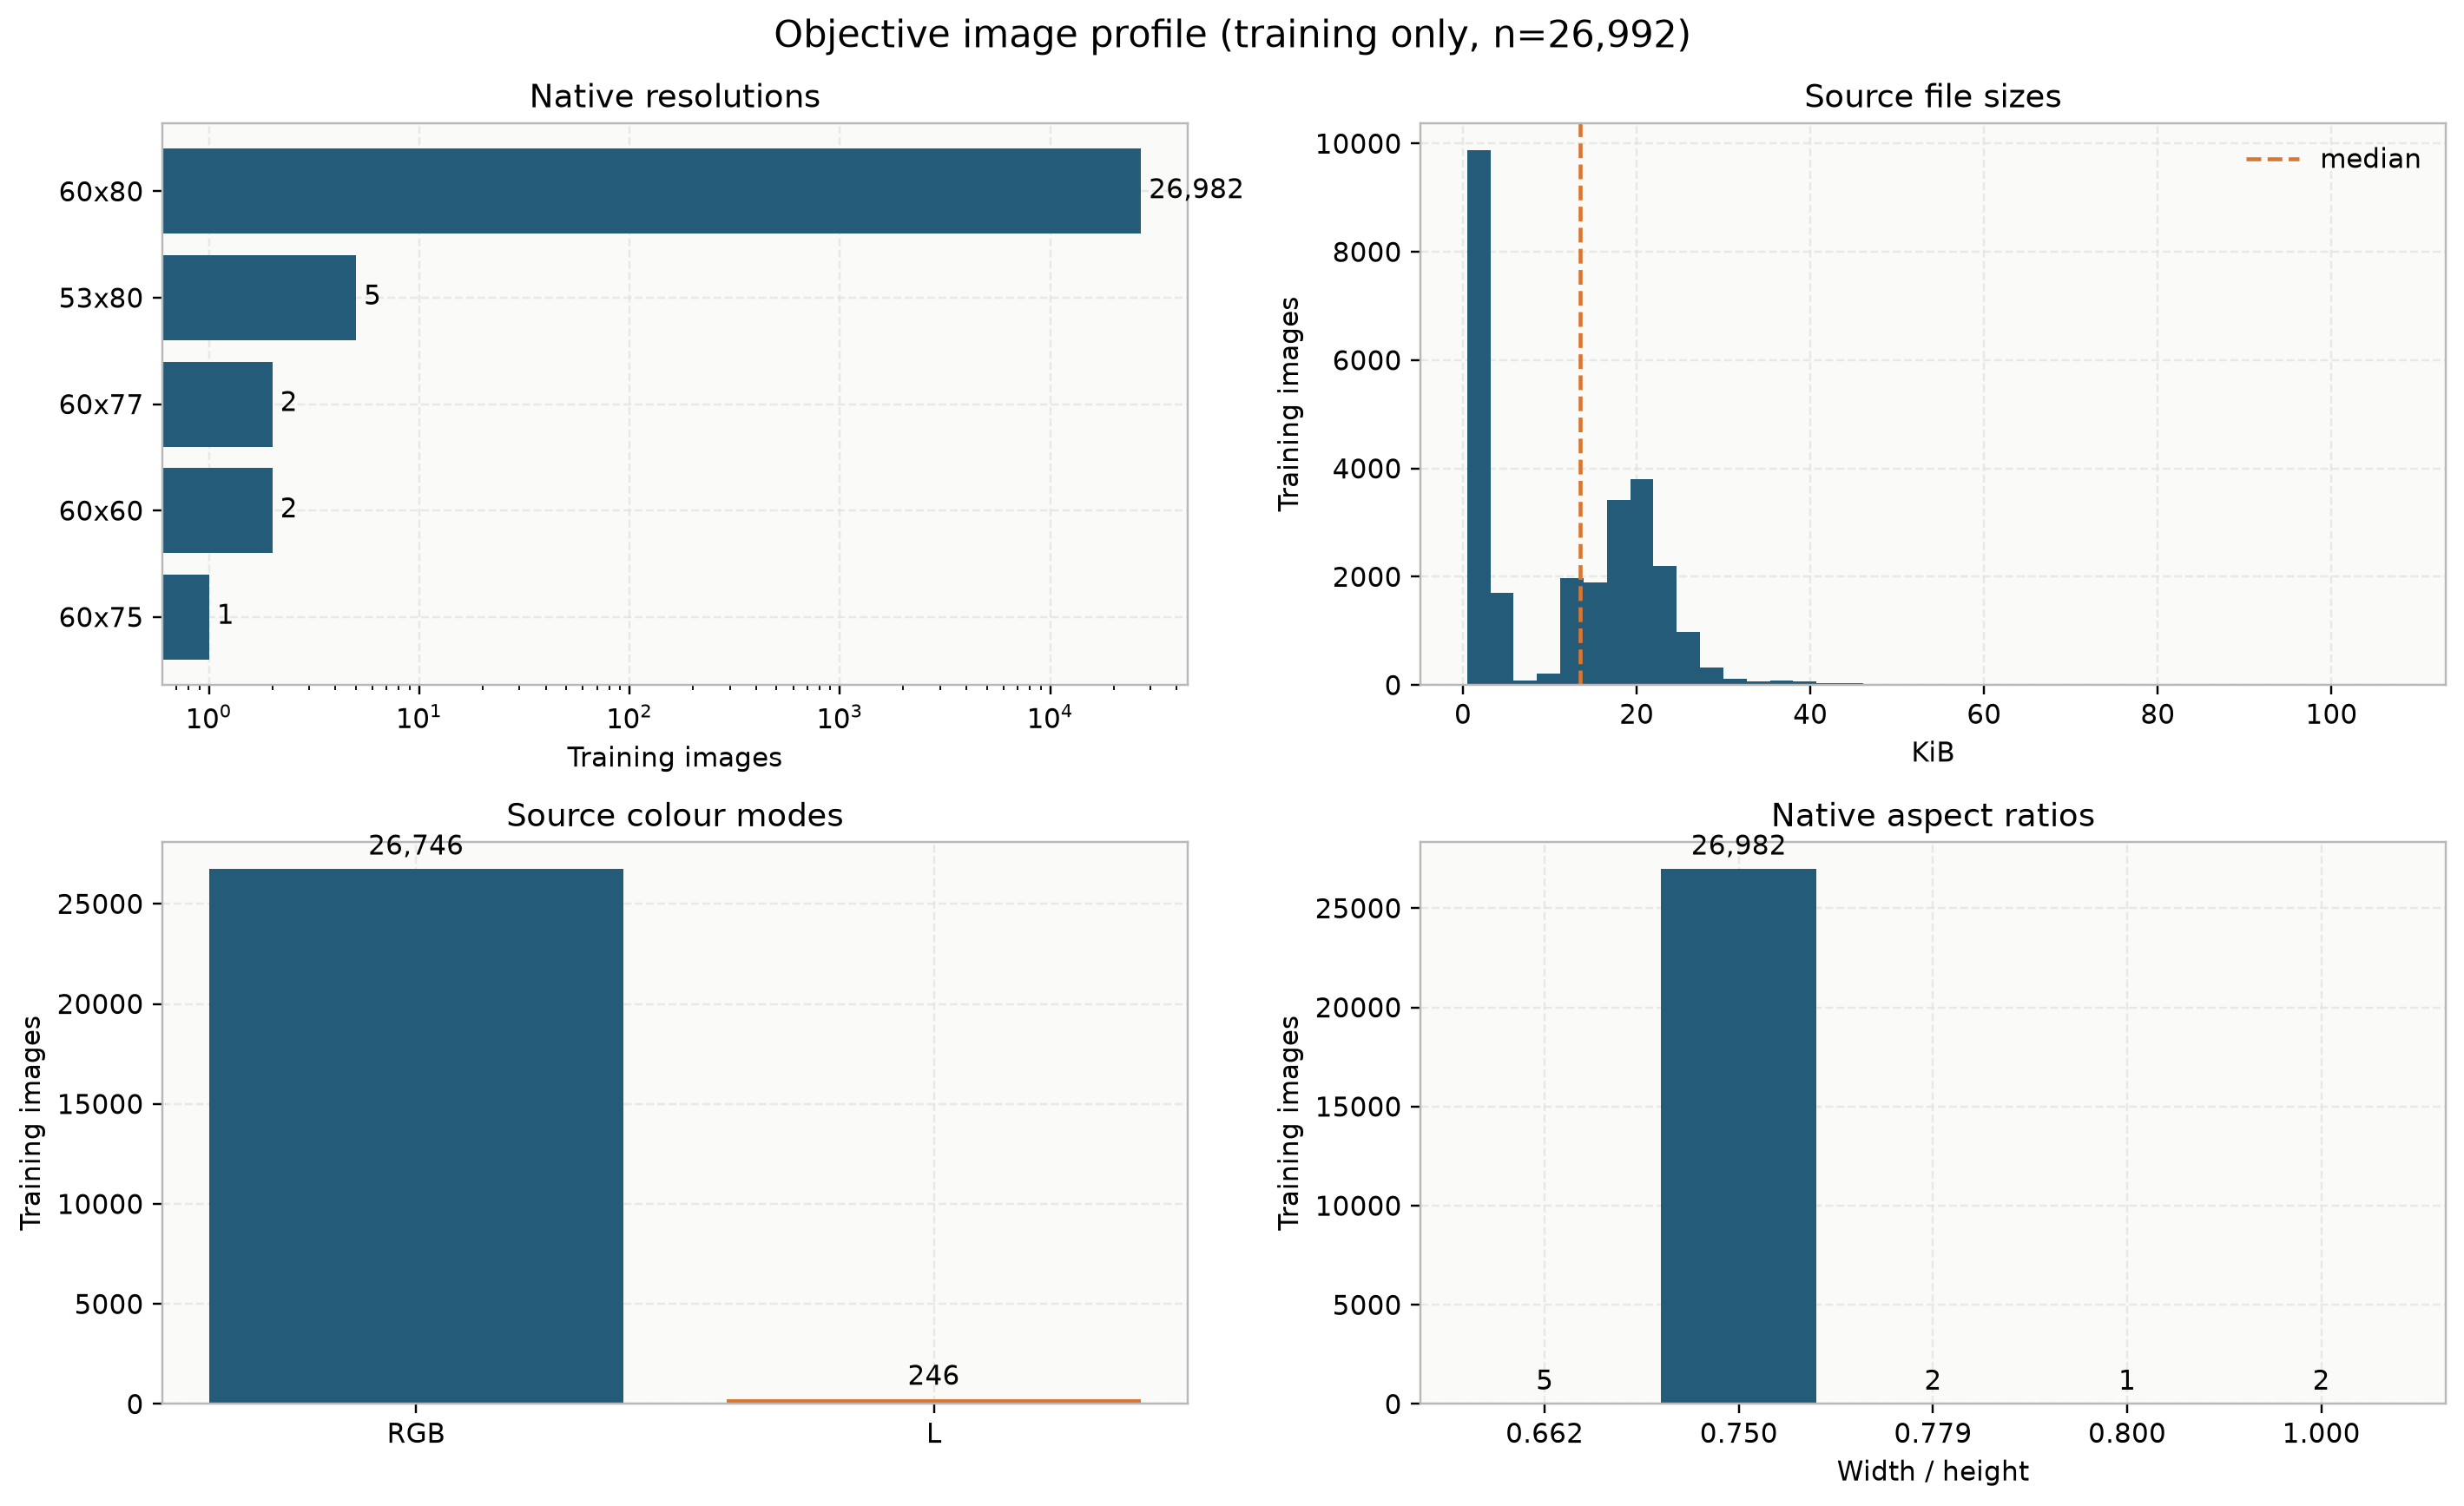


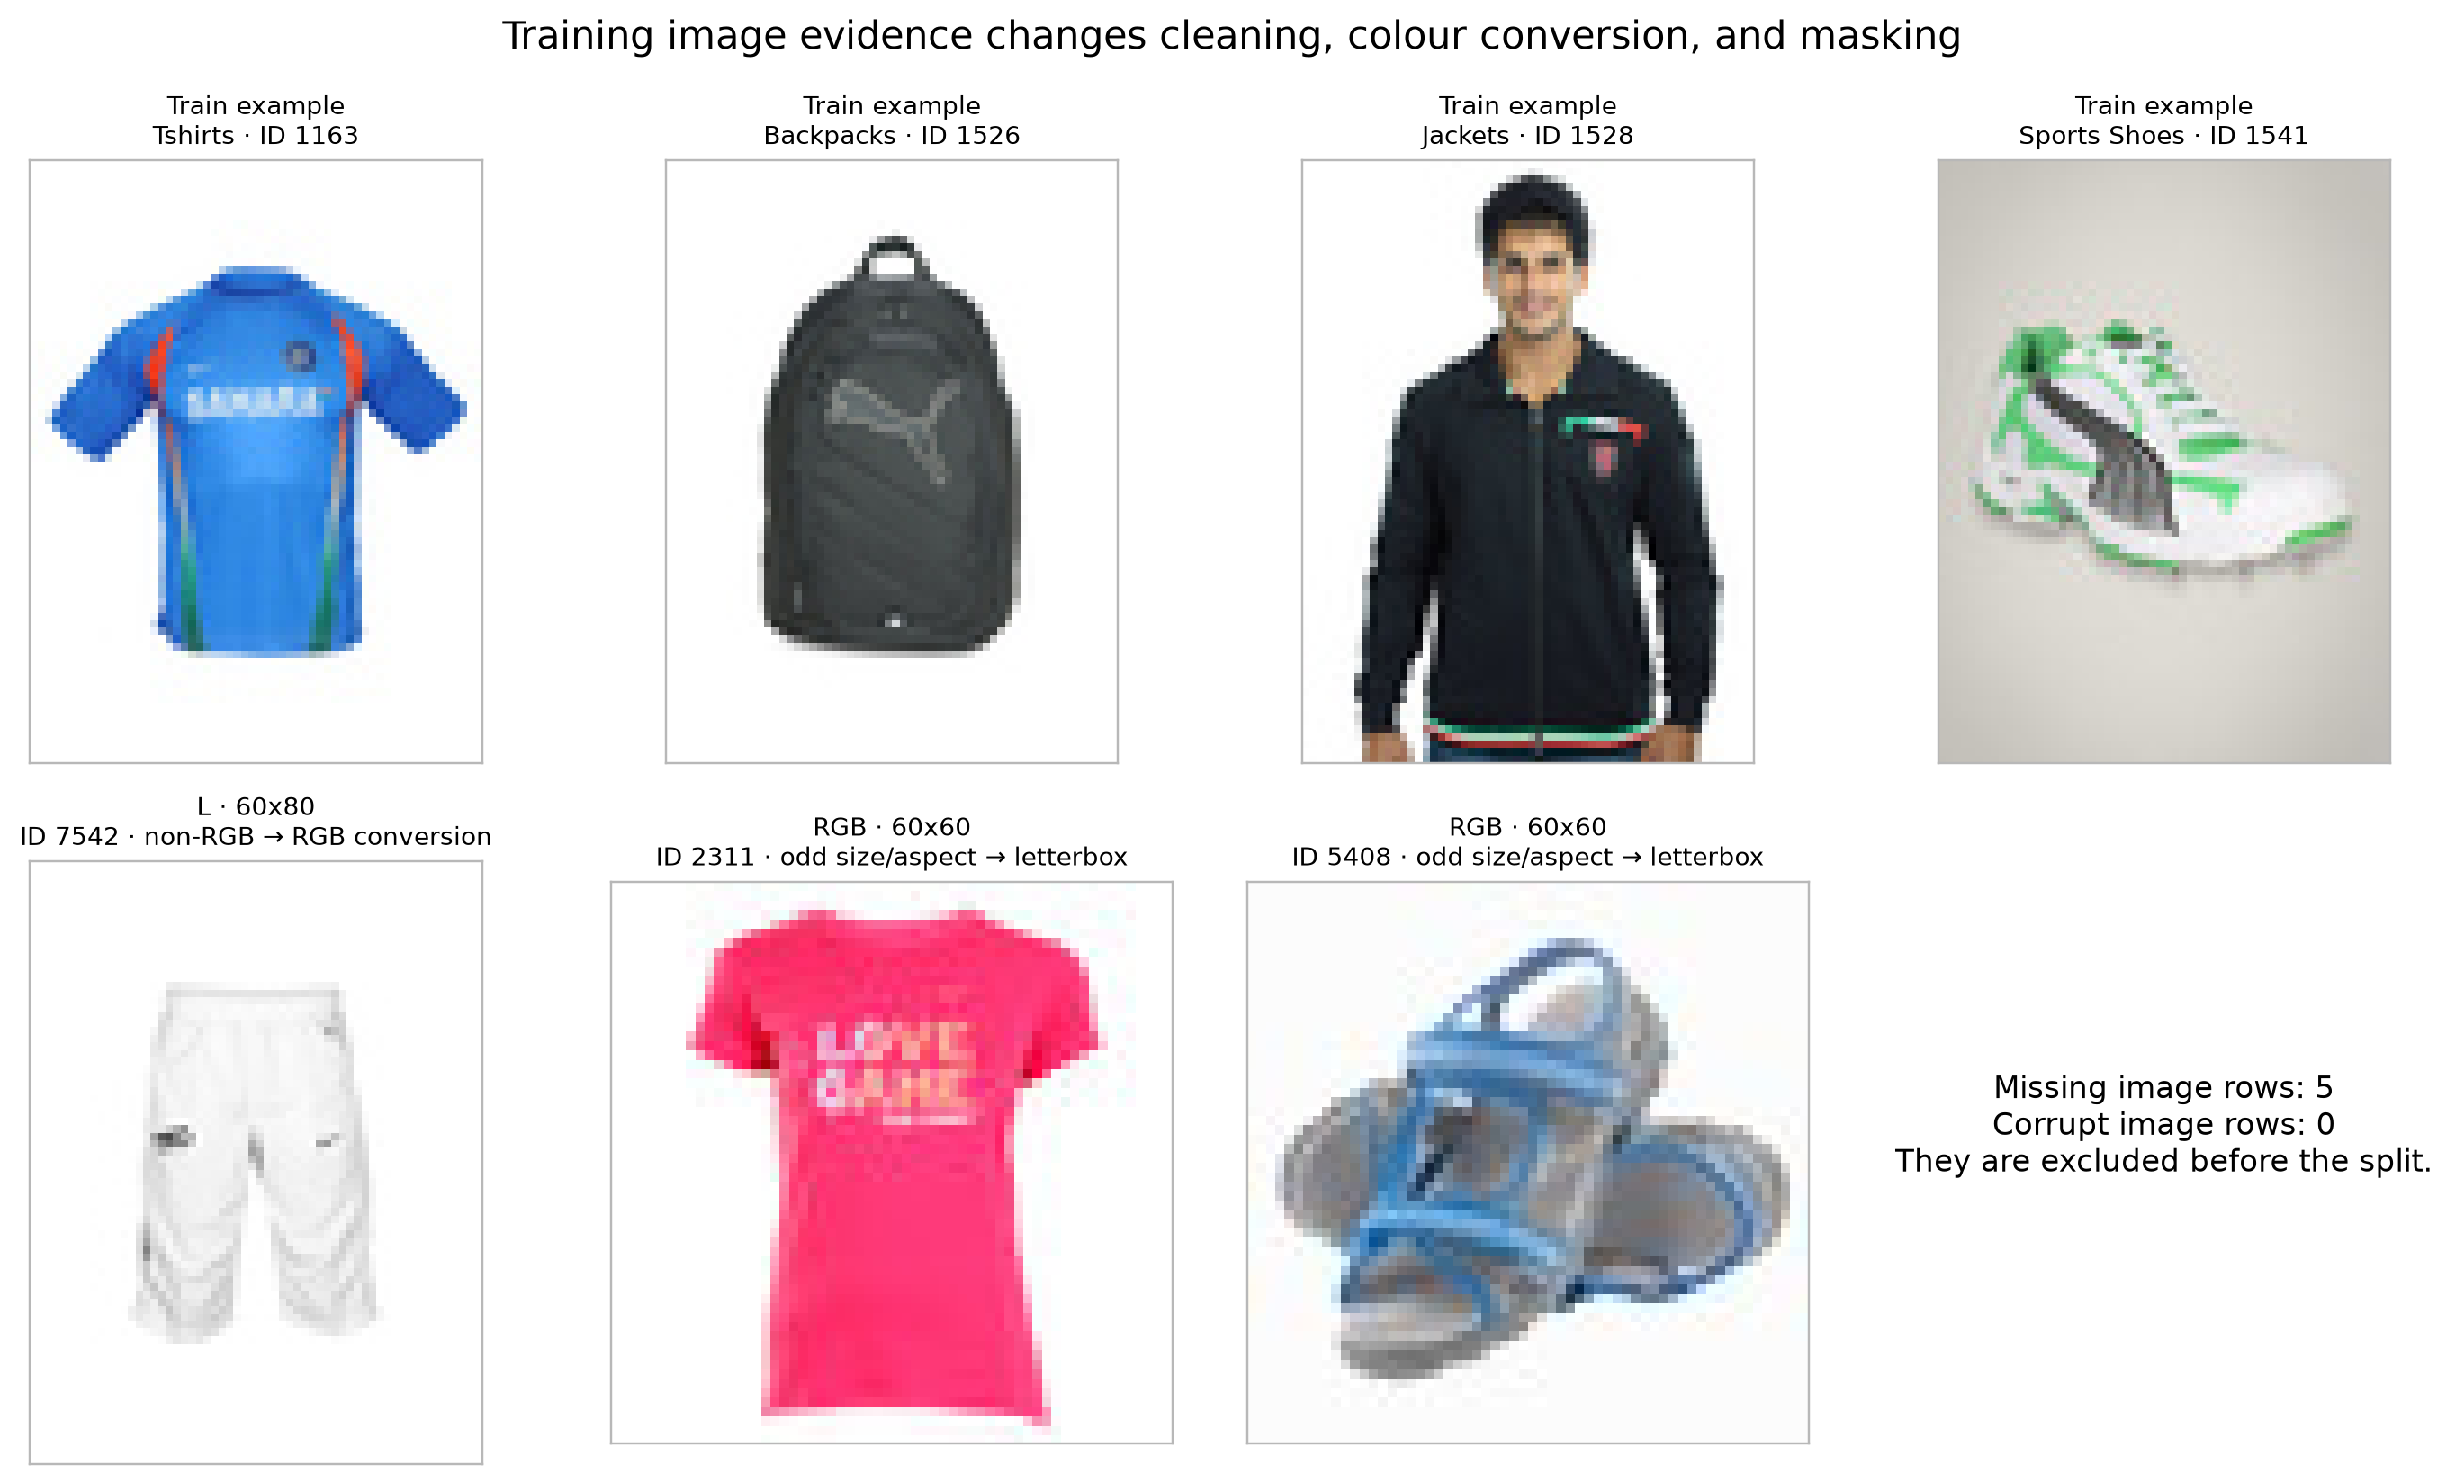


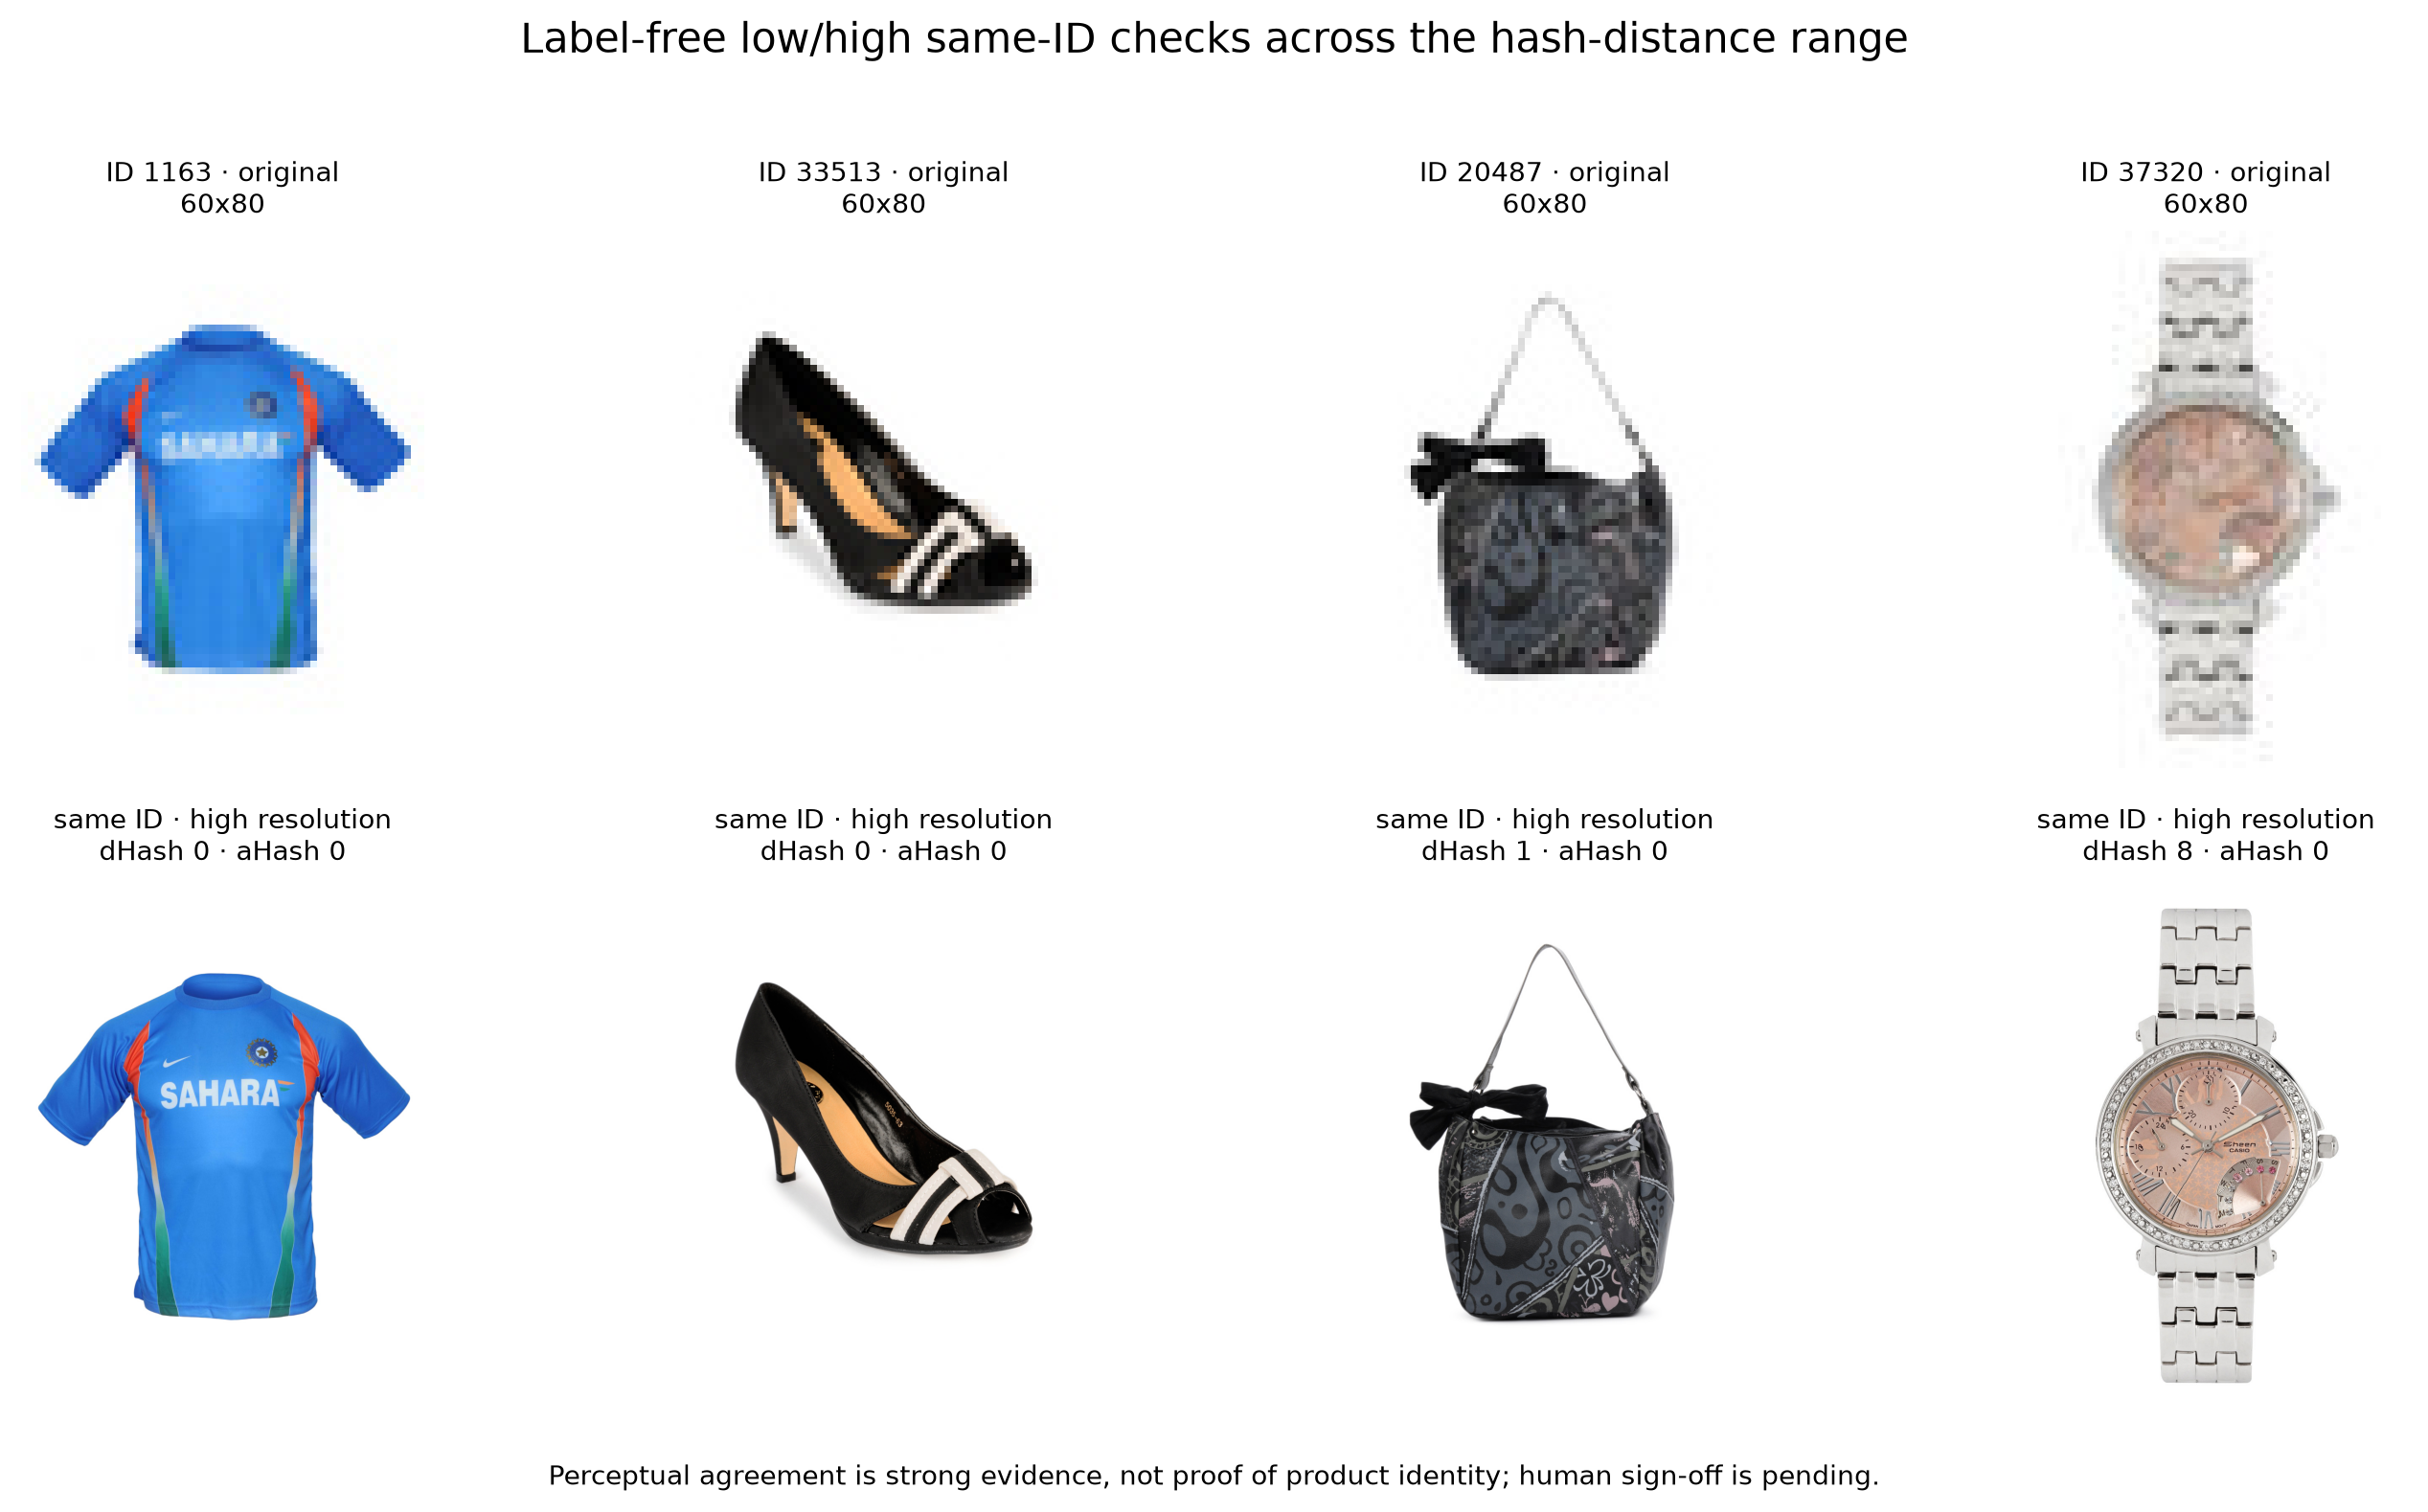

In [24]:
profile_figure = plot_image_profile(train_images)
quality_figure = plot_data_quality(train, train_images, issues)
alignment_figure = plot_variant_alignment(variant_manifest, alignment_pairs)
image_display = (
    image_summary.drop(columns="ordered_inventory_sha256")
    .rename(
        columns={
            "source_partition": "partition",
            "decoded_images": "decoded",
            "non_rgb_sources": "non_rgb",
            "median_file_kib": "median_kib",
            "p95_file_kib": "p95_kib",
        }
    )
    .round({"median_kib": 2, "p95_kib": 2})
)
image_contract_display = pd.DataFrame(
    [
        {
            "evidence": "original training images",
            "scope": f"{int(image_summary.iloc[0]['decoded_images']):,} decoded",
            "result": (
                f"{int(image_summary.iloc[0]['native_60x80']):,} are 60x80; "
                f"{int(image_summary.iloc[0]['non_rgb_sources']):,} need RGB conversion"
            ),
            "modelling_use": "decode safely, convert to RGB, preserve aspect ratio",
        },
        {
            "evidence": "low/high image pairs",
            "scope": f"{int(variant_proof['model_product_count']):,} products",
            "result": (
                f"{int(variant_proof['model_variant_count']):,} variant rows; zero incomplete pairs"
            ),
            "modelling_use": "weight each pair as one product; compare three variant policies",
        },
        {
            "evidence": "same-ID alignment screen",
            "scope": f"{int(alignment_proof['pair_count']):,} pairs",
            "result": (
                f"{int(alignment_proof['possible_content_mismatch_count']):,} possible "
                "mismatches; sign-off pending"
            ),
            "modelling_use": "keep exceptions visible; do not claim human proof",
        },
    ]
)
show_table(image_contract_display, "Image evidence and the modelling rule it supports")
show_figure(
    profile_figure,
    (
        "Figure 10. Training-only native resolution, colour-mode, aspect-ratio, and "
        "source-file-size distributions."
    ),
)
show_figure(
    quality_figure,
    (
        "Figure 11. Representative training images and objective image exceptions motivate "
        "exclusion, RGB conversion, and letterbox masking."
    ),
)
show_figure(
    alignment_figure,
    (
        "Figure 12. Same-ID original/high pairs span the observed hash-distance range. "
        "This supports the shared-product assumption, but possible mismatches and human "
        "review remain open."
    ),
)

> **Finding.** Of 26,992 training images, 26,982 use the common 60x80 size, ten use another size,
> and 246 are not stored as RGB. These are format differences rather than labels, so safe decoding
> and RGB conversion are appropriate. Every train, validation, and holdout product has a complete
> low/high pair: 38,551 products become 77,102 variant rows. The all-pair alignment screen covers
> 44,441 IDs and flags 84 possible mismatches, about 0.19%, for later review. Figures 10–12 show the
> source profile, objective exceptions, and representative low/high pairs.
>
> **Modelling consequence.** Preprocessing preserves aspect ratio, converts images to RGB, and keeps
> both resolutions tied to one product group with a total pair weight of one. Original-only,
> high-only, and paired training remain controlled alternatives; extra pixels are not treated as
> automatic evidence of better signal.

### 6.2 Input transformation

The transform comparison measures geometry, padding, tensor size, and local decoding cost. Model
quality remains an open experimental result rather than an EDA claim.

**Code step — Transform comparison functions.**

Defines the padding and tensor-cost calculation and the visual grid used to compare the 128x128 and 96x128 transforms.

In [25]:
# Transform cost and visual comparison evidence


def transform_cost(image_size: tuple[int, int], native_size: tuple[int, int]) -> dict[str, Any]:
    output_height, output_width = resolve_image_size(image_size)
    native_width, native_height = native_size
    scale = min(output_width / native_width, output_height / native_height)
    content_width = max(1, round(native_width * scale))
    content_height = max(1, round(native_height * scale))
    output_pixels = output_height * output_width
    content_pixels = content_height * content_width
    return {
        "output_height": output_height,
        "output_width": output_width,
        "content_height": content_height,
        "content_width": content_width,
        "output_pixels": output_pixels,
        "padding_pixels": output_pixels - content_pixels,
        "padding_percent": (output_pixels - content_pixels) / output_pixels * 100,
        "float32_rgb_kib": output_pixels * 3 * 4 / 1024,
    }


def plot_transform_grid(train_frame: pd.DataFrame, train_images: pd.DataFrame) -> Path:
    lookup = train_frame.set_index("id")
    ids = [int(train_frame.sort_values("id").iloc[0]["id"])]
    for mask in (
        train_images["mode"].ne("RGB"),
        ~(train_images["width"].eq(60) & train_images["height"].eq(80)),
    ):
        candidates = train_images[mask].sort_values("id")
        ids.append(int(candidates.iloc[0]["id"]) if not candidates.empty else ids[0])
    fig, axes = plt.subplots(3, 3, figsize=(9.5, 11))
    for row_index, item_id in enumerate(ids):
        row = lookup.loc[item_id]
        source = open_rgb(str(row["path"]))
        old = transform_image(source, image_size=LEGACY_IMAGE_SIZE)
        chosen = transform_image(source, image_size=IMAGE_SIZE)
        old_cost = transform_cost(LEGACY_IMAGE_SIZE, source.size)
        chosen_cost = transform_cost(IMAGE_SIZE, source.size)
        show_image(
            axes[row_index, 0], source, f"Source · ID {item_id}\n{source.width}x{source.height}"
        )
        show_image(
            axes[row_index, 1],
            old,
            f"Old 128x128\npadding {old_cost['padding_percent']:.1f}%",
        )
        show_image(
            axes[row_index, 2],
            chosen,
            f"Chosen 96x128\npadding {chosen_cost['padding_percent']:.1f}%",
        )
    fig.suptitle("96x128 matches the common 60x80 source with fewer tensor pixels")
    fig.text(
        0.5,
        0.015,
        "Padding is excluded from train-only mean/std and becomes neutral after standardization.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.97))
    return save_figure(fig, "transform_comparison.png")

**Code step — Transform benchmark results.**

Runs the fixed training-image sample through both transforms, saves volatile timing evidence, and displays the cost table with Figure 13.

,option,shape,padding_pct,pixels,rgb_kib,images_per_sec
0,old_128x128,128x128,25.000,"16,384",192.000,"5,156.400"
1,chosen_96x128,96x128,0.000,"12,288",144.000,"5,211.700"



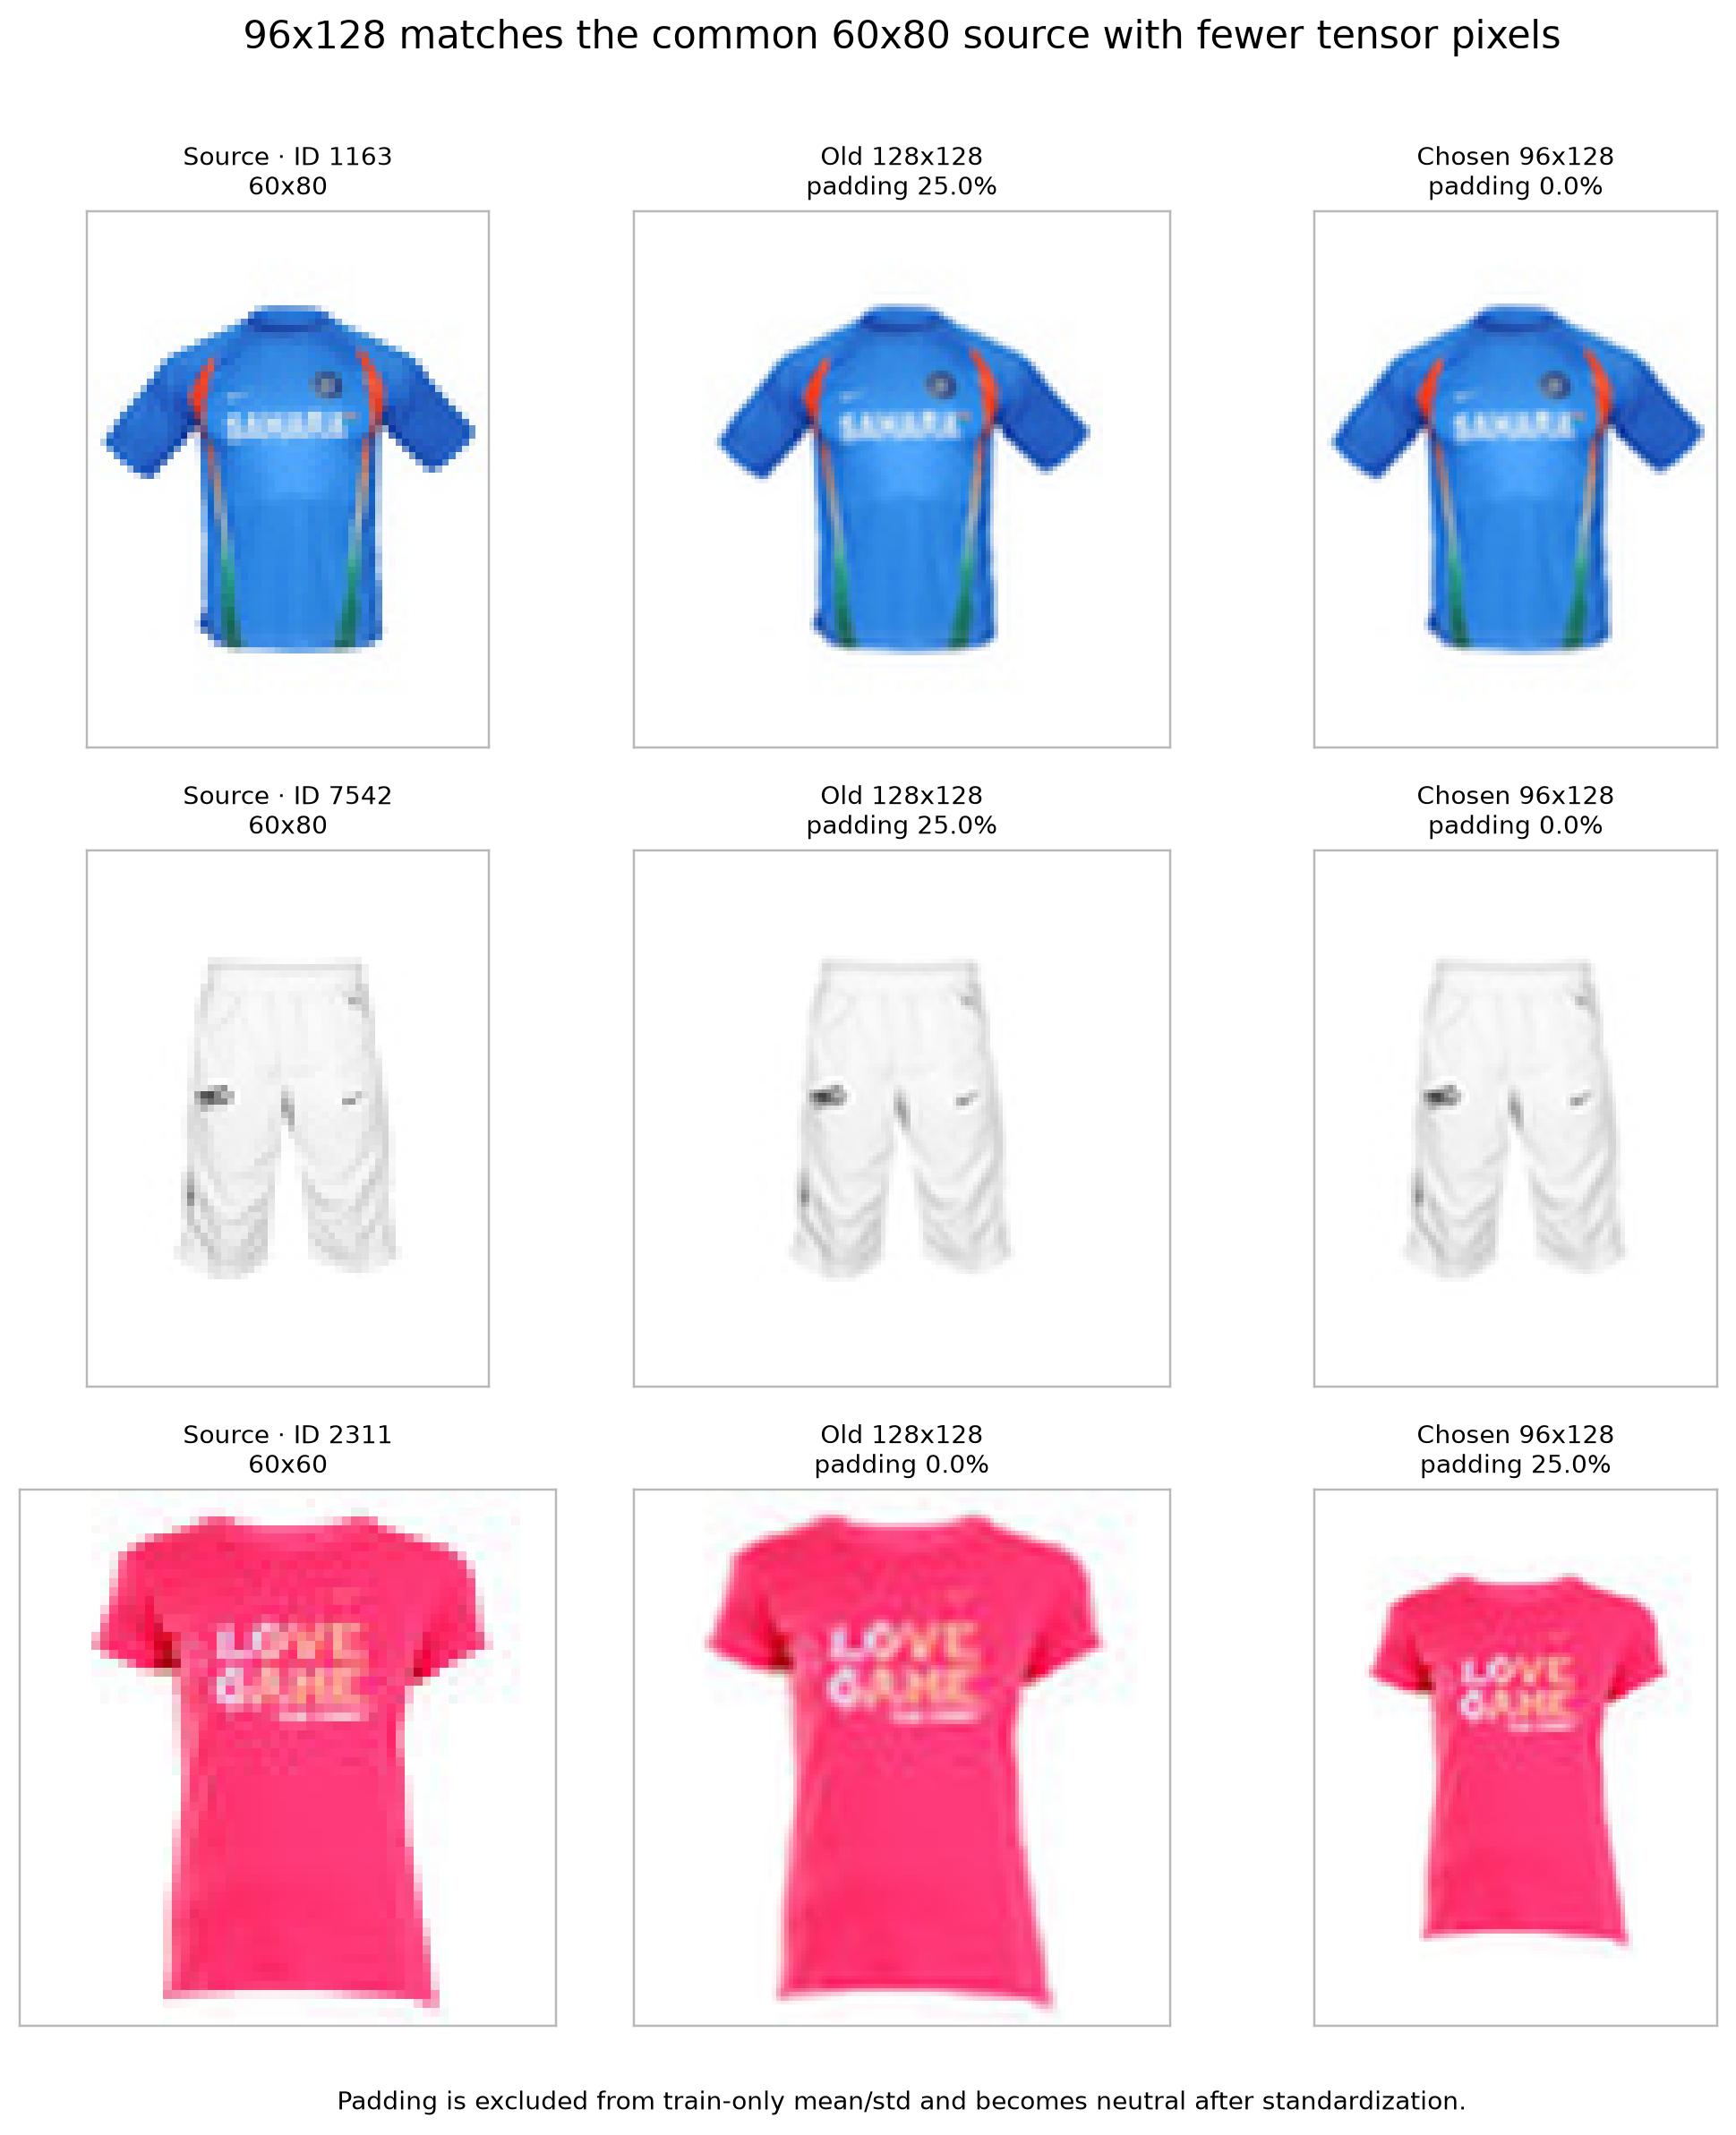

In [26]:
options = {"old_128x128": LEGACY_IMAGE_SIZE, "chosen_96x128": IMAGE_SIZE}
sample_size = min(BENCHMARK_SAMPLE_SIZE, len(train))
sample = train.sample(sample_size, random_state=SEED).sort_values("id")
benchmark_images = [open_rgb(path) for path in sample["path"]]
timings: dict[str, dict[str, Any]] = {}
for name, size in options.items():
    for source in benchmark_images[: min(8, len(benchmark_images))]:
        transform_image(source, image_size=size)
    seconds = []
    for _ in range(BENCHMARK_REPETITIONS):
        started = time.perf_counter()
        for source in benchmark_images:
            transform_image(source, image_size=size)
        seconds.append(time.perf_counter() - started)
    middle = median(seconds)
    timings[name] = {
        "seconds": [round(value, 6) for value in seconds],
        "median_seconds": round(middle, 6),
        "median_images_per_second": round(sample_size / middle, 2),
    }
transform_rows = []
for name, size in options.items():
    cost = transform_cost(size, (60, 80))
    transform_rows.append(
        {
            "alternative": name,
            "output_width_height": f"{cost['output_width']}x{cost['output_height']}",
            "padding_percent_for_60x80": cost["padding_percent"],
            "output_pixels": cost["output_pixels"],
            "float32_rgb_kib": cost["float32_rgb_kib"],
            "median_images_per_second": timings[name]["median_images_per_second"],
            "validation_macro_f1": "not available; no registered training run",
        }
    )
transform_summary = pd.DataFrame(transform_rows)
benchmark_record = {
    "scope": "deterministic train-only image sample; labels unused",
    "seed": SEED,
    "sample_size": sample_size,
    "sample_ids": sample["id"].astype(int).tolist(),
    "repetitions": BENCHMARK_REPETITIONS,
    "runtime": {
        "python": platform.python_version(),
    },
    "timings": timings,
    "limitation": "wall time depends on hardware and cache state",
    "decision": "use 96x128 for exact padding, pixel-count, and memory reasons",
}
save_csv(transform_summary, "transform_summary.csv")
save_json(benchmark_record, "transform_benchmark.json")
transform_figure = plot_transform_grid(train, train_images)
transform_display = (
    transform_summary.rename(
        columns={
            "alternative": "option",
            "output_width_height": "shape",
            "padding_percent_for_60x80": "padding_pct",
            "output_pixels": "pixels",
            "float32_rgb_kib": "rgb_kib",
            "median_images_per_second": "images_per_sec",
            "validation_macro_f1": "model_score",
        }
    )
    .drop(columns="model_score")
    .round({"padding_pct": 1, "rgb_kib": 1, "images_per_sec": 1})
)
show_table(transform_display, "Transform cost and local wall-time benchmark")
show_figure(
    transform_figure,
    (
        "Figure 13. Train-only source images compare the old 128 by 128 square transform with "
        "the chosen 96 by 128 aspect-preserving transform."
    ),
)

> **Finding.** A 96x128 tensor matches the common 60x80 aspect ratio and adds no padding. The
> 128x128 square adds 25% padding and uses 16,384 pixels instead of 12,288, increasing float32 RGB
> memory from 144 KiB to 192 KiB per image. Local decoding speeds are close and hardware dependent.
> Figure 13 shows that the selected transform preserves product shape with less empty space.
>
> **Modelling consequence.** RGB 96x128 is the default candidate because its geometry and memory
> cost are better justified. RGB 128x128 remains a controlled baseline, and validation macro-F1
> determines whether the cheaper transform also preserves predictive signal.

## 7. Retrieval evaluation

Task 4 requires a product-level protocol that separates model development from the search gallery.
The protocol also accounts for incomplete relevance coverage instead of presenting Recall@5 without
its attainable ceiling.

**Code step — Retrieval protocol figure.**

Defines the example figure for Task 4 relevance grades using one validation query and train-gallery examples.

In [27]:
# Task 4 evaluation illustration


def plot_task4(queries: pd.DataFrame, gallery: pd.DataFrame) -> Path:
    query = queries.sort_values("id").iloc[0]
    same_type = gallery[gallery["articleType_deployed"].eq(query["articleType_deployed"])]
    groups = [
        (
            "Proxy grade 2: type + colour",
            same_type[same_type["baseColour"].eq(query["baseColour"])],
        ),
        (
            "Proxy grade 1: type only",
            same_type[same_type["baseColour"].ne(query["baseColour"])],
        ),
        (
            "Proxy grade 0: colour only",
            gallery[
                gallery["baseColour"].eq(query["baseColour"])
                & gallery["articleType_deployed"].ne(query["articleType_deployed"])
            ],
        ),
        (
            "Proxy grade 0: unrelated",
            gallery[
                gallery["baseColour"].ne(query["baseColour"])
                & gallery["articleType_deployed"].ne(query["articleType_deployed"])
            ],
        ),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(14, 3.9))
    show_image(
        axes[0],
        open_rgb(query["path"]),
        f"Validation query\n{query['articleType_deployed']} · {query['baseColour']}",
    )
    for axis, (label, group) in zip(axes[1:], groups):
        if group.empty:
            axis.axis("off")
            axis.text(0.5, 0.5, f"{label}\nnot present in this fixture", ha="center", va="center")
        else:
            row = group.sort_values("id").iloc[0]
            show_image(
                axis,
                open_rgb(row["path"]),
                f"{label}\n{row['articleType_deployed']} · {row['baseColour']}",
            )
    fig.suptitle("Task 4 metadata-proxy grades; these are not model rankings")
    fig.text(
        0.5,
        0.01,
        "Labels score results after retrieval; both image variants collapse to one product ID.",
        ha="center",
        fontsize=9,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.94))
    return save_figure(fig, "task4_protocol.png")

**Code step — Retrieval isolation and coverage.**

Builds validation queries and the train-only gallery, proves zero ID, hash, and family overlap, and measures attainable grade-2 coverage.

In [28]:
queries, gallery = build_development_retrieval_sets(splits)
query_variants, gallery_variants = build_development_retrieval_variant_sets(
    splits, variant_manifest
)
id_overlap = set(queries["id"].astype(int)) & set(gallery["id"].astype(int))
sha_overlap = set(queries["sha256"].astype(str)) & set(gallery["sha256"].astype(str))
family_overlap = set(queries["product_family_group"].astype(str)) & set(
    gallery["product_family_group"].astype(str)
)
if id_overlap or sha_overlap or family_overlap:
    raise ValueError("Task 4 query/gallery isolation failed")

total_validation_products = int(splits["partition"].eq("val").sum())
excluded_unsupported_queries = total_validation_products - len(queries)
if total_validation_products != len(queries) + excluded_unsupported_queries:
    raise ValueError("Task 4 query eligibility accounting failed")

task4_k = 5
grade2_lookup = gallery.groupby(["articleType_deployed", "baseColour"])["id"].nunique().to_dict()
grade2_positive_counts = np.array(
    [
        int(grade2_lookup.get((row.articleType_deployed, row.baseColour), 0))
        for row in queries.itertuples(index=False)
    ]
)
zero_grade2 = int((grade2_positive_counts == 0).sum())
fewer_than_k_grade2 = int((grade2_positive_counts < task4_k).sum())

task4_record = {
    "query_partition": "val",
    "query_scope": "train-fitted supported articleType classes only",
    "total_validation_products": total_validation_products,
    "eligible_supported_query_products": len(queries),
    "excluded_unsupported_query_products": excluded_unsupported_queries,
    "query_exclusion_reason": "articleType is outside the train-fitted supported slice",
    "final_evaluation_unsupported_query_policy": (
        "report separately as a coverage/failure slice; never silently omit"
    ),
    "gallery_partition": "train",
    "query_products": len(queries),
    "gallery_products": len(gallery),
    "query_image_variants": len(query_variants),
    "gallery_image_variants": len(gallery_variants),
    "shared_ids": len(id_overlap),
    "shared_sha256": len(sha_overlap),
    "shared_product_families": len(family_overlap),
    "graded_relevance": {
        "2": "same official articleType and baseColour",
        "1": "same official articleType but different baseColour",
        "0": "different official articleType",
    },
    "recall_at_k": {
        "k": task4_k,
        "relevant_grades": [2],
        "numerator": "distinct grade-2 product IDs among the first K product IDs",
        "denominator": "all distinct grade-2 product IDs in the allowed train gallery",
        "caller_requirement": (
            "pass an explicit total relevant count or complete gallery relevance vector"
        ),
        "zero_positive_query_rule": "exclude from macro Recall@K and report in coverage",
        "queries_with_zero_grade2_positives": zero_grade2,
        "queries_with_fewer_than_k_grade2_positives": fewer_than_k_grade2,
        "queries_eligible_for_macro_recall": len(queries) - zero_grade2,
    },
    "metrics": ["nDCG@5 over grades 2/1/0", "grade-2 Recall@5", "latency", "coverage"],
    "variant_policy": (
        "encode both image variants; rank by the best variant score; collapse to one product ID "
        "before Top-K and product-level scoring"
    ),
    "self_match_policy": "remove every query product ID before product-level Top-K",
    "final_gallery_policy": "a larger gallery is locked until independent evaluation ends",
    "limitation": "metadata grades are a proxy, not human visual-similarity ground truth",
}
task4_summary = pd.DataFrame(
    [
        {"contract": "total validation products", "value": total_validation_products},
        {"contract": "eligible supported query products", "value": len(queries)},
        {"contract": "excluded unsupported query products", "value": excluded_unsupported_queries},
        {"contract": "exclusion reason", "value": "articleType lacks train-family support"},
        {"contract": "final unsupported-query policy", "value": "separate coverage/failure slice"},
        {"contract": "query image variants", "value": len(query_variants)},
        {"contract": "gallery products", "value": len(gallery)},
        {"contract": "gallery image variants", "value": len(gallery_variants)},
        {"contract": "shared IDs / SHA / families", "value": "0 / 0 / 0"},
        {"contract": "Recall@5 relevant grade", "value": "grade 2 only"},
        {"contract": "zero grade-2 positives", "value": zero_grade2},
        {"contract": "fewer than five grade-2 positives", "value": fewer_than_k_grade2},
        {"contract": "zero-positive rule", "value": "exclude from mean; report coverage"},
        {"contract": "Top-K identity", "value": "one slot and score per product ID"},
    ]
)

**Code step — Retrieval evidence results.**

Saves the Task 4 contract and displays its reader-facing coverage table with Figure 14.

,contract,value
0,total validation products,"5,781"
1,eligible supported query products,"5,768"
2,excluded unsupported query products,13
6,gallery products,"26,992"
8,shared IDs / SHA / families,0 / 0 / 0
10,zero grade-2 positives,110
11,fewer than five grade-2 positives,412
12,zero-positive rule,exclude from mean; report coverage
13,Top-K identity,one slot and score per product ID



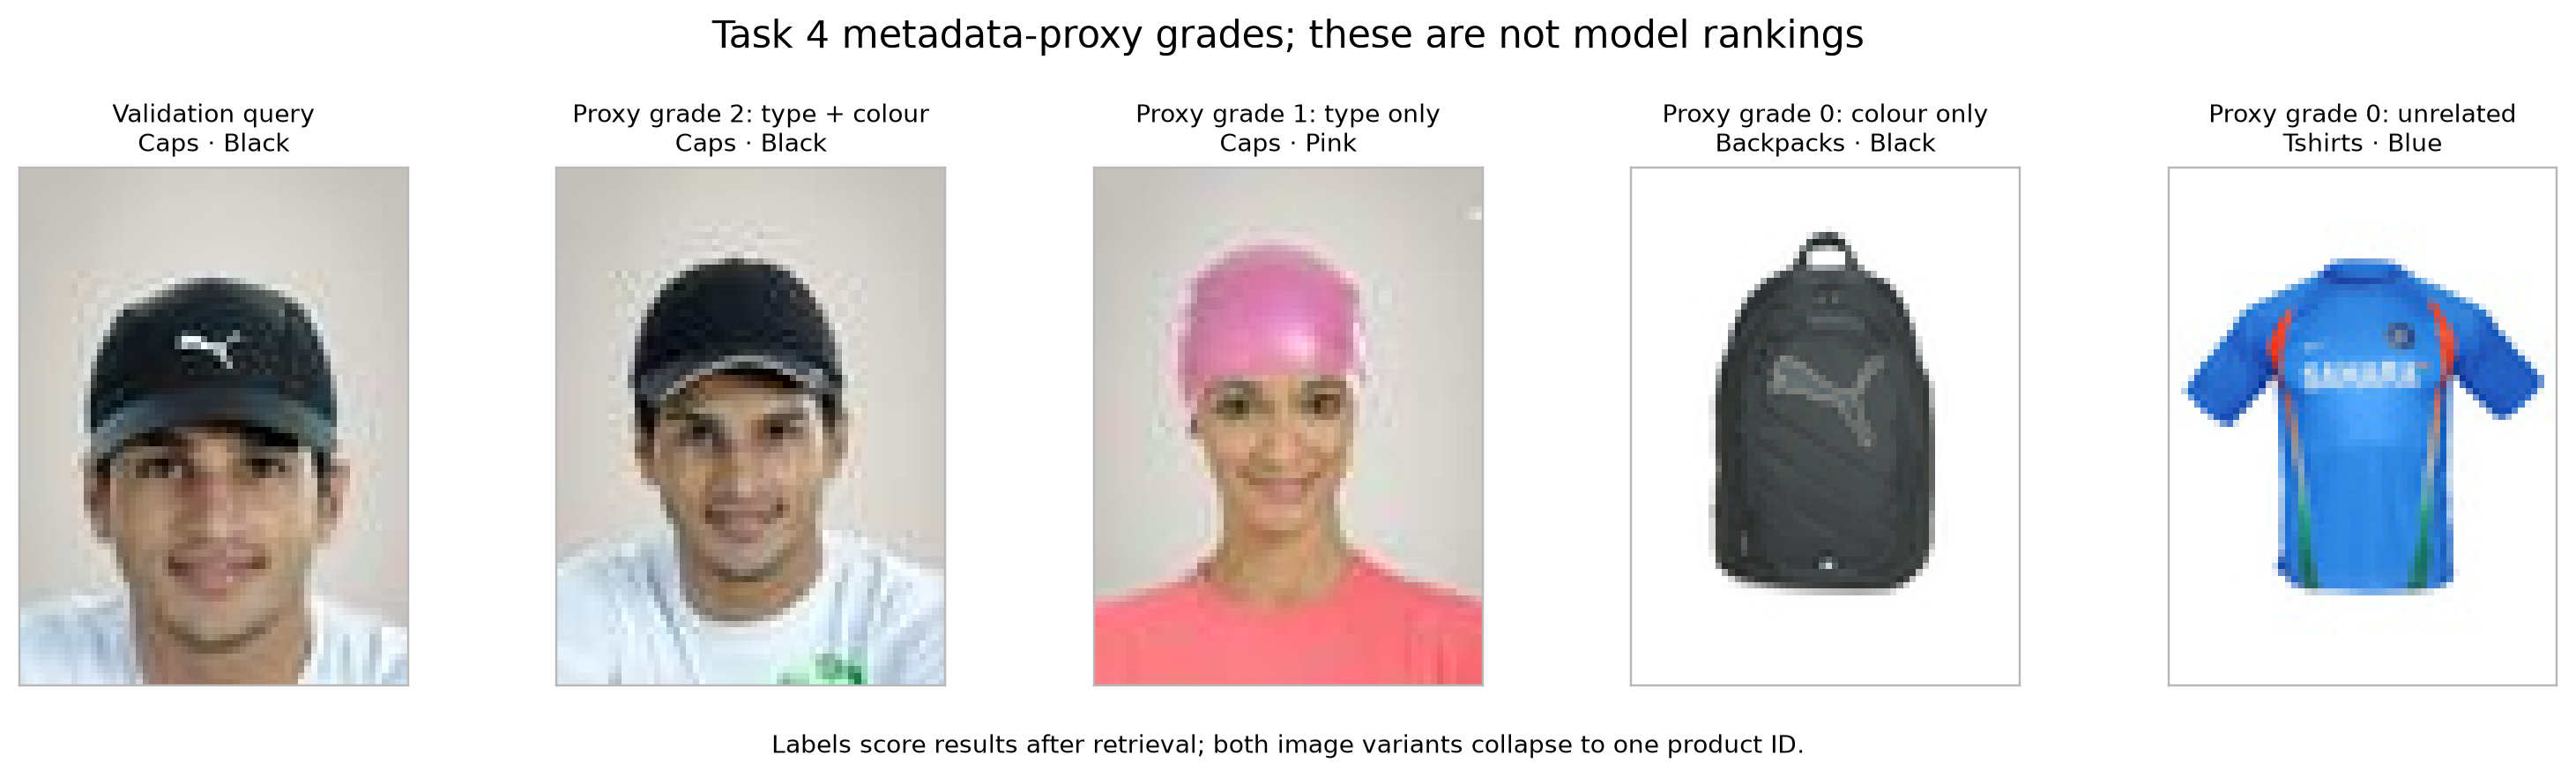

In [29]:
save_json(task4_record, "task4_protocol.json")
save_csv(task4_summary, "task4_summary.csv")
task4_figure = plot_task4(queries, gallery)
task4_reader_rows = {
    "total validation products",
    "eligible supported query products",
    "excluded unsupported query products",
    "gallery products",
    "shared IDs / SHA / families",
    "zero grade-2 positives",
    "fewer than five grade-2 positives",
    "zero-positive rule",
    "Top-K identity",
}
show_table(
    task4_summary[task4_summary["contract"].isin(task4_reader_rows)],
    "Task 4 evaluation contract and coverage limits",
)
show_figure(
    task4_figure,
    (
        "Figure 14. One validation query is compared with train-only metadata-proxy "
        "grade examples. These are not model rankings. Both image variants collapse to "
        "one product ID."
    ),
)

> **Finding.** The development protocol uses 5,768 supported validation products as queries and
> 26,992 training products as the gallery, with zero shared IDs, hashes, or families. Thirteen
> validation products fall outside the train-supported article-type slice and are reported
> separately. Coverage limits Recall@5: 110 queries have no grade-2 gallery positive and 412 have
> fewer than five. Figure 14 illustrates the relevance rule; it is metadata-proxy evidence rather
> than a model ranking or human similarity judgement.
>
> **Modelling consequence.** Both image variants collapse to one product ID before Top-K ranking.
> Evaluation reports nDCG@5 over grades 2/1/0, grade-2 Recall@5, zero-positive coverage, unsupported
> query coverage, and latency. A simple baseline and a learned embedding use this exact protocol.

## 8. Reproducibility and limitations

The final evidence check distinguishes stable artefacts from machine-dependent measurements and
records the unresolved limits that later experiments must preserve or close.

**Code step — Modelling decision table.**

Converts the EDA findings into fixed modelling choices and later checks, then saves the decision table.

In [30]:
decision_table = pd.DataFrame(
    [
        {
            "area": "split",
            "decision": "use data/processed/splits.csv only",
            "evidence": "zero active SHA/name/family/visual crossings",
            "later_check": "never make another split",
        },
        {
            "area": "protected labels",
            "decision": "seal holdout and quarantine",
            "evidence": "shared loader returns blank protected targets",
            "later_check": "unlock only once for final evaluation",
        },
        {
            "area": "official outputs",
            "decision": "train the frozen train-observed output vocabulary",
            "evidence": "train-fitted taxonomy and label maps; no holdout influence",
            "later_check": "keep fixed prediction schema and literal NA",
        },
        {
            "area": "primary comparison",
            "decision": "rank on supported classes",
            "evidence": "at least three independent train families",
            "later_check": "also report rare official outputs",
        },
        {
            "area": "image input",
            "decision": "RGB, 96x128, aspect preserving",
            "evidence": "zero common padding and 25% fewer tensor pixels",
            "later_check": "use paired train-only mean/std by default",
        },
        {
            "area": "image variants",
            "decision": "use low and high resolution for every model product",
            "evidence": "complete pairs plus label-free alignment audit",
            "later_check": "one ID/score; compare original-only, high-only, doubled",
        },
        {
            "area": "Task 1",
            "decision": "macro-F1 plus per-class and support slices",
            "evidence": "strong articleType long tail",
            "later_check": "show rare-class failures",
        },
        {
            "area": "Tasks 2 and 3",
            "decision": "separate targets with bias slices",
            "evidence": "mixed season signal and catalogue shortcuts",
            "later_check": "do not treat gender as identity",
        },
        {
            "area": "Task 4",
            "decision": "validation queries, train-only gallery",
            "evidence": "zero ID/SHA/family overlap",
            "later_check": "nDCG, grade-2 Recall, coverage, latency",
        },
        {
            "area": "human review",
            "decision": "keep every row pending",
            "evidence": "no reviewer provenance or sign-off",
            "later_check": "never claim reviewed precision yet",
        },
    ]
)
save_csv(decision_table, "decision_table.csv")

PosixPath('/home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/evidence/eda/decision_table.csv')

**Code step — Evidence and input provenance.**

Lists every stable output and permitted input fingerprint and records the current Git state for reproducibility.

In [31]:
stable_evidence_names = [
    "bias_summary.csv",
    "decision_table.csv",
    "duplicate_summary.csv",
    "family_policy_summary.csv",
    "hierarchy_summary.csv",
    "high_resolution_summary.csv",
    "image_summary.csv",
    "joint_target_nmi.csv",
    "normalization_summary.csv",
    "partition_summary.csv",
    "processed_inventory.csv",
    "raw_inventory.csv",
    "review_summary.csv",
    "season_family_basis_summary.csv",
    "target_summary.csv",
    "task4_protocol.json",
    "task4_summary.csv",
    "taxonomy_exclusions.csv",
    "taxonomy_summary.csv",
    "validation_summary.csv",
    "variant_alignment_summary.csv",
]
figure_names = [
    "article_type_long_tail.png",
    "bias_risk.png",
    "data_quality_examples.png",
    "development_balance.png",
    "hierarchy_overlap.png",
    "image_profile.png",
    "joint_target_relationships.png",
    "near_duplicate_review.png",
    "product_name_review.png",
    "season_ambiguity.png",
    "target_distributions.png",
    "task4_protocol.png",
    "transform_comparison.png",
    "variant_alignment_examples.png",
]
deterministic_outputs = sorted(
    [
        *(FIGURES / name for name in figure_names),
        review_contact_sheet,
        *(EVIDENCE / name for name in stable_evidence_names),
    ],
    key=lambda path: path.relative_to(PROJECT_ROOT).as_posix(),
)

input_records = [
    {
        "path": "data/raw/teacher/train/styles_train.csv",
        "read_scope": "header and ID only",
        "rows": len(raw_train_ids),
        "sha256": dataframe_digest(raw_train_ids.sort_values("id"), ["id"]),
    },
    {
        "path": "data/raw/teacher/test/styles_prediction.csv",
        "read_scope": "fixed header and ID only",
        "rows": len(raw_prediction_ids),
        "sha256": dataframe_digest(raw_prediction_ids, ["id"]),
    },
    *[
        {
            "path": row.file,
            "read_scope": row.digest_scope,
            "rows": row.rows,
            "sha256": row.sha256,
        }
        for row in processed_inventory.itertuples(index=False)
    ],
    *[file_record(path) for path in review_files.values() if path.is_file()],
]

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=PROJECT_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
    git_dirty = bool(
        subprocess.run(
            ["git", "status", "--porcelain"],
            cwd=PROJECT_ROOT,
            check=True,
            capture_output=True,
            text=True,
        ).stdout.strip()
    )
except (FileNotFoundError, subprocess.CalledProcessError):
    git_commit = "unavailable"
    git_dirty = None

**Code step — Portable EDA summary.**

Assembles the machine-readable EDA summary containing scope, leakage checks, image policy, evaluation rules, decisions, and open limits.

In [32]:
summary = {
    "schema_version": "10.0.0",
    "execution": {
        "preparation_mode": PREPARATION_MODE,
        "preparation_seconds": round(preparation_seconds, 3),
        "cache_validation": cache_validation,
        "default_mode": "cached",
        "full_mode_environment": "FASHION_EDA_MODE=full",
    },
    "scope": {
        "modelling_partition": "train",
        "development_partition": "val",
        "protected_partitions": ["holdout", "quarantine"],
        "prediction_images_in_target_eda": 0,
        "prediction_role": "label-free duplicate audit only",
        "raw_teacher_target_columns_read_by_eda": 0,
    },
    "inventory": {
        "raw_train_rows": len(raw_train_ids),
        "official_prediction_rows": len(raw_prediction_ids),
        "image_backed_labelled_rows": len(splits),
        "train_rows": len(train),
        "validation_rows": len(validation),
        "train_image_inventory_digest": image_summary.iloc[0]["ordered_inventory_sha256"],
    },
    "image_variants": variant_record,
    "normalization": {
        "default_policy": paired_normalization["policy"],
        "paired_sha256": compute_sha256(PAIRED_NORMALIZATION_PATH),
        "original_only_baseline_sha256": compute_sha256(ORIGINAL_ONLY_NORMALIZATION_PATH),
        "train_ids_digest": paired_normalization["train_ids_digest"],
    },
    "leakage_checks": {
        **crossing_checks,
        "accepted_visual_edges_crossing_active_partitions": len(visual_crossings),
        "protected_target_fields_visible": 0,
        "raw_teacher_target_columns_read_by_eda": 0,
        "prediction_ids_in_labelled_splits": 0,
        "prediction_ids_in_variant_manifest": variant_proof["official_prediction_id_intersection"],
        "quarantine_ids_in_variant_manifest": variant_proof["quarantine_id_intersection"],
    },
    "reviews": review_summary.to_dict("records"),
    "taxonomy": taxonomy_summary.to_dict("records"),
    "validation": validation_summary.to_dict("records"),
    "transform_decision": {
        "shape_height_width": list(IMAGE_SIZE),
        "common_source_padding_percent": 0.0,
        "pixel_reduction_vs_old_percent": 25.0,
        "wall_time_is_volatile": True,
        "downstream_macro_f1": "not available",
    },
    "task4": task4_record,
    "decisions": decision_table.to_dict("records"),
    "limitations": [
        "The visual duplicate rule favours precision and does not prove recall.",
        "Normalized names can group different designs and reduce effective sample size.",
        "Tiny original images can hide fine product details.",
        "Season, gender, and usage are catalogue labels, not always visible facts.",
        "Task 4 grades are a metadata proxy, not human visual-similarity ground truth.",
        "Perceptual same-ID alignment is strong automatic evidence, not human proof.",
        (
            "Doubled inputs add storage and decoding cost; the planned three-way "
            "ablation is not run yet."
        ),
        "Queries with no grade-2 positives are excluded from mean Recall@5 and reported.",
        "No registered model run yet compares transform macro-F1.",
        (
            "Cached mode checks every image path and size but content-hashes only a fixed "
            "sample; use full mode after any deliberate raw-image replacement."
        ),
        "Full forensic mode is I/O-bound and is not the normal reader path.",
    ],
    "deterministic_outputs": [file_record(path) for path in deterministic_outputs],
}
save_json(summary, "summary.json")

PosixPath('/home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/evidence/eda/summary.json')

**Code step — Provenance record.**

Writes runtime and file-level provenance, separates stable outputs from volatile timings, and displays the saved provenance boundary.

In [33]:
provenance = {
    "git": {"commit": git_commit, "dirty": git_dirty},
    "notebook": {
        "path": NOTEBOOK_PATH.relative_to(PROJECT_ROOT).as_posix(),
        "code_digest": notebook_code_digest(NOTEBOOK_PATH),
    },
    "runtime": {
        "python": platform.python_version(),
        "implementation": platform.python_implementation(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__,
        "pillow": Image.__version__,
    },
    "inputs": input_records,
    "execution": summary["execution"],
    "image_variants": variant_record,
    "deterministic_outputs": [file_record(path) for path in deterministic_outputs],
    "volatile_outputs": [
        file_record(EVIDENCE / "transform_benchmark.json"),
        file_record(EVIDENCE / "transform_summary.csv"),
    ],
    "note": (
        "Wall-time benchmark hashes may change; report figures and other evidence are "
        "deterministic for the locked runtime."
    ),
}
save_json(provenance, "provenance.json")
provenance_summary = pd.DataFrame(
    [
        {
            "stable_output_files": len(deterministic_outputs),
            "report_figures": len(figure_names),
            "notebook_code_digest": provenance["notebook"]["code_digest"][:16] + "...",
            "wall_time_hash_stable": False,
        }
    ]
)
show_table(provenance_summary, "Saved portable provenance boundary")

,stable_output_files,report_figures,notebook_code_digest,wall_time_hash_stable
0,36,14,7a3df866afda7e96...,False


> **Finding.** The notebook records 36 stable evidence files, including all 14 report figures,
> with project-relative paths and hashes. Raw target files are represented only by permitted ID-level
> fingerprints. Wall-time benchmarks remain outside the stable set because hardware and cache state
> change them.
>
> **Modelling consequence.** Later notebooks reuse the same split, taxonomy, normalization,
> image-variant manifest, and run registry. A deliberate raw-data replacement requires full mode
> before new results are compared with the saved evidence.

## 9. Modelling recommendations

The decision table converts EDA evidence into an experiment contract. Each row states the chosen
policy, its supporting evidence, and the result that later model work must still establish.

**Code step — Final report output.**

Displays the modelling decision table, open limitations, and the successful Run All completion record.

In [34]:
show_table(decision_table, "EDA decision table for all later modelling")
display(
    HTML(
        "<p><strong>Open limits:</strong> " + html.escape(" ".join(summary["limitations"])) + "</p>"
    )
)
display(
    HTML(
        f"<p><strong>Run All complete in {PREPARATION_MODE} mode.</strong> "
        f"Prepared data in {preparation_seconds:.1f} seconds "
        f"and saved {len(figure_names)} figures. "
        "Protected target values materialised by EDA: 0. "
        "Both image variants covered every train, validation, and holdout product.</p>"
    )
)

,area,decision,evidence,later_check
0,split,use data/processed/splits.csv only,zero active SHA/name/family/visual crossings,never make another split
1,protected labels,seal holdout and quarantine,shared loader returns blank protected targets,unlock only once for final evaluation
2,official outputs,train the frozen train-observed output vocabulary,train-fitted taxonomy and label maps; no holdout influence,keep fixed prediction schema and literal NA
3,primary comparison,rank on supported classes,at least three independent train families,also report rare official outputs
4,image input,"RGB, 96x128, aspect preserving",zero common padding and 25% fewer tensor pixels,use paired train-only mean/std by default
5,image variants,use low and high resolution for every model product,complete pairs plus label-free alignment audit,"one ID/score; compare original-only, high-only, doubled"
6,Task 1,macro-F1 plus per-class and support slices,strong articleType long tail,show rare-class failures
7,Tasks 2 and 3,separate targets with bias slices,mixed season signal and catalogue shortcuts,do not treat gender as identity
8,Task 4,"validation queries, train-only gallery",zero ID/SHA/family overlap,"nDCG, grade-2 Recall, coverage, latency"
9,human review,keep every row pending,no reviewer provenance or sign-off,never claim reviewed precision yet


## 10. Final assessment

The dataset is ready for controlled model development, but it is not ready for a final performance
claim. The split is safe, difficult classes and shortcut risks are documented, and the image and
retrieval contracts are fixed. The next work follows this order:

1. Train the same from-scratch baseline with original-only, high-only, and paired images under one
   seed, budget, split, and metric suite.
2. For `articleType` and `usage`, compare ordinary loss with at least one imbalance-aware method and
   explain rare-class gains and losses.
3. Compare separate prediction models with a shared-representation alternative while retaining one
   score and failure analysis for each official target.
4. For Task 4, compare a simple retrieval baseline with a learned embedding using the fixed
   validation-query and train-gallery protocol.
5. Freeze the final choices, then unlock the holdout exactly once for independent evaluation.

The final assignment report should cite EDA figures only when they justify a modelling choice. It
should not repeat every diagnostic plot.